# Trabalho Final PACD — Análise
**Título:** Eficiência de Recursos nas PME Europeias: Fatores Determinantes da Adoção e da sua Intensidade  
**Fonte de dados:** Flash Eurobarometer 549 (Junho 2024) — GESIS ZA8869  
**Amostra:** PME dos 27 países da UE + Reino Unido

---

> Este notebook contém toda a análise: AED, tratamento de dados, modelação e avaliação.  
> O contexto e fundamentação encontram-se no **NB01_understanding**.

## Setup

In [1]:
import pyreadstat
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, kruskal, spearmanr
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
%matplotlib inline

# ── Paleta de cores global ────────────────────────────────────────────────────
BLUE       = '#4C6EFF'   # azul principal
LIGHT_BLUE = '#A3C1FF'   # azul claro
ORANGE     = '#FF7043'   # laranja — alertas / destaque
GREEN      = '#2E7D5E'   # verde — Q8 / apoios
BG         = '#F9F9F9'   # fundo dos gráficos

## Carregamento e preparação dos dados

> Replica o pipeline do NB01: carregamento → recoding DK/NA → filtro EU+UK → filtro PME → seleção de variáveis.

In [2]:
# ── Carregamento ──────────────────────────────────────────────────────────────
df_raw, meta = pyreadstat.read_sav('../data/raw/initial_data.sav', apply_value_formats=False)

# ── Recoding DK/NA ───────────────────────────────────────────────────────────
DK_NA = {997.0, 998.0, 999.0, 999997.0, 999998.0, 999999.0}
df_raw = df_raw.copy()
for col in df_raw.select_dtypes(include='number').columns:
    df_raw[col] = df_raw[col].replace({k: np.nan for k in DK_NA})

# ── Filtro geográfico (EU27 + UK) ────────────────────────────────────────────
eu_uk = [
    'AT','BE','BG','HR','CY','CZ','DK','EE','FI','FR',
    'DE','GR','HU','IE','IT','LV','LT','LU','MT','NL',
    'PL','PT','RO','SK','SI','ES','SE',
    'GB'
]
df = df_raw[df_raw['isocntry'].isin(eu_uk)].copy()

# ── Filtro PME (<250 FTE) ────────────────────────────────────────────────────
df = df[df['scr10'].isin([1.0, 2.0, 3.0])].copy()

# ── Seleção de variáveis chave ───────────────────────────────────────────────
key_vars = [
    'isocntry', 'nace_b', 'scr10',
    'scr12', 'scr13a', 'scr14',
    'q3', 'q4',
    'q1.1','q1.2','q1.3','q1.4','q1.5',
    'q1.6','q1.7','q1.8','q1.9',
    'q7.1','q7.2','q7.3','q7.4','q7.5',
    'q7.6','q7.7','q7.8','q7.9','q7.10',
    'q7.11','q7.12',
    'w1_sme',
]
key_vars = [v for v in key_vars if v in df.columns]
df_key = df[key_vars].copy()

print(f"df:     {df.shape[0]:,} linhas × {df.shape[1]} colunas (dataset completo filtrado)")
print(f"df_key: {df_key.shape[0]:,} linhas × {df_key.shape[1]} colunas (variáveis seleccionadas)")

df:     13,559 linhas × 236 colunas (dataset completo filtrado)
df_key: 13,559 linhas × 30 colunas (variáveis seleccionadas)


In [3]:
# ── Dicionários de labels ─────────────────────────────────────────────────────

q1_map = {
    'q1.1': 'Poupar água',
    'q1.2': 'Poupar energia',
    'q1.3': 'Energia renovável',
    'q1.4': 'Poupar materiais',
    'q1.5': 'Fornecedores mais verdes',
    'q1.6': 'Minimizar resíduos',
    'q1.7': 'Vender resíduos',
    'q1.8': 'Reciclar internamente',
    'q1.9': 'Eco-design',
}

q7_map = {
    'q7.1':  'Falta de financiamento',
    'q7.2':  'Custo elevado inicial',
    'q7.3':  'Falta de expertise técnica',
    'q7.4':  'Falta de tempo / pessoal',
    'q7.5':  'Falta de informação',
    'q7.6':  'Complexidade administrativa',
    'q7.7':  'Ausência de regulação / incentivos',
    'q7.8':  'Falta de apoio disponível',
    'q7.9':  'ROI incerto',
    'q7.10': 'Procura insuficiente dos clientes',
    'q7.11': 'Restrições de fornecedores',
    'q7.12': 'Falta de tecnologia adequada',
}
q7_map = {k: v for k, v in q7_map.items() if k in df_key.columns}

size_map   = {1.0: 'Micro (1–9)', 2.0: 'Pequena (10–49)', 3.0: 'Média (50–249)'}
size_order = [1.0, 2.0, 3.0]
size_short = ['Micro\n(1–9)', 'Pequena\n(10–49)', 'Média\n(50–249)']

sector_map   = {1.0: 'Manufatura (C)', 2.0: 'Indústria (B/D/E/F)', 3.0: 'Retalho (G)', 4.0: 'Serviços (H–M)'}
sector_order = [1.0, 2.0, 3.0, 4.0]
sector_short = ['Manufatura', 'Indústria', 'Retalho', 'Serviços']

print("Labels definidos com sucesso.")

Labels definidos com sucesso.


---
# Secção 2 — Análise Exploratória de Dados (AED)

> A AED precede o tratamento de dados para que todas as decisões de limpeza sejam motivadas pelos dados e documentáveis no relatório. As subsecções seguem uma lógica progressiva: da caracterização geral, para os problemas de qualidade dos dados, para a variável dependente, e finalmente para as relações bivariadas.

## 2.1 Caracterização Geral da Amostra

### 2.1.1 Estrutura do dataset

In [4]:
# Dimensão do dataset após filtros
print(f"Amostra PME (EU+UK): {df_key.shape[0]:,} empresas × {df_key.shape[1]} variáveis")

Amostra PME (EU+UK): 13,559 empresas × 30 variáveis


In [5]:
# Primeiras linhas do df_key — inspecção visual da estrutura
df_key.head()

,isocntry,nace_b,scr10,scr12,scr13a,scr14,q3,q4,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,w1_sme
108,AT,3.0,3.0,3.0,2.0,6.0,2.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.033974
109,AT,1.0,1.0,1.0,1.0,8.0,3.0,3.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.184658
110,AT,4.0,1.0,3.0,4.0,6.0,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,4.017757
111,AT,4.0,3.0,1.0,2.0,8.0,5.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.047376
112,AT,3.0,2.0,1.0,1.0,6.0,3.0,3.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.215637


In [6]:
df_key.tail()

,isocntry,nace_b,scr10,scr12,scr13a,scr14,q3,q4,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,w1_sme
17640,GB,4.0,3.0,1.0,2.0,6.0,5.0,5.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.145868
17641,GB,4.0,3.0,1.0,4.0,5.0,5.0,7.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.028199
17643,GB,4.0,3.0,2.0,4.0,5.0,4.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.113940
17644,GB,4.0,3.0,1.0,3.0,4.0,6.0,4.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.028199
17645,GB,4.0,3.0,2.0,3.0,6.0,4.0,3.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.022199


In [7]:
# Tipos de dados — identificar variáveis categóricas vs numéricas
df_key.dtypes

isocntry        str
nace_b      float64
scr10       float64
scr12       float64
scr13a      float64
scr14       float64
q3          float64
q4          float64
q1.1        float64
q1.2        float64
q1.3        float64
q1.4        float64
q1.5        float64
q1.6        float64
q1.7        float64
q1.8        float64
q1.9        float64
q7.1        float64
q7.2        float64
q7.3        float64
q7.4        float64
q7.5        float64
q7.6        float64
q7.7        float64
q7.8        float64
q7.9        float64
q7.10       float64
q7.11       float64
q7.12       float64
w1_sme      float64
dtype: object

In [8]:
# Estatísticas descritivas — todas as colunas incluindo categóricas
df_key.describe(include='all')

,isocntry,nace_b,scr10,scr12,scr13a,scr14,q3,q4,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,w1_sme
count,13559,13559.000000,13559.000000,13559.000000,12932.000000,13559.000000,12608.000000,12608.000000,13559.000000,13559.00000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,13559.000000
unique,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,RO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,595,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.704477,1.755513,1.351280,2.483065,5.839295,3.463436,3.044734,0.475846,0.65226,0.266760,0.572166,0.355557,0.650048,0.295745,0.474814,0.279519,0.343591,0.226681,0.195669,0.210581,0.292592,0.224302,0.208280,0.187659,0.206694,0.258645,0.016022,0.250476,1.000000
std,NaN,1.105406,0.756373,0.770829,1.108711,2.522459,1.479592,1.832322,0.499435,0.47627,0.442282,0.494783,0.478699,0.476972,0.456394,0.499384,0.448780,0.474925,0.418701,0.396731,0.407737,0.454971,0.417138,0.406095,0.390455,0.404950,0.437908,0.125563,0.433304,1.340524
min,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010811
25%,NaN,2.000000,1.000000,1.000000,1.000000,4.000000,2.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.086554
50%,NaN,3.000000,2.000000,1.000000,3.000000,6.000000,3.000000,3.000000,0.000000,1.00000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.223016
75%,NaN,4.000000,2.000000,1.000000,3.000000,7.000000,5.000000,4.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.545604


In [9]:
# Estatísticas descritivas — apenas colunas numéricas
df_key.describe()

,nace_b,scr10,scr12,scr13a,scr14,q3,q4,q1.1,q1.2,q1.3,q1.4,q1.5,q1.6,q1.7,q1.8,q1.9,q7.1,q7.2,q7.3,q7.4,q7.5,q7.6,q7.7,q7.8,q7.9,q7.10,q7.11,q7.12,w1_sme
count,13559.000000,13559.000000,13559.000000,12932.000000,13559.000000,12608.000000,12608.000000,13559.000000,13559.00000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,13559.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,12608.000000,13559.000000
mean,2.704477,1.755513,1.351280,2.483065,5.839295,3.463436,3.044734,0.475846,0.65226,0.266760,0.572166,0.355557,0.650048,0.295745,0.474814,0.279519,0.343591,0.226681,0.195669,0.210581,0.292592,0.224302,0.208280,0.187659,0.206694,0.258645,0.016022,0.250476,1.000000
std,1.105406,0.756373,0.770829,1.108711,2.522459,1.479592,1.832322,0.499435,0.47627,0.442282,0.494783,0.478699,0.476972,0.456394,0.499384,0.448780,0.474925,0.418701,0.396731,0.407737,0.454971,0.417138,0.406095,0.390455,0.404950,0.437908,0.125563,0.433304,1.340524
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010811
25%,2.000000,1.000000,1.000000,1.000000,4.000000,2.000000,2.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.086554
50%,3.000000,2.000000,1.000000,3.000000,6.000000,3.000000,3.000000,0.000000,1.00000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.223016
75%,4.000000,2.000000,1.000000,3.000000,7.000000,5.000000,4.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.545604
max,4.000000,3.000000,5.000000,4.000000,10.000000,6.000000,7.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000097


In [10]:
# Número de valores únicos por coluna
# Útil para identificar variáveis binárias (nunique=2) vs categóricas vs contínuas
df_key.nunique().sort_values()

q1.8           2
q1.7           2
q1.6           2
q1.5           2
q1.4           2
q1.3           2
q1.2           2
q1.1           2
q7.7           2
q7.6           2
q7.5           2
q7.4           2
q7.3           2
q7.2           2
q7.1           2
q1.9           2
q7.8           2
q7.9           2
q7.10          2
q7.11          2
q7.12          2
scr10          3
nace_b         4
scr13a         4
scr12          5
q3             6
q4             7
scr14         10
isocntry      28
w1_sme      1013
dtype: int64

In [11]:
# Distribuição de valores para cada variável — inspecção completa
# Permite identificar categorias raras, DK/NA, e valores inesperados
for col in df_key.columns:
    print(f"\n{'═'*55}")
    print(f"  {col}")
    print(f"{'═'*55}")
    print(df_key[col].value_counts(dropna=False))


═══════════════════════════════════════════════════════
  isocntry
═══════════════════════════════════════════════════════
isocntry
RO    595
DE    571
GR    566
ES    566
PL    553
NL    550
IT    545
CZ    544
FR    544
PT    544
BE    543
SE    537
LV    502
EE    497
HR    493
SK    491
LT    488
IE    476
BG    475
FI    473
HU    468
SI    459
AT    455
DK    442
GB    435
LU    250
MT    249
CY    248
Name: count, dtype: int64

═══════════════════════════════════════════════════════
  nace_b
═══════════════════════════════════════════════════════
nace_b
4.0    4136
3.0    4016
1.0    2736
2.0    2671
Name: count, dtype: int64

═══════════════════════════════════════════════════════
  scr10
═══════════════════════════════════════════════════════
scr10
1.0    5941
2.0    4992
3.0    2626
Name: count, dtype: int64

═══════════════════════════════════════════════════════
  scr12
═══════════════════════════════════════════════════════
scr12
1.0    10791
3.0     1229
2.0     1191
4.0

### 2.1.2 Distribuição geográfica, setorial e por dimensão

In [12]:
# Distribuição por país — verificar representatividade geográfica
print("=== DISTRIBUIÇÃO POR PAÍS ===")
country_counts = df_key['isocntry'].value_counts()
print(country_counts)
print(f"\nTotal países: {df_key['isocntry'].nunique()}")
print(f"Mín por país: {country_counts.min()} ({country_counts.idxmin()})")
print(f"Máx por país: {country_counts.max()} ({country_counts.idxmax()})")

=== DISTRIBUIÇÃO POR PAÍS ===
isocntry
RO    595
DE    571
GR    566
ES    566
PL    553
NL    550
IT    545
CZ    544
FR    544
PT    544
BE    543
SE    537
LV    502
EE    497
HR    493
SK    491
LT    488
IE    476
BG    475
FI    473
HU    468
SI    459
AT    455
DK    442
GB    435
LU    250
MT    249
CY    248
Name: count, dtype: int64

Total países: 28
Mín por país: 248 (CY)
Máx por país: 595 (RO)


In [13]:
# Distribuição por setor de atividade
print("=== SETOR (nace_b) ===")
print(df_key['nace_b'].value_counts())
print()
print("Percentagem:")
print((df_key['nace_b'].value_counts(normalize=True)*100).round(1))

=== SETOR (nace_b) ===
nace_b
4.0    4136
3.0    4016
1.0    2736
2.0    2671
Name: count, dtype: int64

Percentagem:
nace_b
4.0    30.5
3.0    29.6
1.0    20.2
2.0    19.7
Name: proportion, dtype: float64


In [14]:
# Distribuição por dimensão — confirmar que só temos PME
print("=== DIMENSÃO (scr10) ===")
print(df_key['scr10'].value_counts())
print()
print("Percentagem:")
print((df_key['scr10'].value_counts(normalize=True)*100).round(1))

=== DIMENSÃO (scr10) ===
scr10
1.0    5941
2.0    4992
3.0    2626
Name: count, dtype: int64

Percentagem:
scr10
1.0    43.8
2.0    36.8
3.0    19.4
Name: proportion, dtype: float64


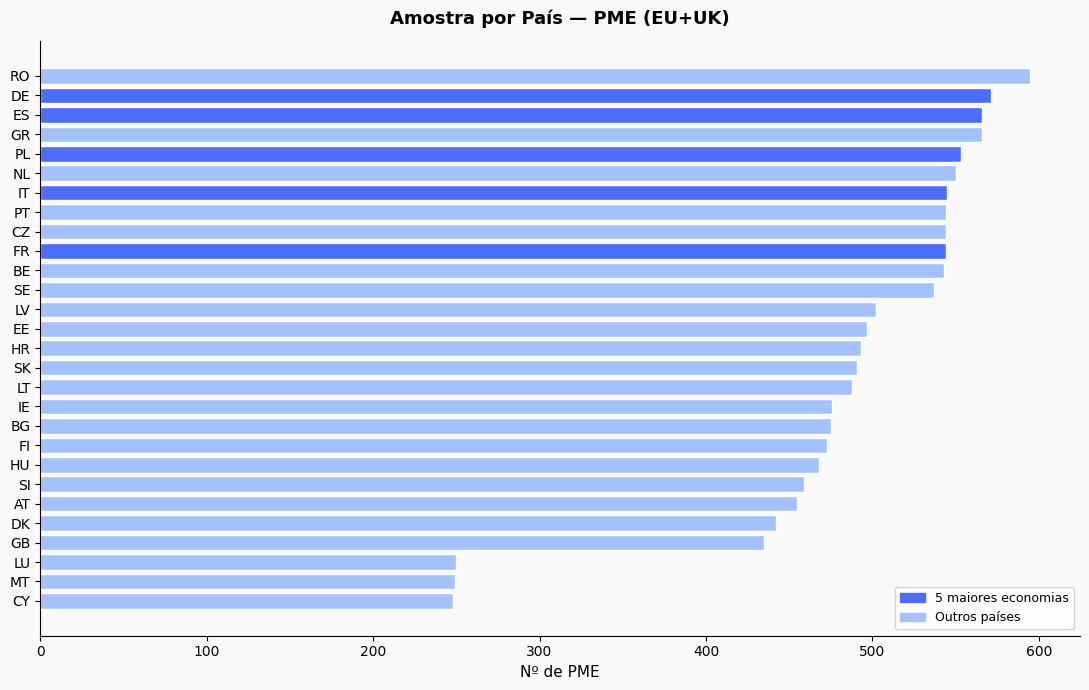

In [15]:
# Gráfico: dimensão da amostra por país
country_counts = df_key['isocntry'].value_counts().sort_values()
colors = [BLUE if c in ['DE','FR','IT','ES','PL'] else LIGHT_BLUE
          for c in country_counts.index]

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.barh(country_counts.index, country_counts.values, color=colors, edgecolor='white')
ax.set_xlabel('Nº de PME', fontsize=11)
ax.set_title('Amostra por País — PME (EU+UK)', fontsize=13, fontweight='bold', pad=12)
ax.legend(handles=[
    mpatches.Patch(color=BLUE,       label='5 maiores economias'),
    mpatches.Patch(color=LIGHT_BLUE, label='Outros países'),
], fontsize=9, loc='lower right')
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

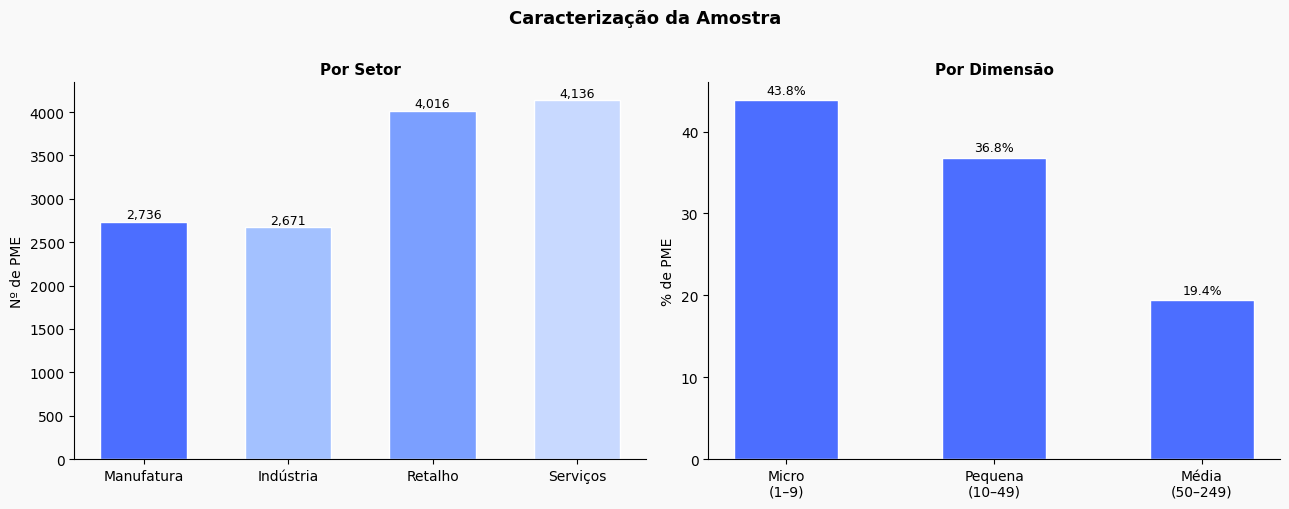

In [16]:
# Gráficos: distribuição por setor e dimensão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Setor
PALETTE = ['#4C6EFF','#A3C1FF','#7B9FFF','#C8D9FF']
sector_counts = df_key['nace_b'].value_counts()
bars = axes[0].bar(sector_short,
                   [sector_counts.get(s,0) for s in sector_order],
                   color=PALETTE, edgecolor='white', width=0.6)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x()+bar.get_width()/2, h+40,
                 f'{int(h):,}', ha='center', fontsize=9)
axes[0].set_ylabel('Nº de PME', fontsize=10)
axes[0].set_title('Por Setor', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Dimensão
size_counts = (df_key['scr10'].value_counts(normalize=True)
               .reindex(size_order, fill_value=0)*100)
bars2 = axes[1].bar(size_short, size_counts.values,
                    color=BLUE, width=0.5, edgecolor='white')
for bar, val in zip(bars2, size_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('% de PME', fontsize=10)
axes[1].set_title('Por Dimensão', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Caracterização da Amostra', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 2.2 Análise de Missing Values

> Identificação dos padrões de não-resposta — essencial para fundamentar as decisões de tratamento da Secção 3.
>
> **Nota importante:** As variáveis Q3, Q4 e Q7 só foram perguntadas às empresas que adotaram pelo menos uma prática de eficiência (Q1 ≥ 1). As empresas com NaN nestas variáveis são, portanto, as que responderam "não" a todas as práticas Q1 — trata-se de **lógica de salto do questionário**, não de não-resposta aleatória.

In [17]:
# Análise de missing values — contagem absoluta e percentagem
# Esta análise é essencial para fundamentar as decisões de tratamento da Secção 3
missing_n   = df_key.isnull().sum()
missing_pct = (missing_n / len(df_key) * 100).round(1)
missing_df  = pd.DataFrame({'n': missing_n, 'pct': missing_pct})
missing_df  = missing_df.query('n > 0').sort_values('pct', ascending=False)

print("=== MISSING VALUES — df_key ===")
print(missing_df.to_string())
print(f"\nVariáveis sem NAs: {(df_key.isnull().sum() == 0).sum()}")
print(f"Variáveis com NAs: {(df_key.isnull().sum() > 0).sum()}")

=== MISSING VALUES — df_key ===
          n  pct
q3      951  7.0
q4      951  7.0
q7.1    951  7.0
q7.3    951  7.0
q7.2    951  7.0
q7.4    951  7.0
q7.5    951  7.0
q7.9    951  7.0
q7.6    951  7.0
q7.7    951  7.0
q7.8    951  7.0
q7.11   951  7.0
q7.10   951  7.0
q7.12   951  7.0
scr13a  627  4.6

Variáveis sem NAs: 15
Variáveis com NAs: 15


In [18]:
# Identificação do padrão de NAs
# Hipótese: os NAs em q3/q4/q7.x correspondem a lógica de salto do questionário
# → empresas que não adotaram nenhuma prática Q1 não foram questionadas sobre Q3/Q4/Q7

mask_na = df_key['q3'].isnull()
print(f"Empresas com q3 nulo:         {mask_na.sum():,} ({mask_na.mean()*100:.1f}%)")
print(f"  → q4 também nulo:           {df_key[mask_na]['q4'].isnull().sum():,}")
print(f"  → q7.1 também nulo:         {df_key[mask_na]['q7.1'].isnull().sum():,}")
print(f"  → q7.10 também nulo:        {df_key[mask_na]['q7.10'].isnull().sum():,}")
print(f"  → isocntry nulo:            {df_key[mask_na]['isocntry'].isnull().sum():,}")
print("\n→ Todas as variáveis Q3/Q4/Q7 em falta para o mesmo bloco de empresas.")

# ── Prova da lógica de salto ──────────────────────────────────────────────────
# Se a hipótese estiver correta, TODAS estas empresas terão Q1 = 0 em todas as práticas
q1_cols = list(q1_map.keys())
na_q1_sum = df_key.loc[mask_na, q1_cols].apply(lambda c: (c == 1.0).sum()).sum()
print(f"\n=== VERIFICAÇÃO DA LÓGICA DE SALTO ===")
print(f"Empresas com NAs em Q3/Q4/Q7:    {mask_na.sum():,}")
print(f"  → total de práticas Q1=1 neste grupo: {na_q1_sum}")
print(f"  → TODAS têm Q1=0:              {na_q1_sum == 0}")
print(f"\n→ CONFIRMADO: 100% destas empresas têm Q1 = 0 (nenhuma prática adotada).")
print(f"   Os NAs em Q3/Q4/Q7 são lógica de salto do questionário, não missing aleatório.")
print(f"   Estas empresas devem ser MANTIDAS no dataset (não eliminadas).")
print(f"   → Na Secção 3: Q7 será codificado como 0 (barreiras não aplicáveis)")
print(f"     e Q3/Q4 receberão uma categoria indicadora ('Não questionado').")

print("\n=== PERFIL DAS EMPRESAS COM NAs (Q1 = 0) ===")
print("\nPor país (top 10):")
print(df_key[mask_na]['isocntry'].value_counts().head(10))
print("\nPor setor:")
print(df_key[mask_na]['nace_b'].map(sector_map).value_counts())
print("\nPor dimensão:")
print(df_key[mask_na]['scr10'].map(size_map).value_counts())


Empresas com q3 nulo:         951 (7.0%)
  → q4 também nulo:           951
  → q7.1 também nulo:         951
  → q7.10 também nulo:        951
  → isocntry nulo:            0

→ Todas as variáveis Q3/Q4/Q7 em falta para o mesmo bloco de empresas.

=== VERIFICAÇÃO DA LÓGICA DE SALTO ===
Empresas com NAs em Q3/Q4/Q7:    951
  → total de práticas Q1=1 neste grupo: 0
  → TODAS têm Q1=0:              True

→ CONFIRMADO: 100% destas empresas têm Q1 = 0 (nenhuma prática adotada).
   Os NAs em Q3/Q4/Q7 são lógica de salto do questionário, não missing aleatório.
   Estas empresas devem ser MANTIDAS no dataset (não eliminadas).
   → Na Secção 3: Q7 será codificado como 0 (barreiras não aplicáveis)
     e Q3/Q4 receberão uma categoria indicadora ('Não questionado').

=== PERFIL DAS EMPRESAS COM NAs (Q1 = 0) ===

Por país (top 10):
isocntry
LV    103
RO     81
EE     64
HR     58
PL     48
DE     47
GR     47
PT     47
HU     45
IE     42
Name: count, dtype: int64

Por setor:
nace_b
Serviços (H–M)

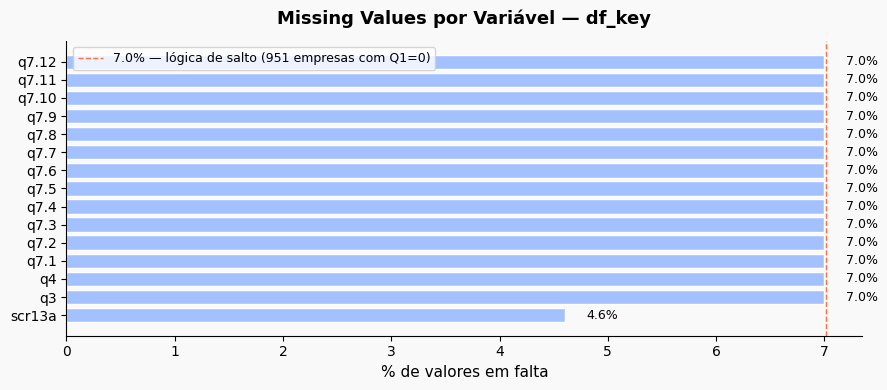

In [19]:
# Visualização dos missing values
# As barras a laranja indicam variáveis afetadas pela lógica de salto (Q1=0 → Q3/Q4/Q7 não perguntados)
n_na_bloco = df_key['q3'].isnull().sum()
pct_bloco  = n_na_bloco / len(df_key) * 100

missing_plot = (df_key.isnull().mean() * 100).round(1)
missing_plot = missing_plot[missing_plot > 0].sort_values()

fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
colors_m = [ORANGE if v >= pct_bloco else LIGHT_BLUE for v in missing_plot.values]
ax.barh(missing_plot.index, missing_plot.values, color=colors_m, edgecolor='white')
for bar, val in zip(ax.patches, missing_plot.values):
    ax.text(val+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.axvline(pct_bloco, color=ORANGE, linestyle='--', linewidth=1,
           label=f'{pct_bloco:.1f}% — lógica de salto ({n_na_bloco:,} empresas com Q1=0)')
ax.set_xlabel('% de valores em falta', fontsize=11)
ax.set_title('Missing Values por Variável — df_key', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2.3 Identificação de Outliers e Problemas de Qualidade

> Os problemas são mostrados aqui, **antes** de qualquer tratamento, para que as decisões da Secção 3 sejam fundamentadas.

### 2.3.1 scr12a — Anos de fundação impossíveis

In [20]:
# Outliers em scr12a (ano de fundação)
# scr12a é numérica contínua — esperamos anos entre ~1900 e 2024
# Código 9998.0 = DK/NA (específico desta variável, não apanhado pelo recoding geral)

scr12a_num = df['scr12a'].copy()
n_dkna_12a = (scr12a_num == 9998.0).sum()
scr12a_years = scr12a_num[(scr12a_num != 9998.0) & scr12a_num.notna()]

print("=== scr12a — ANO DE FUNDAÇÃO ===")
print(scr12a_years.describe())

print("\nValores mais antigos (possíveis outliers):")
print(scr12a_years.sort_values().head(20).value_counts().sort_index())

print("\nValores mais recentes:")
print(scr12a_years.sort_values().tail(5).value_counts().sort_index())

n_impossivel = (scr12a_years < 1900).sum()
print(f"\nAnos antes de 1900 (impossíveis): {n_impossivel}")
print(f"DK/NA (9998):                      {n_dkna_12a:,} ({n_dkna_12a/len(df)*100:.1f}%)")

# scr12 categórica como alternativa (código 5.0 = DK/NA)
n_dkna_12 = (df_key['scr12'] == 5.0).sum()
print(f"\n→ Decisão: usar scr12 (categórica) em vez de scr12a")
print(f"  scr12 tem apenas {n_dkna_12:,} DK/NA ({n_dkna_12/len(df_key)*100:.1f}%)")

=== scr12a — ANO DE FUNDAÇÃO ===
count    11809.000000
mean      2000.078669
std         20.912816
min       1750.000000
25%       1992.000000
50%       2004.000000
75%       2014.000000
max       2024.000000
Name: scr12a, dtype: float64

Valores mais antigos (possíveis outliers):
scr12a
1750.0    1
1777.0    1
1800.0    1
1802.0    1
1804.0    1
1812.0    1
1821.0    1
1823.0    1
1824.0    1
1829.0    1
1831.0    1
1839.0    1
1840.0    1
1841.0    1
1843.0    1
1852.0    1
1854.0    1
1856.0    2
1863.0    1
Name: count, dtype: int64

Valores mais recentes:
scr12a
2024.0    5
Name: count, dtype: int64

Anos antes de 1900 (impossíveis): 67
DK/NA (9998):                      1,750 (12.9%)

→ Decisão: usar scr12 (categórica) em vez de scr12a
  scr12 tem apenas 70 DK/NA (0.5%)


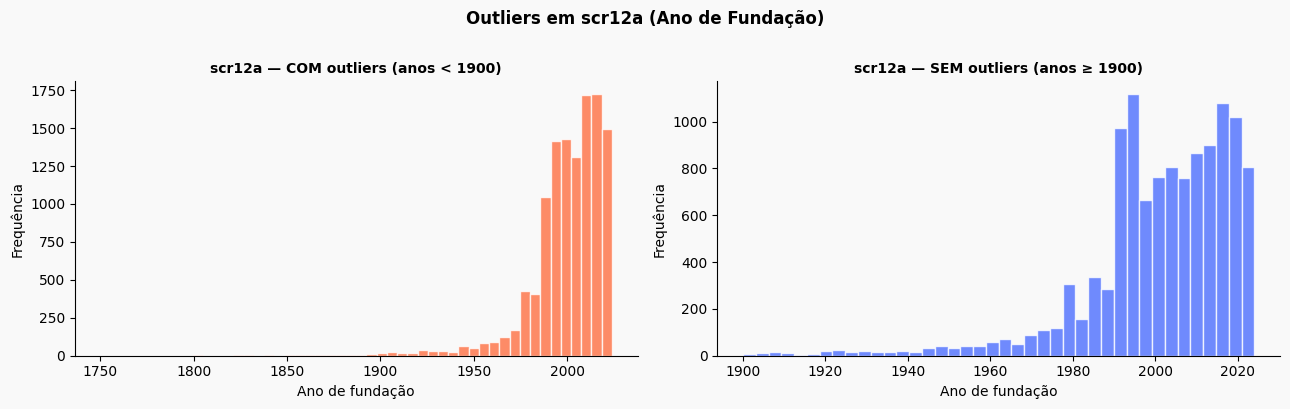

In [21]:
# Visualização da distribuição de scr12a — mostrar os outliers
scr12a_plot = scr12a_years.dropna()
scr12a_valid = scr12a_plot[scr12a_plot >= 1900]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=BG)

# Com outliers
axes[0].hist(scr12a_plot, bins=50, color=ORANGE, edgecolor='white', alpha=0.8)
axes[0].set_title('scr12a — COM outliers (anos < 1900)', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Ano de fundação'); axes[0].set_ylabel('Frequência')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Sem outliers
axes[1].hist(scr12a_valid, bins=40, color=BLUE, edgecolor='white', alpha=0.8)
axes[1].set_title('scr12a — SEM outliers (anos ≥ 1900)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Ano de fundação'); axes[1].set_ylabel('Frequência')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Outliers em scr12a (Ano de Fundação)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.3.2 scr10a — Nº exato de FTE (após filtro PME)

=== scr10a — Nº EXATO DE FTE (após filtro PME) ===
count    13071.000000
mean        31.743172
std         47.790328
min          0.000000
25%          3.000000
50%         12.000000
75%         38.000000
max        249.000000
Name: scr10a, dtype: float64

Valores > 249: 0 → deve ser 0 após filtro PME
Valores = 0:   224
Valores = 1:   1,362 (microempresas unipessoais — válidas)


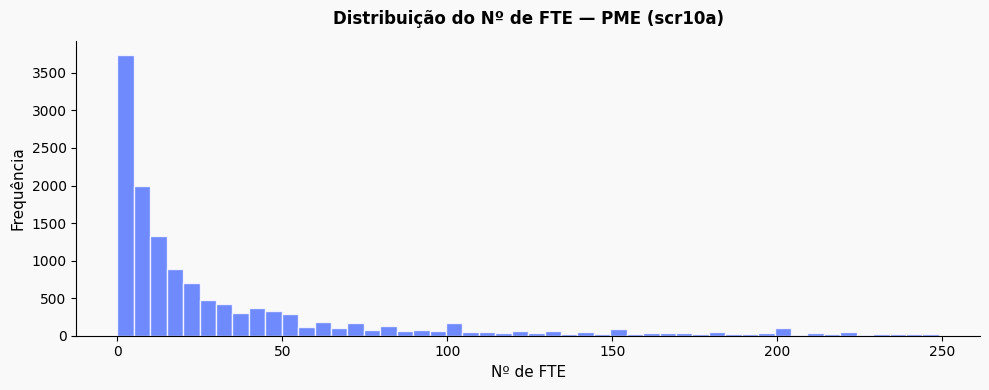

In [22]:
# Outliers em scr10a (nº exato de FTE)
# Após filtro PME esperamos apenas valores entre 1 e 249

scr10a_num = df['scr10a'].copy()

print("=== scr10a — Nº EXATO DE FTE (após filtro PME) ===")
print(scr10a_num.describe())
print(f"\nValores > 249: {(scr10a_num > 249).sum()} → deve ser 0 após filtro PME")
print(f"Valores = 0:   {(scr10a_num == 0).sum()}")
print(f"Valores = 1:   {(scr10a_num == 1).sum():,} (microempresas unipessoais — válidas)")

fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
ax.hist(scr10a_num.dropna(), bins=50, color=BLUE, edgecolor='white', alpha=0.8)
ax.set_xlabel('Nº de FTE', fontsize=11)
ax.set_ylabel('Frequência', fontsize=11)
ax.set_title('Distribuição do Nº de FTE — PME (scr10a)', fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.3.3 scr11b — Problema de construto

In [23]:
# Problema conceptual em scr11b — não é um outlier mas um problema de construto
# A variável mistura dois conceitos distintos:
#   (a) dificuldade de recrutamento — para quem tentou contratar
#   (b) decisão de não contratar — código 4.0 "Not relevant. Did not hire"
# Isto torna a variável não comparável numa escala única
#
# Códigos: 1=Muito difícil, 2=Algo difícil, 3=Nada difícil, 4=Não recrutou

scr11b_labels = {
    1.0: 'Muito difícil',
    2.0: 'Algo difícil',
    3.0: 'Nada difícil',
    4.0: 'Não recrutou',
}

print("=== scr11b — DIFICULDADE DE RECRUTAMENTO ===")
print(df['scr11b'].map(scr11b_labels).value_counts(dropna=False))
print()
n_not_relevant = (df['scr11b'] == 4.0).sum()
print(f"'Não recrutou' representa {n_not_relevant:,} empresas ({n_not_relevant/len(df)*100:.1f}%)")
print("→ Decisão: desdobrar em hired_bin + fin_difficulty (ver Secção 3)")

=== scr11b — DIFICULDADE DE RECRUTAMENTO ===
scr11b
Muito difícil    5061
Algo difícil     3475
Não recrutou     3069
Nada difícil     1819
NaN               135
Name: count, dtype: int64

'Não recrutou' representa 3,069 empresas (22.6%)
→ Decisão: desdobrar em hired_bin + fin_difficulty (ver Secção 3)


### 2.3.4 scr14 — Volume de negócios: DK/NA elevado

In [24]:
# Análise do DK/NA em scr14 (volume de negócios)
# Código 10.0 = DK/NA (específico desta variável)
# Empresas que não conhecem o seu volume de negócios tendem a ser microempresas
# sem contabilidade formal — excluí-las sub-representaria este segmento

scr14_labels = {
    1.0: '< 25k€', 2.0: '25–50k€', 3.0: '50–100k€',
    4.0: '100–250k€', 5.0: '250–500k€', 6.0: '500k–2M€',
    7.0: '2–10M€', 8.0: '10–50M€', 9.0: '> 50M€', 10.0: 'DK/NA',
}

print("=== scr14 — VOLUME DE NEGÓCIOS ANUAL ===")
print(df_key['scr14'].map(scr14_labels).value_counts(dropna=False))

n_dkna = (df_key['scr14'] == 10.0).sum()
print(f"\nDK/NA: {n_dkna:,} ({n_dkna/len(df_key)*100:.1f}%)")
print("→ Decisão: criar dummy turnover_unknown = 1 para preservar estas observações")

# Verificar se DK/NA se concentra em microempresas
print("\nDK/NA por dimensão:")
mask_dkna = df_key['scr14'] == 10.0
print(df_key[mask_dkna]['scr10'].map(size_map).value_counts())

=== scr14 — VOLUME DE NEGÓCIOS ANUAL ===
scr14
500k–2M€     2636
2–10M€       2197
DK/NA        1810
100–250k€    1522
250–500k€    1397
10–50M€      1116
50–100k€     1010
25–50k€       914
< 25k€        699
> 50M€        258
Name: count, dtype: int64

DK/NA: 1,810 (13.3%)
→ Decisão: criar dummy turnover_unknown = 1 para preservar estas observações

DK/NA por dimensão:
scr10
Micro (1–9)        772
Pequena (10–49)    651
Média (50–249)     387
Name: count, dtype: int64


### 2.3.5 Resumo dos problemas identificados

In [25]:
# Resumo dos problemas identificados na AED — serão tratados na Secção 3
n_na_skip = df_key['q3'].isnull().sum()
pct_na = n_na_skip / len(df_key) * 100

print("=" * 60)
print("  RESUMO — PROBLEMAS IDENTIFICADOS NA AED")
print("=" * 60)
print()
print(f"1. LÓGICA DE SALTO DO QUESTIONÁRIO ({pct_na:.1f}% — {n_na_skip:,} empresas)")
print("   Variáveis: q3, q4, q7.1–q7.12")
print("   Causa: empresas com Q1=0 (nenhuma prática) não foram questionadas")
print("   → NÃO é missing aleatório — é informação determinística")
print("   Tratamento: MANTER no dataset")
print("     • Q7 → codificar como 0 (barreiras não aplicáveis)")
print("     • Q3/Q4 → categoria indicadora 'Não questionado'")
print()
print("2. scr12a — ANOS DE FUNDAÇÃO IMPOSSÍVEIS")
print("   Problema: valores como 1750, 1777, 1800...")
print("   Tratamento: substituir por scr12 (categórica, poucos DK/NA)")
print()
print("3. scr11b — PROBLEMA DE CONSTRUTO")
print("   Problema: mistura dificuldade de recrutamento com não-recrutamento")
print("   Tratamento: desdobrar em hired_bin + fin_difficulty")
print()
n_dkna_14 = (df_key['scr14'] == 10.0).sum()
print(f"4. scr14 — {n_dkna_14/len(df_key)*100:.1f}% DK/NA")
print("   Problema: muitos DK/NA para exclusão simples")
print("   Tratamento: manter + criar dummy turnover_unknown")
print()
print("5. q3, q4 — ~10% DK/NA (além da lógica de salto)")
print("   Problema: DK/NA informativo (menor sofisticação de gestão)")
print("   Tratamento: manter como categoria separada")
print("=" * 60)

  RESUMO — PROBLEMAS IDENTIFICADOS NA AED

1. LÓGICA DE SALTO DO QUESTIONÁRIO (7.0% — 951 empresas)
   Variáveis: q3, q4, q7.1–q7.12
   Causa: empresas com Q1=0 (nenhuma prática) não foram questionadas
   → NÃO é missing aleatório — é informação determinística
   Tratamento: MANTER no dataset
     • Q7 → codificar como 0 (barreiras não aplicáveis)
     • Q3/Q4 → categoria indicadora 'Não questionado'

2. scr12a — ANOS DE FUNDAÇÃO IMPOSSÍVEIS
   Problema: valores como 1750, 1777, 1800...
   Tratamento: substituir por scr12 (categórica, poucos DK/NA)

3. scr11b — PROBLEMA DE CONSTRUTO
   Problema: mistura dificuldade de recrutamento com não-recrutamento
   Tratamento: desdobrar em hired_bin + fin_difficulty

4. scr14 — 13.3% DK/NA
   Problema: muitos DK/NA para exclusão simples
   Tratamento: manter + criar dummy turnover_unknown

5. q3, q4 — ~10% DK/NA (além da lógica de salto)
   Problema: DK/NA informativo (menor sofisticação de gestão)
   Tratamento: manter como categoria separada


## 2.4 Variável Dependente — Análise Univariada

> O índice de intensidade é construído aqui sobre o df_key (com NAs) apenas para fins exploratórios. O índice final para modelação é construído na Secção 3 sobre o df_model.

In [26]:
# Construção prévia do índice para análise exploratória
# Q1.x: 0.0 = não mencionada, 1.0 = mencionada → já binárias
# Nota: construído sobre df_key (com NAs) apenas para a AED

q1_cols = list(q1_map.keys())
for col in q1_cols:
    df_key[col+'_bin'] = (df_key[col] == 1.0).astype(int)

bin_cols = [c+'_bin' for c in q1_cols]
df_key['intensity_index'] = df_key[bin_cols].sum(axis=1)

print("=== ÍNDICE DE INTENSIDADE — df_key (inclui NAs) ===")
print(df_key['intensity_index'].value_counts().sort_index())
print(f"\nMédia:   {df_key['intensity_index'].mean():.2f}")
print(f"Mediana: {df_key['intensity_index'].median():.1f}")
print(f"Std:     {df_key['intensity_index'].std():.2f}")
print(f"Mín/Máx: {int(df_key['intensity_index'].min())} / {int(df_key['intensity_index'].max())}")

=== ÍNDICE DE INTENSIDADE — df_key (inclui NAs) ===
intensity_index
0     951
1    1183
2    1449
3    1963
4    2234
5    2094
6    1660
7    1202
8     613
9     210
Name: count, dtype: int64

Média:   4.02
Mediana: 4.0
Std:     2.24
Mín/Máx: 0 / 9


In [27]:
# Confirmação: empresas da lógica de salto (Q3=NaN) vs restantes
# Este teste NÃO serve para avaliar aleatoriedade do missing —
# sabemos que é determinístico (Q1=0 → Q3/Q4/Q7 não perguntados).
# Serve apenas para quantificar a diferença no índice entre os dois grupos.

mask_na = df_key['q3'].isnull()

print("=== COMPARAÇÃO: EMPRESAS COM Q1=0 (salto) vs Q1≥1 ===")
print(f"\nEmpresas com Q1=0 (lógica de salto):  {mask_na.sum():,}")
print(f"  Índice: {df_key[mask_na]['intensity_index'].mean():.2f} (por definição = 0)")
print(f"\nEmpresas com Q1≥1 (responderam Q3/Q4/Q7): {(~mask_na).sum():,}")
print(f"  Índice médio: {df_key[~mask_na]['intensity_index'].mean():.2f}")
print(f"  Índice mediano: {df_key[~mask_na]['intensity_index'].median():.1f}")

print(f"\n→ A diferença é trivialmente significativa porque o grupo Q1=0 tem")
print(f"  índice=0 por construção. Não se trata de missing — são empresas que")
print(f"  genuinamente não adotaram nenhuma prática de eficiência de recursos.")
print(f"  Eliminá-las (listwise deletion) removeria informação válida e enviesaria")
print(f"  o modelo para cima.")

=== COMPARAÇÃO: EMPRESAS COM Q1=0 (salto) vs Q1≥1 ===

Empresas com Q1=0 (lógica de salto):  951
  Índice: 0.00 (por definição = 0)

Empresas com Q1≥1 (responderam Q3/Q4/Q7): 12,608
  Índice médio: 4.33
  Índice mediano: 4.0

→ A diferença é trivialmente significativa porque o grupo Q1=0 tem
  índice=0 por construção. Não se trata de missing — são empresas que
  genuinamente não adotaram nenhuma prática de eficiência de recursos.
  Eliminá-las (listwise deletion) removeria informação válida e enviesaria
  o modelo para cima.


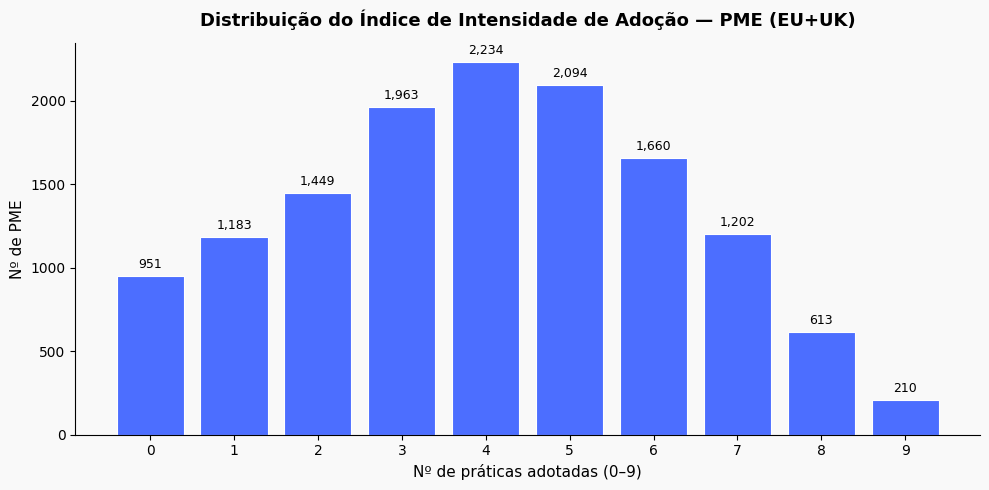

In [28]:
# Distribuição do índice de intensidade — primeiro olhar sobre a VD

counts = df_key['intensity_index'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
bars = ax.bar(counts.index, counts.values, color=BLUE, edgecolor='white', linewidth=0.8)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+30,
            f'{int(h):,}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Nº de práticas adotadas (0–9)', fontsize=11)
ax.set_ylabel('Nº de PME', fontsize=11)
ax.set_title('Distribuição do Índice de Intensidade de Adoção — PME (EU+UK)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(range(10))
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

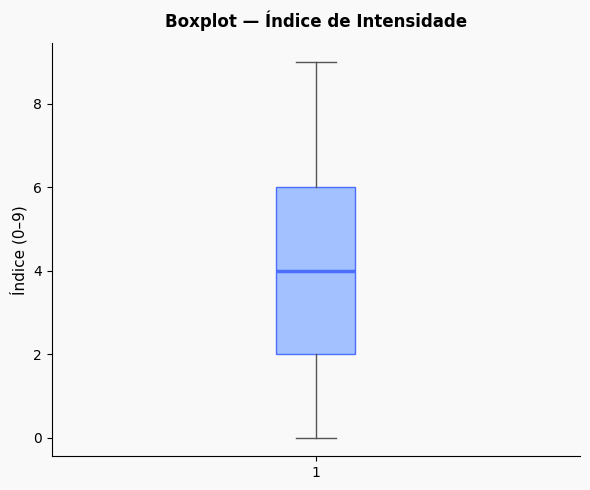

count    13559.00
mean         4.02
std          2.24
min          0.00
25%          2.00
50%          4.00
75%          6.00
max          9.00
Name: intensity_index, dtype: float64


In [29]:
# Boxplot do índice — distribuição, mediana e valores extremos

fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
ax.boxplot(df_key['intensity_index'].dropna(), patch_artist=True,
           boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
           medianprops=dict(color=BLUE, linewidth=2.5),
           whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
           flierprops=dict(marker='o', color=ORANGE, alpha=0.3, markersize=3))
ax.set_ylabel('Índice (0–9)', fontsize=11)
ax.set_title('Boxplot — Índice de Intensidade', fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

print(df_key['intensity_index'].describe().round(2))

### 2.4.1 Impacto dos Pesos de Inquérito (w1_sme)

> Os pesos pós-estratificação corrigem desvios entre a amostra e a população-alvo. Comparar estatísticas ponderadas e não ponderadas permite avaliar a magnitude do viés amostral.

In [30]:
# Comparação ponderada vs não ponderada — índice de intensidade
# w1_sme: peso pós-estratificação para PME (média ≈ 1.0)

w = df_key['w1_sme']
idx = df_key['intensity_index']

# Média ponderada
wt_mean = np.average(idx, weights=w)
# Variância ponderada (reliability weights)
wt_var  = np.average((idx - wt_mean)**2, weights=w)
wt_std  = np.sqrt(wt_var)

print("=== ÍNDICE DE INTENSIDADE — PONDERADO vs NÃO PONDERADO ===")
print(f"{'Estatística':<20} {'Não ponderado':>15} {'Ponderado (w1_sme)':>20}")
print(f"{'─'*57}")
print(f"{'Média':<20} {idx.mean():>15.3f} {wt_mean:>20.3f}")
print(f"{'Desvio-padrão':<20} {idx.std():>15.3f} {wt_std:>20.3f}")
print(f"{'Mediana':<20} {idx.median():>15.1f} {'—':>20}")
print(f"{'N':<20} {len(idx):>15,} {len(idx):>20,}")

diff = idx.mean() - wt_mean
print(f"\nDiferença (não pond. − pond.): {diff:+.3f}")
print(f"→ A média não ponderada sobrestima o índice em {diff:.2f} pontos (escala 0–9).")
print(f"   Isto indica que países/segmentos com maior adoção estão sobre-representados na amostra.")

# Comparação por dimensão — onde o peso mais importa?
print(f"\n{'─'*60}")
print(f"{'Dimensão':<20} {'Não pond.':>10} {'Ponderado':>10} {'Diferença':>10}")
print(f"{'─'*60}")
for s in size_order:
    mask = df_key['scr10'] == s
    uw = idx[mask].mean()
    wm = np.average(idx[mask], weights=w[mask])
    print(f"{size_map[s]:<20} {uw:>10.3f} {wm:>10.3f} {uw-wm:>+10.3f}")

# Comparação por setor
print(f"\n{'─'*60}")
print(f"{'Setor':<25} {'Não pond.':>10} {'Ponderado':>10} {'Diferença':>10}")
print(f"{'─'*60}")
for s in sector_order:
    mask = df_key['nace_b'] == s
    uw = idx[mask].mean()
    wm = np.average(idx[mask], weights=w[mask])
    print(f"{sector_map[s]:<25} {uw:>10.3f} {wm:>10.3f} {uw-wm:>+10.3f}")

=== ÍNDICE DE INTENSIDADE — PONDERADO vs NÃO PONDERADO ===
Estatística            Não ponderado   Ponderado (w1_sme)
─────────────────────────────────────────────────────────
Média                          4.023                3.648


Desvio-padrão                  2.243                2.231
Mediana                          4.0                    —
N                             13,559               13,559

Diferença (não pond. − pond.): +0.374
→ A média não ponderada sobrestima o índice em 0.37 pontos (escala 0–9).
   Isto indica que países/segmentos com maior adoção estão sobre-representados na amostra.

────────────────────────────────────────────────────────────
Dimensão              Não pond.  Ponderado  Diferença
────────────────────────────────────────────────────────────
Micro (1–9)               3.690      3.618     +0.072
Pequena (10–49)           4.128      4.027     +0.101
Média (50–249)            4.575      4.449     +0.126

────────────────────────────────────────────────────────────
Setor                      Não pond.  Ponderado  Diferença
────────────────────────────────────────────────────────────
Manufatura (C)                 4.498      4.227     +0.271
Indústria (B/D/E/F)            4.027      3

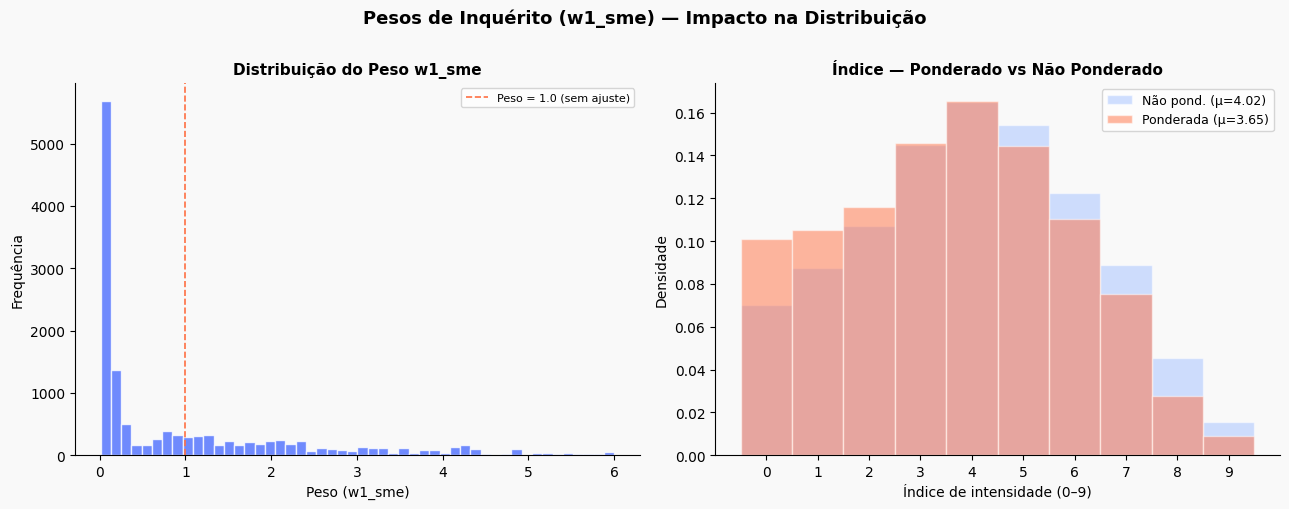

Peso w1_sme: média=1.000, std=1.341, min=0.011, max=6.000


In [31]:
# Distribuição dos pesos e comparação visual ponderada vs não ponderada

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Distribuição do peso w1_sme
axes[0].hist(df_key['w1_sme'].dropna(), bins=50, color=BLUE, edgecolor='white', alpha=0.8)
axes[0].axvline(1.0, color=ORANGE, linestyle='--', linewidth=1.2, label='Peso = 1.0 (sem ajuste)')
axes[0].set_xlabel('Peso (w1_sme)', fontsize=10)
axes[0].set_ylabel('Frequência', fontsize=10)
axes[0].set_title('Distribuição do Peso w1_sme', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Comparação: distribuição ponderada vs não ponderada do índice
bins = np.arange(-0.5, 10.5, 1)
# Não ponderada
axes[1].hist(idx, bins=bins, density=True, alpha=0.5, color=LIGHT_BLUE,
             edgecolor='white', label=f'Não pond. (μ={idx.mean():.2f})')
# Ponderada
axes[1].hist(idx, bins=bins, density=True, weights=w, alpha=0.5, color=ORANGE,
             edgecolor='white', label=f'Ponderada (μ={wt_mean:.2f})')
axes[1].set_xlabel('Índice de intensidade (0–9)', fontsize=10)
axes[1].set_ylabel('Densidade', fontsize=10)
axes[1].set_title('Índice — Ponderado vs Não Ponderado', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(10))
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Pesos de Inquérito (w1_sme) — Impacto na Distribuição',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f"Peso w1_sme: média={w.mean():.3f}, std={w.std():.3f}, min={w.min():.3f}, max={w.max():.3f}")

In [32]:
# Empresas nos extremos do índice — quem são?

print("=== EMPRESAS COM ÍNDICE = 0 (nenhuma prática) ===")
zero = df_key[df_key['intensity_index'] == 0]
print(f"Total: {len(zero):,} ({len(zero)/len(df_key)*100:.1f}%)")
print("\nPor setor:")
print(zero['nace_b'].map(sector_map).value_counts())
print("\nPor dimensão:")
print(zero['scr10'].map(size_map).value_counts())

print("\n=== EMPRESAS COM ÍNDICE = 9 (todas as práticas) ===")
nine = df_key[df_key['intensity_index'] == 9]
print(f"Total: {len(nine):,} ({len(nine)/len(df_key)*100:.1f}%)")
print("\nPor setor:")
print(nine['nace_b'].map(sector_map).value_counts())
print("\nPor dimensão:")
print(nine['scr10'].map(size_map).value_counts())

=== EMPRESAS COM ÍNDICE = 0 (nenhuma prática) ===
Total: 951 (7.0%)

Por setor:
nace_b
Serviços (H–M)         393
Retalho (G)            272
Indústria (B/D/E/F)    174
Manufatura (C)         112
Name: count, dtype: int64

Por dimensão:
scr10
Micro (1–9)        561
Pequena (10–49)    304
Média (50–249)      86
Name: count, dtype: int64

=== EMPRESAS COM ÍNDICE = 9 (todas as práticas) ===
Total: 210 (1.5%)

Por setor:
nace_b
Manufatura (C)         68
Retalho (G)            60
Serviços (H–M)         48
Indústria (B/D/E/F)    34
Name: count, dtype: int64

Por dimensão:
scr10
Pequena (10–49)    90
Média (50–249)     71
Micro (1–9)        49
Name: count, dtype: int64


In [33]:
# Taxa de adoção por prática — counts e percentagem

print("=== TAXA DE ADOÇÃO POR PRÁTICA (PME — EU+UK) ===")
for col, label in q1_map.items():
    n   = df_key[col+'_bin'].sum()
    pct = df_key[col+'_bin'].mean() * 100
    bar = '█' * int(pct/5)
    print(f"  {label:<35} {n:>5,}  ({pct:.1f}%)  {bar}")

=== TAXA DE ADOÇÃO POR PRÁTICA (PME — EU+UK) ===
  Poupar água                         6,452  (47.6%)  █████████
  Poupar energia                      8,844  (65.2%)  █████████████
  Energia renovável                   3,617  (26.7%)  █████
  Poupar materiais                    7,758  (57.2%)  ███████████
  Fornecedores mais verdes            4,821  (35.6%)  ███████
  Minimizar resíduos                  8,814  (65.0%)  █████████████
  Vender resíduos                     4,010  (29.6%)  █████
  Reciclar internamente               6,438  (47.5%)  █████████
  Eco-design                          3,790  (28.0%)  █████


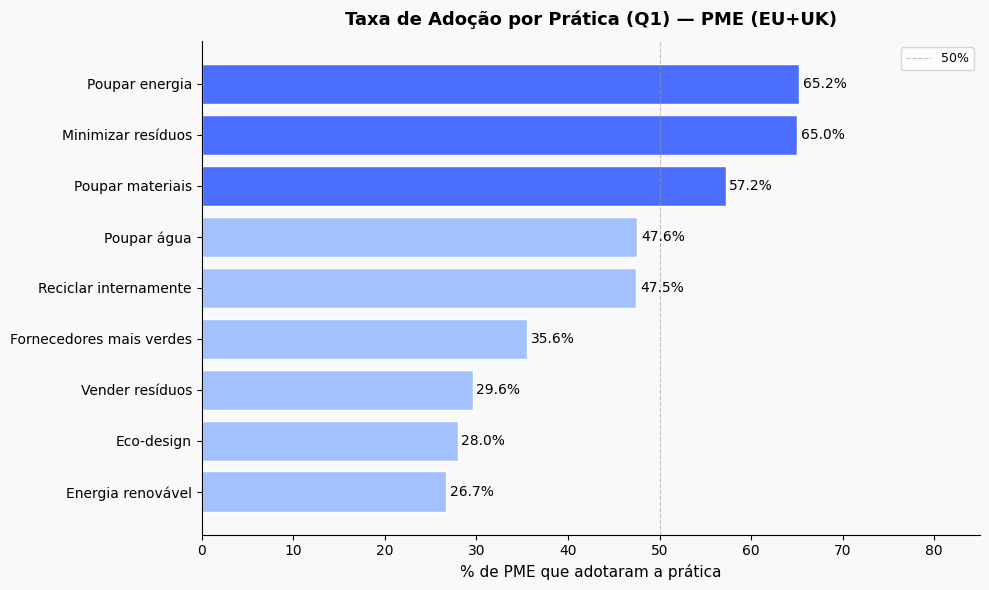

In [34]:
# Gráfico: taxa de adoção por prática
eu_q1 = {label: df_key[col+'_bin'].mean()*100 for col, label in q1_map.items()}
sorted_items = sorted(eu_q1.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
colors_q1 = [BLUE if v >= 50 else LIGHT_BLUE for _, v in sorted_items]
bars = ax.barh([i[0] for i in sorted_items], [i[1] for i in sorted_items],
               color=colors_q1, edgecolor='white')
for bar, val in zip(bars, [i[1] for i in sorted_items]):
    ax.text(val+0.4, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.axvline(50, color='#999', linestyle='--', linewidth=0.8, alpha=0.6, label='50%')
ax.set_xlabel('% de PME que adotaram a prática', fontsize=11)
ax.set_title('Taxa de Adoção por Prática (Q1) — PME (EU+UK)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 85)
ax.legend(fontsize=9)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2.5 Variável Dependente × País

In [35]:
# Índice médio por país — tabela com estatísticas completas
country_stats = (
    df_key.groupby('isocntry')['intensity_index']
    .agg(['mean','median','std','count'])
    .round(2)
    .sort_values('mean', ascending=False)
)
print("=== ÍNDICE MÉDIO POR PAÍS ===")
print(country_stats.to_string())
print(f"\nAmplitude (máx - mín): {country_stats['mean'].max() - country_stats['mean'].min():.2f}")

=== ÍNDICE MÉDIO POR PAÍS ===
          mean  median   std  count
isocntry                           
ES        5.76     6.0  1.91    566
BE        5.34     6.0  2.14    543
SE        5.34     6.0  2.29    537
LT        4.76     5.0  2.21    488
SK        4.73     5.0  2.13    491
FI        4.62     5.0  2.39    473
FR        4.57     5.0  2.27    544
DK        4.57     5.0  2.33    442
CZ        4.52     5.0  2.23    544
DE        4.25     4.0  2.41    571
GR        4.21     5.0  2.34    566
NL        4.08     4.0  1.48    550
LU        4.02     4.0  1.50    250
AT        3.99     4.0  1.36    455
IT        3.97     4.0  1.52    545
GB        3.93     4.0  1.40    435
HU        3.90     4.0  2.32    468
RO        3.76     4.0  2.57    595
BG        3.67     3.0  2.32    475
SI        3.64     3.0  2.43    459
PL        3.31     3.0  2.02    553
MT        3.27     3.0  1.41    249
EE        3.15     3.0  2.37    497
HR        2.98     3.0  2.24    493
CY        2.96     3.0  2.08    24

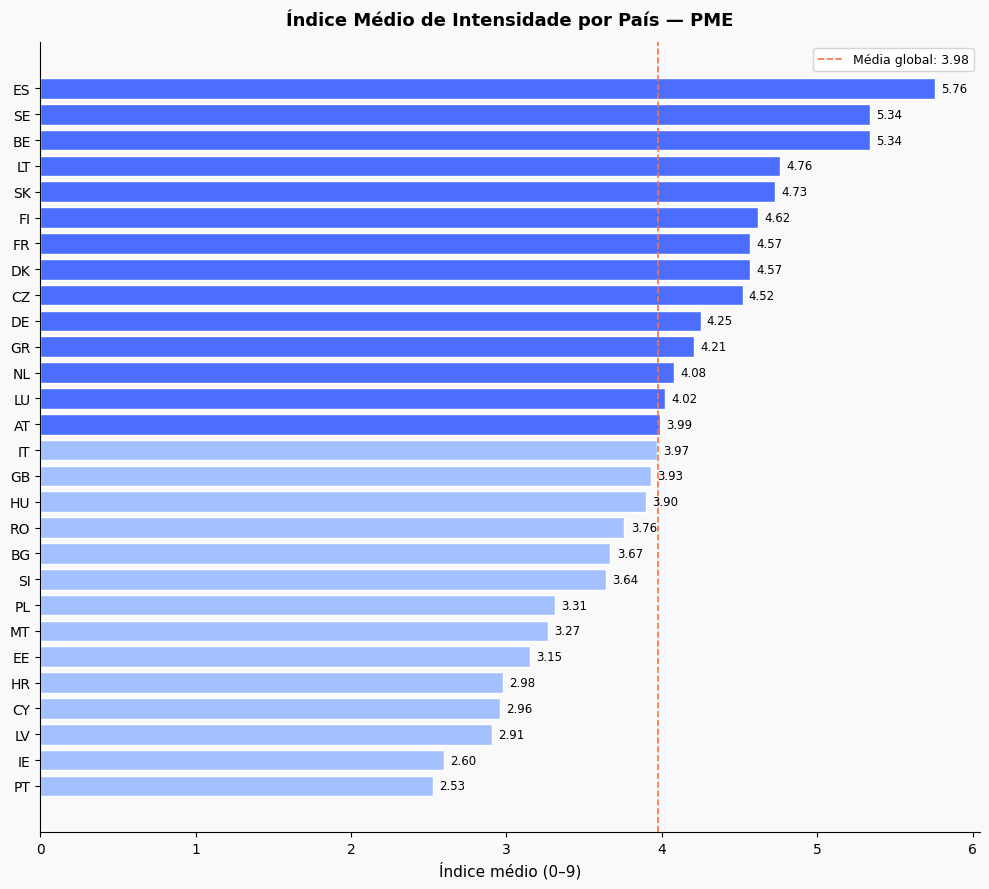

In [36]:
# Gráfico: índice médio por país — acima/abaixo da média global destacados
country_means = df_key.groupby('isocntry')['intensity_index'].mean().round(2).sort_values()
global_mean   = country_means.mean()

fig, ax = plt.subplots(figsize=(10, 9), facecolor=BG)
colors_c = [BLUE if v >= global_mean else LIGHT_BLUE for v in country_means.values]
ax.barh(country_means.index, country_means.values, color=colors_c, edgecolor='white')
ax.axvline(global_mean, color=ORANGE, linestyle='--', linewidth=1.2,
           label=f"Média global: {global_mean:.2f}")
for i, val in enumerate(country_means.values):
    ax.text(val+0.04, i, f'{val:.2f}', va='center', fontsize=8.5)
ax.set_xlabel('Índice médio (0–9)', fontsize=11)
ax.set_title('Índice Médio de Intensidade por País — PME',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

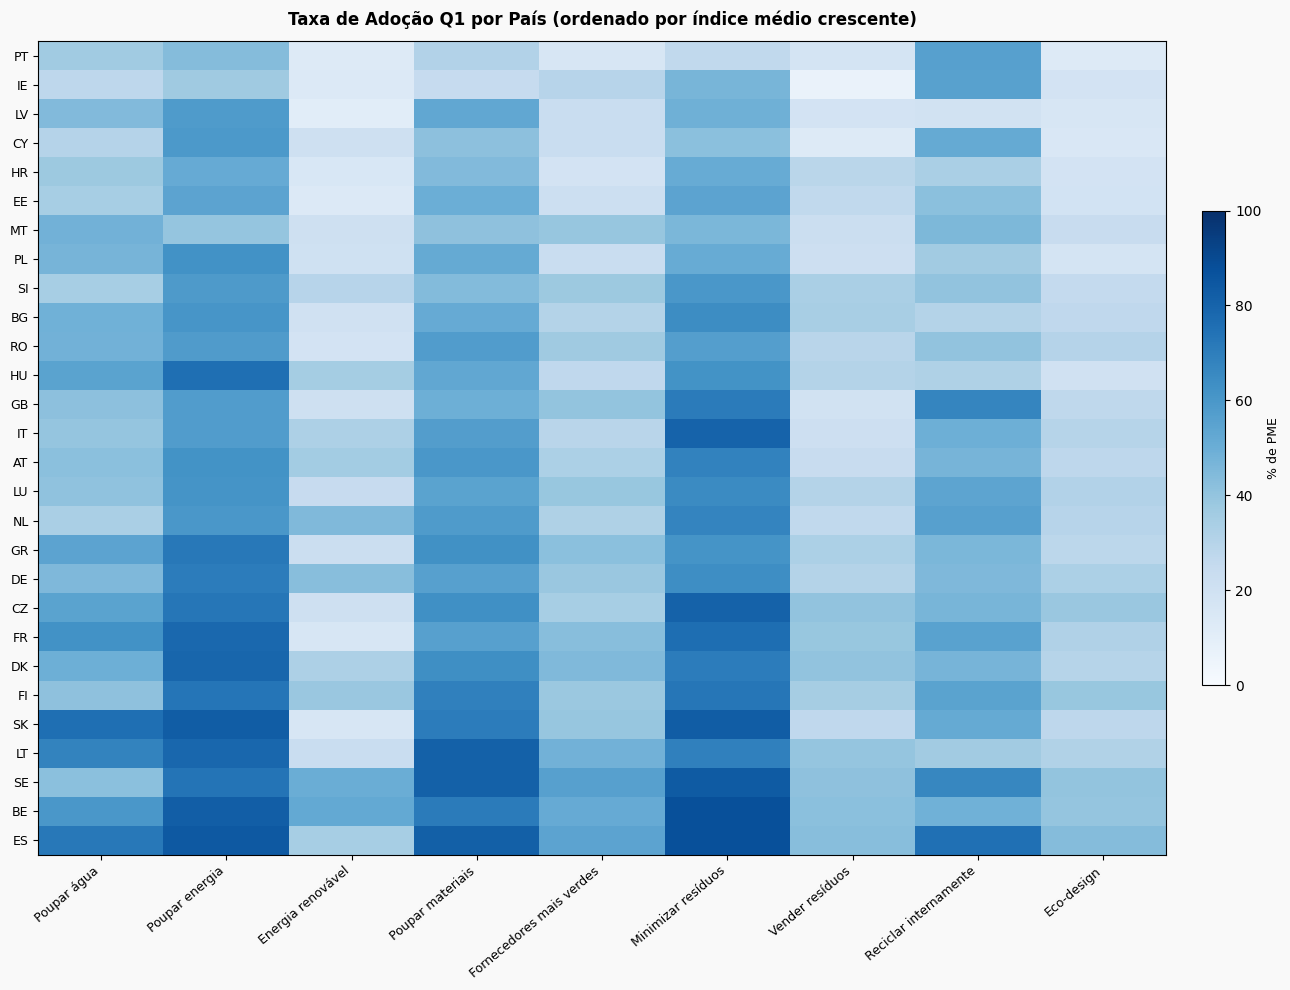

In [37]:
# Heatmap: taxa de adoção de cada prática Q1 por país
# Ordenado do país com menor para o de maior intensidade média

q1_cols_bin = [c+'_bin' for c in q1_map.keys()]
country_q1  = (df_key.groupby('isocntry')[q1_cols_bin].mean()*100).round(1)
country_q1.columns = list(q1_map.values())
country_order_c = df_key.groupby('isocntry')['intensity_index'].mean().sort_values().index
country_q1 = country_q1.reindex(country_order_c)

fig, ax = plt.subplots(figsize=(13, 10), facecolor=BG)
im = ax.imshow(country_q1.values, cmap='Blues', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(9))
ax.set_xticklabels(list(q1_map.values()), rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(country_q1.index)))
ax.set_yticklabels(country_q1.index, fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.03).set_label('% de PME', fontsize=9)
ax.set_title('Taxa de Adoção Q1 por País (ordenado por índice médio crescente)',
             fontsize=12, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

## 2.6 Análise Bivariada — VD × Variáveis Independentes

> As relações bivariadas apresentadas aqui são análises descritivas não ajustadas. As relações controladas serão estimadas nos modelos de regressão.

### 2.6.1 VD × Setor de Atividade

=== VD × SETOR ===
        mean  median   std  count
nace_b                           
1.0     4.50     5.0  2.22   2736
2.0     4.03     4.0  2.23   2671
3.0     4.02     4.0  2.23   4016
4.0     3.71     4.0  2.23   4136


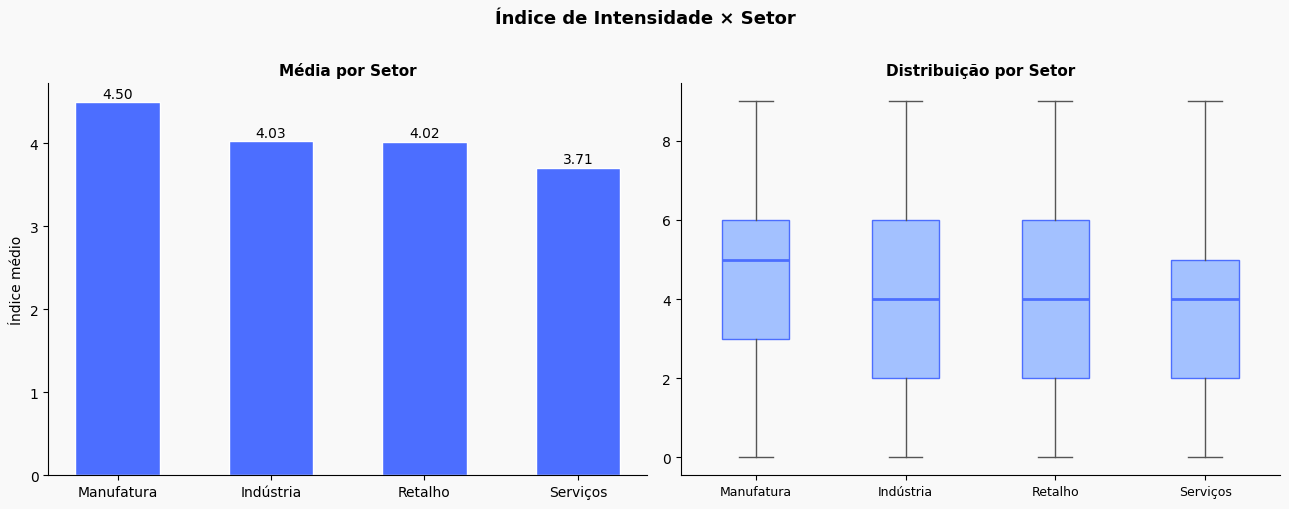

In [38]:
# VD × Setor — tabela e visualização

print("=== VD × SETOR ===")
print(df_key.groupby('nace_b')['intensity_index']
      .agg(['mean','median','std','count'])
      .round(2).sort_values('mean', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

means = df_key.groupby('nace_b')['intensity_index'].mean().reindex(sector_order)
axes[0].bar(sector_short, means.values, color=BLUE, edgecolor='white', width=0.55)
for i, val in enumerate(means.values):
    axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Índice médio', fontsize=10)
axes[0].set_title('Média por Setor', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_s = [df_key[df_key['nace_b']==s]['intensity_index'].dropna().values for s in sector_order]
axes[1].boxplot(data_s, patch_artist=True,
                boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
                medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_xticklabels(sector_short, fontsize=9)
axes[1].set_title('Distribuição por Setor', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Índice de Intensidade × Setor', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.6.2 VD × Dimensão da Empresa

=== VD × DIMENSÃO ===
       mean  median   std  count
scr10                           
1.0    3.69     4.0  2.22   5941
2.0    4.13     4.0  2.24   4992
3.0    4.57     5.0  2.18   2626


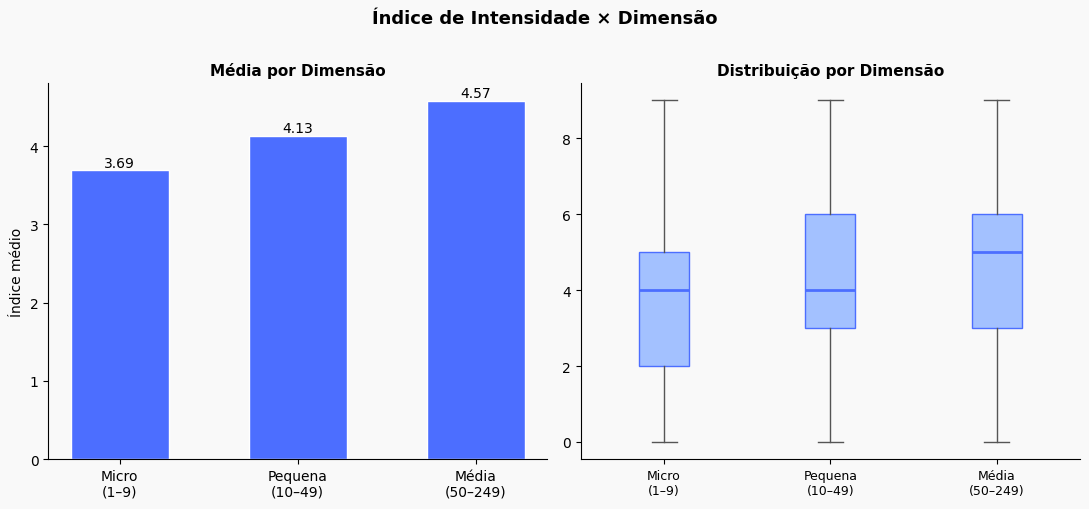

In [39]:
# VD × Dimensão — tabela e visualização

print("=== VD × DIMENSÃO ===")
print(df_key[df_key['scr10'].isin(size_order)]
      .groupby('scr10')['intensity_index']
      .agg(['mean','median','std','count'])
      .reindex(size_order).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), facecolor=BG)

df_s    = df_key[df_key['scr10'].isin(size_order)]
means_s = df_s.groupby('scr10')['intensity_index'].mean().reindex(size_order)
axes[0].bar(size_short, means_s.values, color=BLUE, edgecolor='white', width=0.55)
for i, val in enumerate(means_s.values):
    axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Índice médio', fontsize=10)
axes[0].set_title('Média por Dimensão', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_sz = [df_s[df_s['scr10']==s]['intensity_index'].dropna().values for s in size_order]
axes[1].boxplot(data_sz, patch_artist=True,
                boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
                medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_xticklabels(size_short, fontsize=9)
axes[1].set_title('Distribuição por Dimensão', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Índice de Intensidade × Dimensão', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 2.6.3 Cruzamento Setor × Dimensão

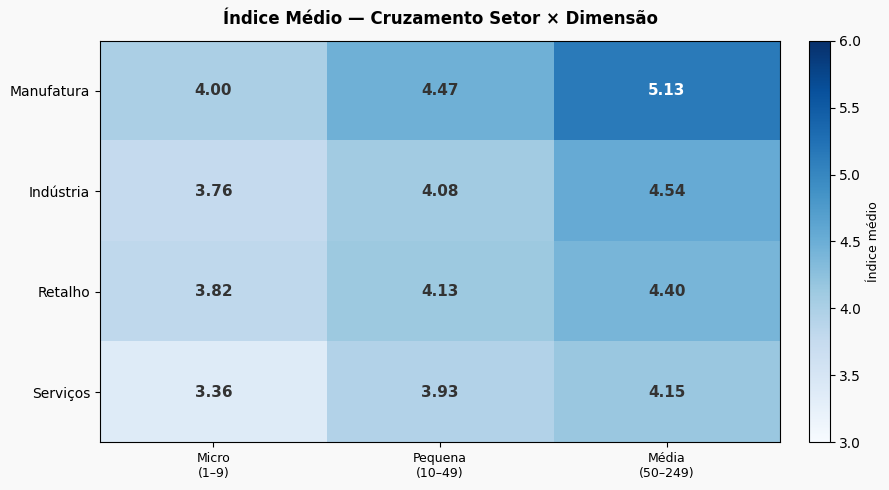

In [40]:
# Cruzamento Setor × Dimensão — heatmap do índice médio

df_cross = df_key[df_key['scr10'].isin(size_order)].copy()
pivot = df_cross.groupby(['nace_b','scr10'])['intensity_index'].mean().unstack()
pivot = pivot.reindex(index=sector_order, columns=size_order)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto', vmin=3, vmax=6)
ax.set_xticks(range(3)); ax.set_xticklabels(size_short, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(sector_short, fontsize=10)
for i in range(4):
    for j in range(3):
        val = pivot.values[i,j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=11, color='white' if val > 5 else '#333', fontweight='bold')
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04).set_label('Índice médio', fontsize=9)
ax.set_title('Índice Médio — Cruzamento Setor × Dimensão',
             fontsize=12, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

### 2.6.4 VD × Antiguidade da Empresa (scr12)

=== VD × ANTIGUIDADE (scr12) ===
       mean  median   std  count
scr12                           
1.0    4.08     4.0  2.25  10791
2.0    3.84     4.0  2.22   1191
3.0    3.76     4.0  2.22   1229
4.0    3.90     4.0  1.97    278
5.0    2.96     3.0  1.92     70


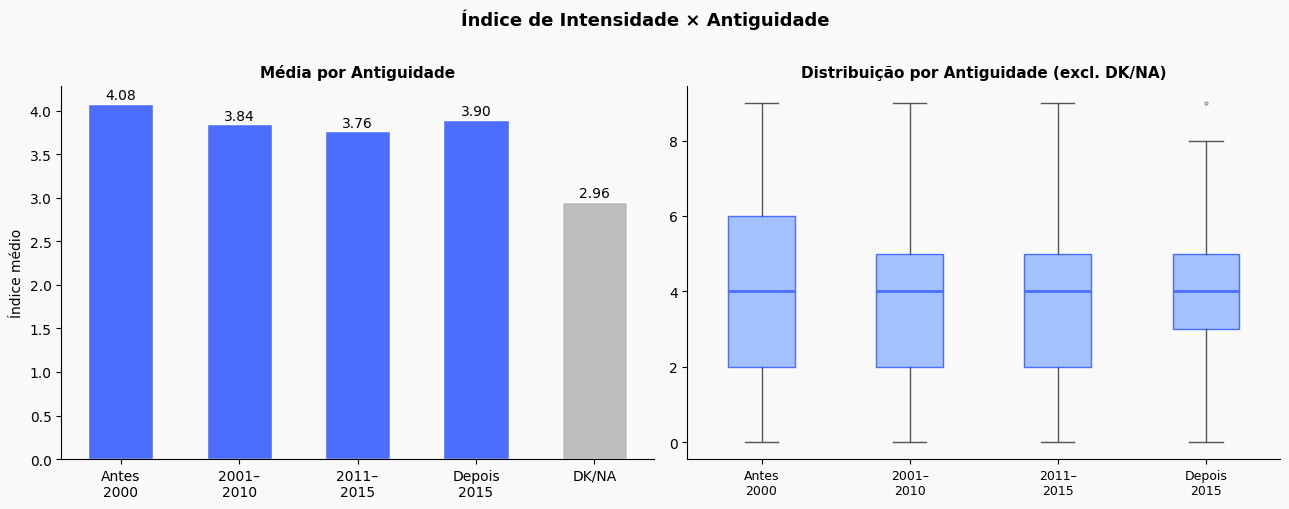

In [41]:
# VD × scr12 (antiguidade categórica)
# Códigos: 1=Antes 2000, 2=2001–2010, 3=2011–2015, 4=Depois 2015, 5=DK/NA

scr12_map = {
    1.0: 'Antes de 2000',
    2.0: '2001–2010',
    3.0: '2011–2015',
    4.0: 'Depois de 2015',
    5.0: 'DK/NA',
}
scr12_order = [1.0, 2.0, 3.0, 4.0, 5.0]
scr12_short = ['Antes\n2000', '2001–\n2010', '2011–\n2015', 'Depois\n2015', 'DK/NA']

print("=== VD × ANTIGUIDADE (scr12) ===")
print(df_key.groupby('scr12')['intensity_index']
      .agg(['mean','median','std','count'])
      .reindex(scr12_order).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

means_a = df_key.groupby('scr12')['intensity_index'].mean().reindex(scr12_order)
colors_a = [BLUE, BLUE, BLUE, BLUE, '#BDBDBD']
axes[0].bar(scr12_short, means_a.values, color=colors_a, edgecolor='white', width=0.55)
for i, val in enumerate(means_a.values):
    if not np.isnan(val):
        axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Índice médio', fontsize=10)
axes[0].set_title('Média por Antiguidade', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_a = [df_key[df_key['scr12']==s]['intensity_index'].dropna().values for s in scr12_order[:4]]
axes[1].boxplot(data_a, patch_artist=True,
                boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
                medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_xticklabels(scr12_short[:4], fontsize=9)
axes[1].set_title('Distribuição por Antiguidade (excl. DK/NA)', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Índice de Intensidade × Antiguidade', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 2.6.5 VD × Evolução do Nº de Empregados (scr13a)

=== VD × EVOLUÇÃO DO EMPREGO (scr13a) ===
        mean  median   std  count
scr13a                           
2.0     4.19     4.0  2.16   2272
3.0     3.97     4.0  2.21   4327
1.0     4.14     4.0  2.36   3582
4.0     3.86     4.0  2.20   2751


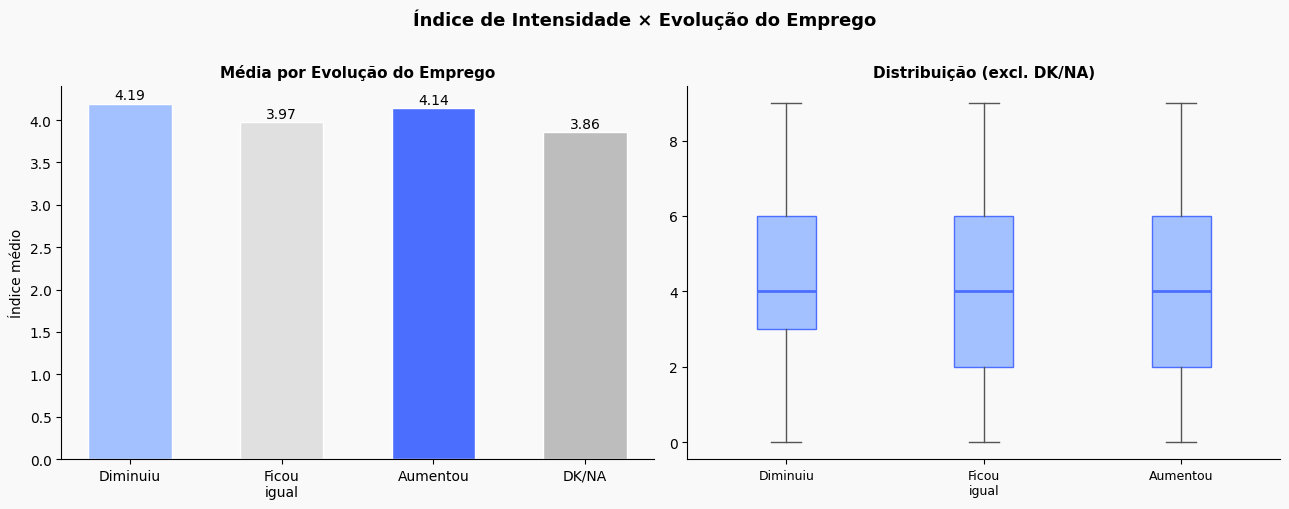

In [42]:
# VD × scr13a (evolução do nº de empregados nos últimos 3 anos)
# Códigos: 1=Aumentou, 2=Diminuiu, 3=Ficou igual, 4=DK/NA

scr13a_map = {
    1.0: 'Aumentou',
    2.0: 'Diminuiu',
    3.0: 'Ficou igual',
    4.0: 'DK/NA',
}
scr13a_order = [2.0, 3.0, 1.0, 4.0]
scr13a_short = ['Diminuiu', 'Ficou\nigual', 'Aumentou', 'DK/NA']

print("=== VD × EVOLUÇÃO DO EMPREGO (scr13a) ===")
print(df_key.groupby('scr13a')['intensity_index']
      .agg(['mean','median','std','count'])
      .reindex(scr13a_order).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

means_e = df_key.groupby('scr13a')['intensity_index'].mean().reindex(scr13a_order)
colors_e = [LIGHT_BLUE, '#E0E0E0', BLUE, '#BDBDBD']
axes[0].bar(scr13a_short, means_e.values, color=colors_e, edgecolor='white', width=0.55)
for i, val in enumerate(means_e.values):
    if not np.isnan(val):
        axes[0].text(i, val+0.05, f'{val:.2f}', ha='center', fontsize=10)
axes[0].set_ylabel('Índice médio', fontsize=10)
axes[0].set_title('Média por Evolução do Emprego', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

data_e = [df_key[df_key['scr13a']==s]['intensity_index'].dropna().values for s in scr13a_order[:3]]
axes[1].boxplot(data_e, patch_artist=True,
                boxprops=dict(facecolor=LIGHT_BLUE, color=BLUE),
                medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color='#555'), capprops=dict(color='#555'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.2, markersize=2))
axes[1].set_xticklabels(['Diminuiu', 'Ficou\nigual', 'Aumentou'], fontsize=9)
axes[1].set_title('Distribuição (excl. DK/NA)', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Índice de Intensidade × Evolução do Emprego', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 2.6.6 VD × Volume de Negócios (scr14)

=== VD × VOLUME DE NEGÓCIOS (scr14) ===
       mean  median   std  count
scr14                           
1.0    3.48     4.0  2.22    699
2.0    3.57     4.0  2.20    914
3.0    3.63     4.0  2.12   1010
4.0    3.76     4.0  2.09   1522
5.0    3.80     4.0  2.12   1397
6.0    4.01     4.0  2.21   2636
7.0    4.50     5.0  2.26   2197
8.0    4.95     5.0  2.24   1116
9.0    5.05     5.0  2.32    258
10.0   3.81     4.0  2.26   1810


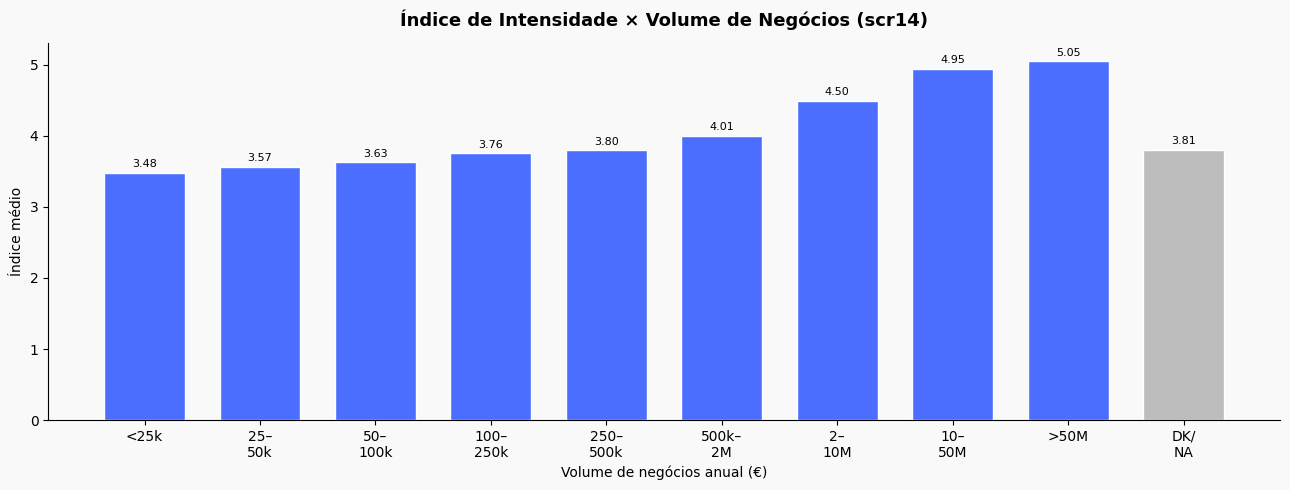

In [43]:
# VD × scr14 (volume de negócios anual — faixas)
# Códigos: 1=<25k€, 2=25-50k€, ..., 9=>50M€, 10=DK/NA

scr14_map_biv = {
    1.0: '<25k€', 2.0: '25–50k€', 3.0: '50–100k€',
    4.0: '100–250k€', 5.0: '250–500k€', 6.0: '500k–2M€',
    7.0: '2–10M€', 8.0: '10–50M€', 9.0: '>50M€', 10.0: 'DK/NA',
}
scr14_order = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
scr14_short = ['<25k','25–\n50k','50–\n100k','100–\n250k','250–\n500k',
               '500k–\n2M','2–\n10M','10–\n50M','>50M','DK/\nNA']

print("=== VD × VOLUME DE NEGÓCIOS (scr14) ===")
print(df_key.groupby('scr14')['intensity_index']
      .agg(['mean','median','std','count'])
      .reindex(scr14_order).round(2))

fig, ax = plt.subplots(figsize=(13, 5), facecolor=BG)

means_t = df_key.groupby('scr14')['intensity_index'].mean().reindex(scr14_order)
colors_t = [BLUE]*9 + ['#BDBDBD']
bars = ax.bar(scr14_short, means_t.values, color=colors_t, edgecolor='white', width=0.7)
for bar, val in zip(bars, means_t.values):
    if not np.isnan(val):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Índice médio', fontsize=10)
ax.set_xlabel('Volume de negócios anual (€)', fontsize=10)
ax.set_title('Índice de Intensidade × Volume de Negócios (scr14)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()


### 2.6.7 VD × Evolução do Volume de Negócios (Q3)

=== VD × Q3 — Volume de Negócios ===
     mean   std  count
q3                    
1.0  4.63  2.15    567
2.0  4.63  2.04   3898
5.0  3.80  1.88   2781
3.0  4.54  2.02   2617
4.0  4.31  2.11   1461
6.0  3.99  1.87   1284


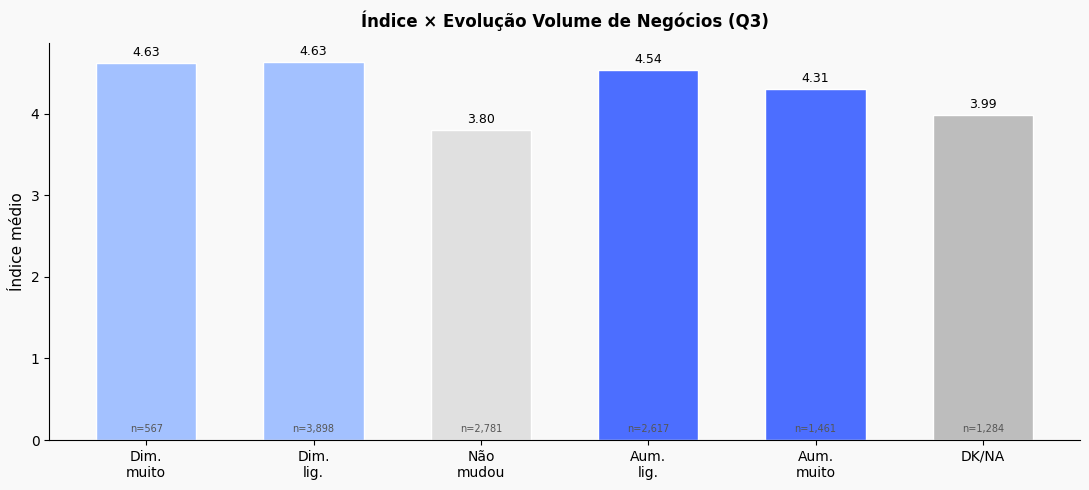

In [44]:
# VD × Q3 (evolução do volume de negócios)
# ⚠ ATENÇÃO: os códigos SPSS do Q3 NÃO são monotónicos!
#   1=Dim. muito, 2=Dim. lig., 3=Aum. lig., 4=Aum. muito, 5=Não mudou, 6=DK/NA
#   A ordem semântica correta é: 1 → 2 → 5 → 3 → 4  (diminuiu → estável → aumentou)
#   q3_code_order abaixo reordena para a escala lógica.

q3_code_order  = [1.0, 2.0, 5.0, 3.0, 4.0, 6.0]
q3_labels_biv  = ['Dim.\nmuito','Dim.\nlig.','Não\nmudou','Aum.\nlig.','Aum.\nmuito','DK/NA']

df_q3  = df_key[df_key['q3'].isin(q3_code_order)]
means  = df_q3.groupby('q3')['intensity_index'].mean().reindex(q3_code_order)
counts = df_q3.groupby('q3')['intensity_index'].count().reindex(q3_code_order)

print("=== VD × Q3 — Volume de Negócios ===")
print(df_q3.groupby('q3')['intensity_index']
      .agg(['mean','std','count']).reindex(q3_code_order).round(2))

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
colors_q3 = [LIGHT_BLUE, LIGHT_BLUE, '#E0E0E0', BLUE, BLUE, '#BDBDBD']
bars = ax.bar(q3_labels_biv, means.values, color=colors_q3, edgecolor='white', width=0.6)
for bar, val, n in zip(bars, means.values, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(bar.get_x()+bar.get_width()/2, 0.1,
            f'n={n:,}', ha='center', fontsize=7, color='#555')
ax.set_ylabel('Índice médio', fontsize=11)
ax.set_title('Índice × Evolução Volume de Negócios (Q3)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.6.8 VD × Investimento Ambiental (Q4)

=== VD × Q4 — Investimento Ambiental ===
     mean   std  count
q4                    
1.0  3.55  1.79   2682
2.0  4.21  1.88   2795
3.0  4.75  2.04   3785
4.0  4.92  2.16   1169
5.0  4.76  2.15    453
6.0  4.35  2.22    248
7.0  4.27  1.98   1476


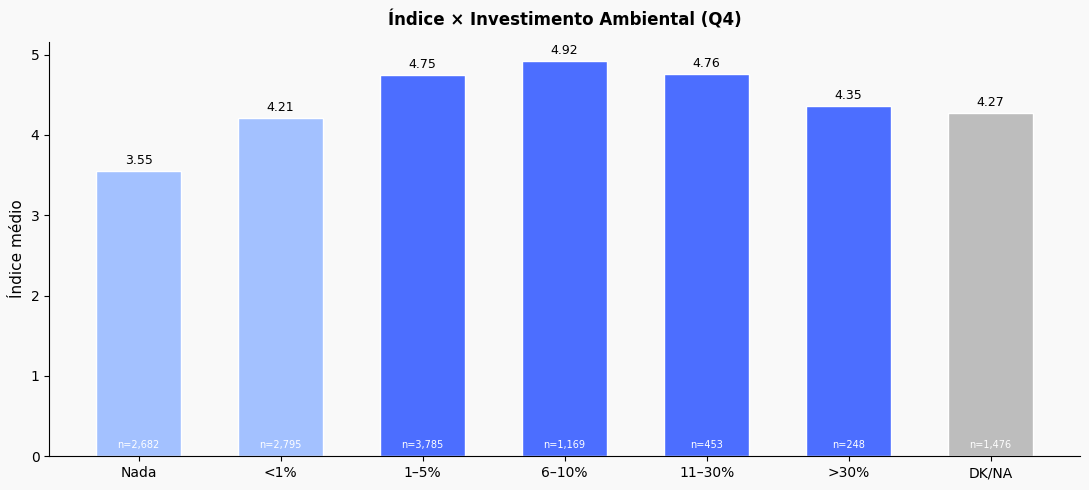

In [45]:
# VD × Q4 (% receita investida em ações ambientais)
# Códigos: 1=Nada, 2=<1%, 3=1-5%, 4=6-10%, 5=11-30%, 6=>30%, 7=DK/NA

q4_code_order  = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]
q4_labels_biv  = ['Nada','<1%','1–5%','6–10%','11–30%','>30%','DK/NA']

df_q4  = df_key[df_key['q4'].isin(q4_code_order)]
means  = df_q4.groupby('q4')['intensity_index'].mean().reindex(q4_code_order)
counts = df_q4.groupby('q4')['intensity_index'].count().reindex(q4_code_order)

print("=== VD × Q4 — Investimento Ambiental ===")
print(df_q4.groupby('q4')['intensity_index']
      .agg(['mean','std','count']).reindex(q4_code_order).round(2))

fig, ax = plt.subplots(figsize=(11, 5), facecolor=BG)
colors_q4 = [LIGHT_BLUE,LIGHT_BLUE,BLUE,BLUE,BLUE,BLUE,'#BDBDBD']
bars = ax.bar(q4_labels_biv, means.values, color=colors_q4, edgecolor='white', width=0.6)
for bar, val, n in zip(bars, means.values, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(bar.get_x()+bar.get_width()/2, 0.1,
            f'n={n:,}', ha='center', fontsize=7, color='white')
ax.set_ylabel('Índice médio', fontsize=11)
ax.set_title('Índice × Investimento Ambiental (Q4)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.6.9 VD × Barreiras à Eficiência (Q7)

=== VD × BARREIRAS Q7 ===
                          Barreira  Mencionou  Não mencionou  Diferença  N mencionou
 Procura insuficiente dos clientes       5.15           4.04       1.11         3261
                       ROI incerto       5.17           4.11       1.06         2606
               Falta de informação       5.04           4.03       1.02         3689
        Falta de expertise técnica       5.10           4.14       0.96         2467
            Falta de financiamento       4.92           4.02       0.90         4332
       Complexidade administrativa       4.98           4.14       0.84         2828
             Custo elevado inicial       4.97           4.14       0.83         2858
Ausência de regulação / incentivos       4.96           4.16       0.81         2626
          Falta de tempo / pessoal       4.94           4.16       0.77         2655
         Falta de apoio disponível       4.95           4.18       0.77         2366
      Falta de tecnologia adequada     

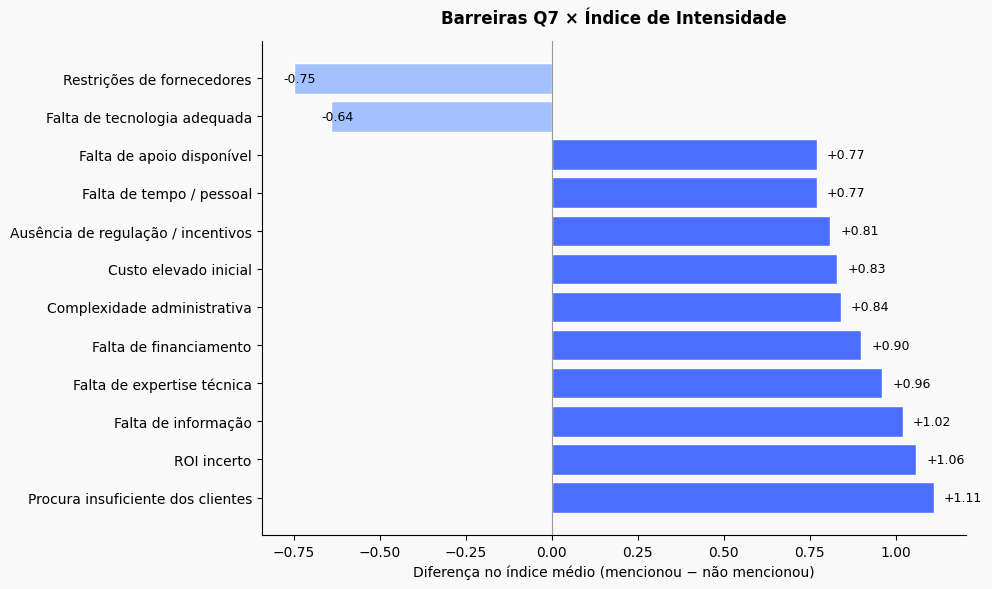

In [46]:
# VD × Barreiras Q7 — diferença no índice médio
# Q7.x: 0.0 = não mencionada, 1.0 = mencionada
# Empresas que mencionam barreiras tendem a ter índice mais alto ou mais baixo?

results = []
for col, label in q7_map.items():
    mentioned     = df_key[df_key[col] == 1.0]['intensity_index']
    not_mentioned = df_key[df_key[col] == 0.0]['intensity_index']
    results.append({
        'Barreira': label,
        'Mencionou': round(mentioned.mean(), 2),
        'Não mencionou': round(not_mentioned.mean(), 2),
        'Diferença': round(mentioned.mean() - not_mentioned.mean(), 2),
        'N mencionou': len(mentioned),
    })

q7_df = pd.DataFrame(results).sort_values('Diferença', ascending=False)
print("=== VD × BARREIRAS Q7 ===")
print(q7_df.to_string(index=False))

labels_q7 = q7_df['Barreira'].tolist()
diffs     = q7_df['Diferença'].tolist()

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
colors_q7 = [BLUE if d > 0 else LIGHT_BLUE for d in diffs]
ax.barh(labels_q7, diffs, color=colors_q7, edgecolor='white')
ax.axvline(0, color='#999', linewidth=0.8)
for i, val in enumerate(diffs):
    ax.text(val+(0.03 if val>=0 else -0.03), i,
            f'{val:+.2f}', va='center', fontsize=9)
ax.set_xlabel('Diferença no índice médio (mencionou − não mencionou)', fontsize=10)
ax.set_title('Barreiras Q7 × Índice de Intensidade',
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

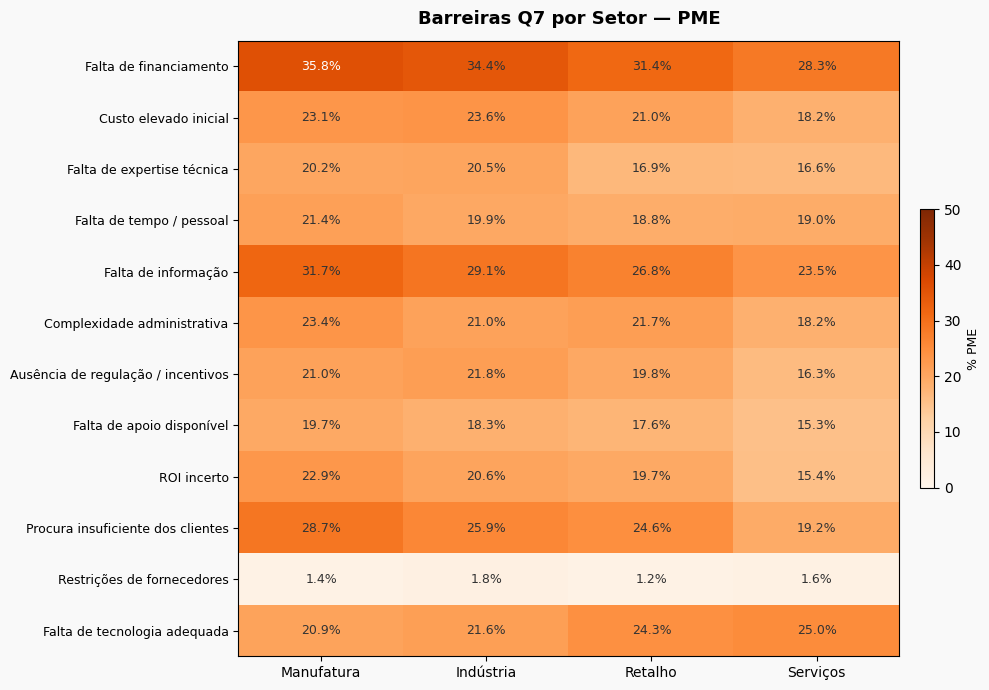

In [47]:
# Cruzamento barreiras × setor — quais setores sentem mais cada barreira
# Q7.x: 1.0 = mencionada

barrier_sector = {}
for col, label in q7_map.items():
    barrier_sector[label] = (
        df_key.groupby('nace_b')[col]
        .apply(lambda s: (s == 1.0).mean() * 100)
        .reindex(sector_order)
    )

bs_df = pd.DataFrame(barrier_sector).T
bs_df.columns = sector_short

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
im = ax.imshow(bs_df.values, cmap='Oranges', aspect='auto', vmin=0, vmax=50)
ax.set_xticks(range(4)); ax.set_xticklabels(sector_short, fontsize=10)
ax.set_yticks(range(len(bs_df.index))); ax.set_yticklabels(bs_df.index, fontsize=9)
for i in range(len(bs_df.index)):
    for j in range(4):
        val = bs_df.values[i,j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color='white' if val > 35 else '#333')
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.03).set_label('% PME', fontsize=9)
ax.set_title('Barreiras Q7 por Setor — PME', fontsize=13, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

### 2.6.10 Testes Estatísticos e Tamanho do Efeito

> Complementa as análises visuais das subsecções anteriores com testes formais de significância e medidas de efeito. Utilizam-se testes não paramétricos dado que o índice é uma contagem discreta (0–9).

In [48]:
# ── Testes estatísticos formais + tamanho do efeito ──────────────────────────
# Todos os testes são não-paramétricos (índice é contagem discreta 0–9)

from scipy.stats import kruskal, mannwhitneyu, spearmanr

results_tests = []

# ── 1. Kruskal-Wallis: Setor (nace_b) ───────────────────────────────────────
groups_sector = [df_key[df_key['nace_b']==s]['intensity_index'].dropna() for s in sector_order]
H_sec, p_sec = kruskal(*groups_sector)
N_sec = sum(len(g) for g in groups_sector)
k_sec = len(groups_sector)
eta2_sec = (H_sec - k_sec + 1) / (N_sec - k_sec)
results_tests.append({
    'Variável': 'Setor (nace_b)',
    'Teste': 'Kruskal-Wallis H',
    'Estatística': f'H = {H_sec:.1f}',
    'p-valor': f'{p_sec:.2e}' if p_sec < 0.001 else f'{p_sec:.4f}',
    'Efeito': f'η² = {eta2_sec:.4f}',
    'Interpretação': 'pequeno' if eta2_sec < 0.06 else ('médio' if eta2_sec < 0.14 else 'grande'),
})

# ── 2. Kruskal-Wallis: Dimensão (scr10) ─────────────────────────────────────
groups_size = [df_key[df_key['scr10']==s]['intensity_index'].dropna() for s in size_order]
H_sz, p_sz = kruskal(*groups_size)
N_sz = sum(len(g) for g in groups_size)
k_sz = len(groups_size)
eta2_sz = (H_sz - k_sz + 1) / (N_sz - k_sz)
results_tests.append({
    'Variável': 'Dimensão (scr10)',
    'Teste': 'Kruskal-Wallis H',
    'Estatística': f'H = {H_sz:.1f}',
    'p-valor': f'{p_sz:.2e}' if p_sz < 0.001 else f'{p_sz:.4f}',
    'Efeito': f'η² = {eta2_sz:.4f}',
    'Interpretação': 'pequeno' if eta2_sz < 0.06 else ('médio' if eta2_sz < 0.14 else 'grande'),
})

# ── 3. Kruskal-Wallis: Antiguidade (scr12, excl. DK/NA=5.0) ─────────────────
scr12_valid = [1.0, 2.0, 3.0, 4.0]
groups_age = [df_key[df_key['scr12']==s]['intensity_index'].dropna() for s in scr12_valid]
H_age, p_age = kruskal(*groups_age)
N_age = sum(len(g) for g in groups_age)
k_age = len(groups_age)
eta2_age = (H_age - k_age + 1) / (N_age - k_age)
results_tests.append({
    'Variável': 'Antiguidade (scr12)',
    'Teste': 'Kruskal-Wallis H',
    'Estatística': f'H = {H_age:.1f}',
    'p-valor': f'{p_age:.2e}' if p_age < 0.001 else f'{p_age:.4f}',
    'Efeito': f'η² = {eta2_age:.4f}',
    'Interpretação': 'pequeno' if eta2_age < 0.06 else ('médio' if eta2_age < 0.14 else 'grande'),
})

# ── 4. Kruskal-Wallis: Evolução emprego (scr13a, excl. DK/NA=4.0) ───────────
scr13a_valid = [1.0, 2.0, 3.0]
groups_emp = [df_key[df_key['scr13a']==s]['intensity_index'].dropna() for s in scr13a_valid]
H_emp, p_emp = kruskal(*groups_emp)
N_emp = sum(len(g) for g in groups_emp)
k_emp = len(groups_emp)
eta2_emp = (H_emp - k_emp + 1) / (N_emp - k_emp)
results_tests.append({
    'Variável': 'Evol. emprego (scr13a)',
    'Teste': 'Kruskal-Wallis H',
    'Estatística': f'H = {H_emp:.1f}',
    'p-valor': f'{p_emp:.2e}' if p_emp < 0.001 else f'{p_emp:.4f}',
    'Efeito': f'η² = {eta2_emp:.4f}',
    'Interpretação': 'pequeno' if eta2_emp < 0.06 else ('médio' if eta2_emp < 0.14 else 'grande'),
})

# ── 5. Spearman: Q3 (ordinal, excluindo DK/NA código 6.0) ────────────────────
q3_ordinal_map = {1.0: 1, 2.0: 2, 5.0: 3, 3.0: 4, 4.0: 5}
df_q3_test = df_key[df_key['q3'].isin([1.0,2.0,3.0,4.0,5.0])].copy()
df_q3_test['q3_ord'] = df_q3_test['q3'].map(q3_ordinal_map)
rho_q3, p_q3 = spearmanr(df_q3_test['q3_ord'], df_q3_test['intensity_index'])
results_tests.append({
    'Variável': 'Q3 — Vol. negócios (ordinal)',
    'Teste': 'Spearman ρ',
    'Estatística': f'ρ = {rho_q3:.3f}',
    'p-valor': f'{p_q3:.2e}' if p_q3 < 0.001 else f'{p_q3:.4f}',
    'Efeito': f'|ρ| = {abs(rho_q3):.3f}',
    'Interpretação': 'fraco' if abs(rho_q3) < 0.3 else ('moderado' if abs(rho_q3) < 0.5 else 'forte'),
})

# ── 6. Spearman: Q4 (ordinal, excluindo DK/NA código 7.0) ────────────────────
df_q4_test = df_key[df_key['q4'].isin([1.0,2.0,3.0,4.0,5.0,6.0])].copy()
rho_q4, p_q4 = spearmanr(df_q4_test['q4'], df_q4_test['intensity_index'])
results_tests.append({
    'Variável': 'Q4 — Invest. ambiental (ordinal)',
    'Teste': 'Spearman ρ',
    'Estatística': f'ρ = {rho_q4:.3f}',
    'p-valor': f'{p_q4:.2e}' if p_q4 < 0.001 else f'{p_q4:.4f}',
    'Efeito': f'|ρ| = {abs(rho_q4):.3f}',
    'Interpretação': 'fraco' if abs(rho_q4) < 0.3 else ('moderado' if abs(rho_q4) < 0.5 else 'forte'),
})

# ── 7. Spearman: scr14 (ordinal, excluindo DK/NA código 10.0) ────────────────
df_s14_test = df_key[df_key['scr14'].isin([1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0])].copy()
rho_s14, p_s14 = spearmanr(df_s14_test['scr14'], df_s14_test['intensity_index'])
results_tests.append({
    'Variável': 'Vol. negócios (scr14, ordinal)',
    'Teste': 'Spearman ρ',
    'Estatística': f'ρ = {rho_s14:.3f}',
    'p-valor': f'{p_s14:.2e}' if p_s14 < 0.001 else f'{p_s14:.4f}',
    'Efeito': f'|ρ| = {abs(rho_s14):.3f}',
    'Interpretação': 'fraco' if abs(rho_s14) < 0.3 else ('moderado' if abs(rho_s14) < 0.5 else 'forte'),
})

# ── Tabela resumo ────────────────────────────────────────────────────────────
print("=== TESTES BIVARIADOS — VD × VARIÁVEIS INDEPENDENTES ===\n")
print(pd.DataFrame(results_tests).to_string(index=False))

# ── 8. Mann-Whitney U: cada barreira Q7 ─────────────────────────────────────
print("\n\n=== MANN-WHITNEY U — BARREIRAS Q7 × ÍNDICE ===")
print(f"{'Barreira':<35} {'U':>12} {'p-valor':>12} {'r (rank-bis.)':>14} {'Efeito':>10}")
print(f"{'─'*85}")

for col, label in q7_map.items():
    g1 = df_key[df_key[col] == 1.0]['intensity_index'].dropna()
    g0 = df_key[df_key[col] == 0.0]['intensity_index'].dropna()
    if len(g1) > 0 and len(g0) > 0:
        U, p = mannwhitneyu(g1, g0, alternative='two-sided')
        n1, n2 = len(g1), len(g0)
        r_rb = 1 - (2*U) / (n1 * n2)
        eff = 'pequeno' if abs(r_rb) < 0.3 else ('médio' if abs(r_rb) < 0.5 else 'grande')
        p_str = f'{p:.2e}' if p < 0.001 else f'{p:.4f}'
        print(f"{label:<35} {U:>12,.0f} {p_str:>12} {r_rb:>+14.3f} {eff:>10}")

print("\nNotas:")
print("  η² < 0.06 = pequeno, 0.06–0.14 = médio, > 0.14 = grande (Cohen 1988)")
print("  |ρ| < 0.3 = fraco, 0.3–0.5 = moderado, > 0.5 = forte")
print("  |r| rank-biserial: mesmos limiares que ρ")


=== TESTES BIVARIADOS — VD × VARIÁVEIS INDEPENDENTES ===

                        Variável            Teste Estatística   p-valor      Efeito Interpretação
                  Setor (nace_b) Kruskal-Wallis H   H = 196.0  3.06e-42 η² = 0.0142       pequeno
                Dimensão (scr10) Kruskal-Wallis H   H = 273.4  4.31e-60 η² = 0.0200       pequeno
             Antiguidade (scr12) Kruskal-Wallis H    H = 29.4  1.87e-06 η² = 0.0020       pequeno
          Evol. emprego (scr13a) Kruskal-Wallis H    H = 17.5  1.59e-04 η² = 0.0015       pequeno
    Q3 — Vol. negócios (ordinal)       Spearman ρ  ρ = -0.047  4.29e-07 |ρ| = 0.047         fraco
Q4 — Invest. ambiental (ordinal)       Spearman ρ   ρ = 0.223 9.38e-126 |ρ| = 0.223         fraco
  Vol. negócios (scr14, ordinal)       Spearman ρ   ρ = 0.191  1.95e-97 |ρ| = 0.191         fraco


=== MANN-WHITNEY U — BARREIRAS Q7 × ÍNDICE ===
Barreira                                       U      p-valor  r (rank-bis.)     Efeito
─────────────────────

## 2.7 Análise Descritiva das Variáveis Independentes

### 2.7.1 Q3 e Q4

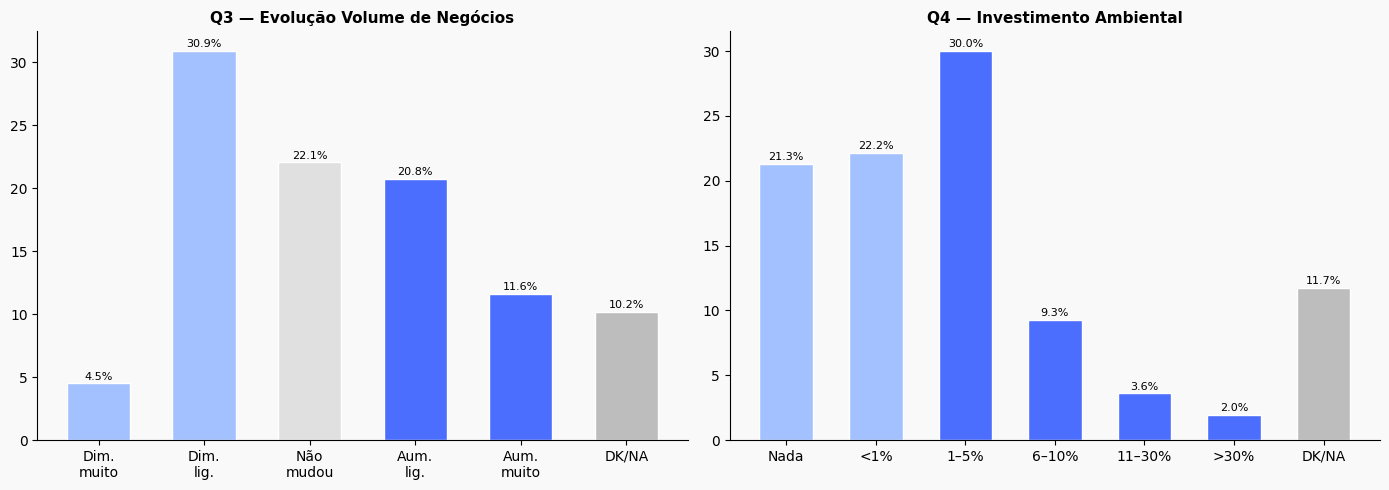

In [49]:
# Distribuição de Q3 e Q4 — incluindo DK/NA como categoria visível
# Q3 códigos: 1=Dim. muito, 2=Dim. lig., 5=Não mudou, 3=Aum. lig., 4=Aum. muito, 6=DK/NA
# Q4 códigos: 1=Nada, 2=<1%, 3=1-5%, 4=6-10%, 5=11-30%, 6=>30%, 7=DK/NA

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

q3c = df_key['q3'].value_counts(normalize=True).reindex(q3_code_order, fill_value=0)*100
axes[0].bar(q3_labels_biv, q3c.values,
            color=[LIGHT_BLUE,LIGHT_BLUE,'#E0E0E0',BLUE,BLUE,'#BDBDBD'],
            edgecolor='white', width=0.6)
for bar, val in zip(axes[0].patches, q3c.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=8)
axes[0].set_title('Q3 — Evolução Volume de Negócios', fontsize=11, fontweight='bold')
axes[0].set_facecolor(BG); axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

q4c = df_key['q4'].value_counts(normalize=True).reindex(q4_code_order, fill_value=0)*100
axes[1].bar(q4_labels_biv, q4c.values,
            color=[LIGHT_BLUE,LIGHT_BLUE,BLUE,BLUE,BLUE,BLUE,'#BDBDBD'],
            edgecolor='white', width=0.6)
for bar, val in zip(axes[1].patches, q4c.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=8)
axes[1].set_title('Q4 — Investimento Ambiental', fontsize=11, fontweight='bold')
axes[1].set_facecolor(BG); axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

### 2.7.2 Barreiras Q7

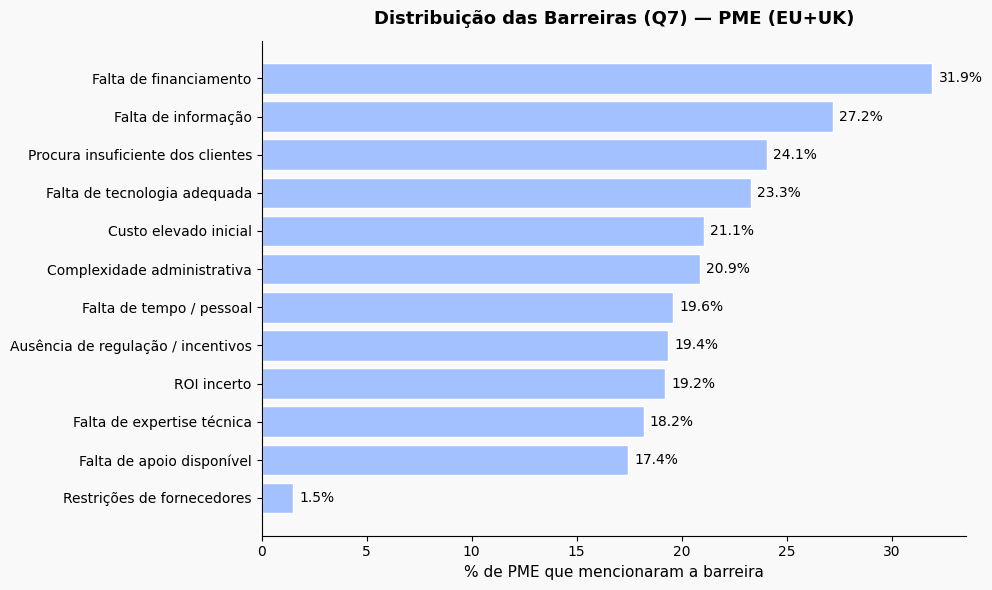

In [50]:
# Distribuição das barreiras Q7 — taxa de menção geral
# Q7.x: 1.0 = mencionada

eu_q7 = {
    label: (df_key[col] == 1.0).mean() * 100
    for col, label in q7_map.items()
}
sorted_q7 = sorted(eu_q7.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
bars = ax.barh([i[0] for i in sorted_q7], [i[1] for i in sorted_q7],
               color=LIGHT_BLUE, edgecolor='white')
for bar, val in zip(bars, [i[1] for i in sorted_q7]):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% de PME que mencionaram a barreira', fontsize=11)
ax.set_title('Distribuição das Barreiras (Q7) — PME (EU+UK)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 2.7.3 Apoios à eficiência Q8 — apenas descritiva

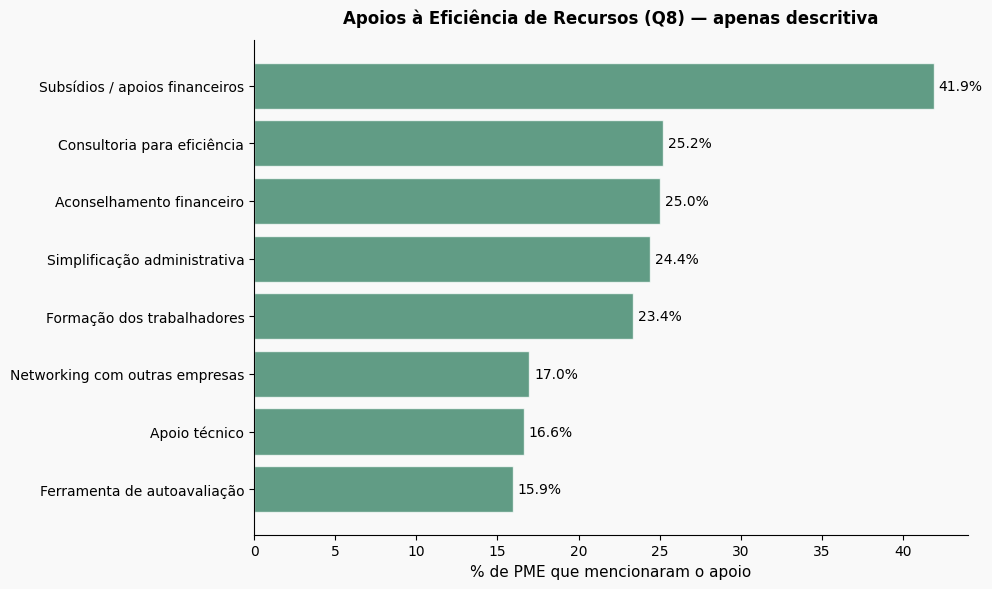

In [51]:
# Apoios à eficiência (Q8) — apenas para análise descritiva
# Estas variáveis NÃO entram no modelo por questões de causalidade inversa
# Q8.x: 0.0 = não mencionado, 1.0 = mencionado

q8_map = {
    'q8.1':  'Ferramenta de autoavaliação',
    'q8.2':  'Consultoria para eficiência',
    'q8.3':  'Subsídios / apoios financeiros',
    'q8.4':  'Aconselhamento financeiro',
    'q8.5':  'Formação dos trabalhadores',
    'q8.6':  'Apoio técnico',
    'q8.7':  'Simplificação administrativa',
    'q8.8':  'Networking com outras empresas',
}

eu_q8 = {
    label: (df[col] == 1.0).mean() * 100
    for col, label in q8_map.items()
    if col in df.columns
}
sorted_q8 = sorted(eu_q8.items(), key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
bars = ax.barh([i[0] for i in sorted_q8], [i[1] for i in sorted_q8],
               color=GREEN, alpha=0.75, edgecolor='white')
for bar, val in zip(bars, [i[1] for i in sorted_q8]):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('% de PME que mencionaram o apoio', fontsize=11)
ax.set_title('Apoios à Eficiência de Recursos (Q8) — apenas descritiva',
             fontsize=12, fontweight='bold', pad=12)
ax.set_facecolor(BG); fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2.8 Análise de Colinearidade

> A colinearidade é analisada aqui para informar as decisões de construção do índice e do modelo.

### 2.8.1 Correlação entre práticas Q1 — valida construção do índice

=== MATRIZ DE CORRELAÇÃO (Phi) — Práticas Q1 ===
                          Poupar água  Poupar energia  Energia renovável  \
Poupar água                     1.000           0.333              0.095   
Poupar energia                  0.333           1.000              0.168   
Energia renovável               0.095           0.168              1.000   
Poupar materiais                0.298           0.303              0.115   
Fornecedores mais verdes        0.200           0.189              0.154   
Minimizar resíduos              0.303           0.306              0.143   
Vender resíduos                 0.113           0.138              0.108   
Reciclar internamente           0.135           0.117              0.092   
Eco-design                      0.138           0.158              0.109   

                          Poupar materiais  Fornecedores mais verdes  \
Poupar água                          0.298                     0.200   
Poupar energia                       0.303    

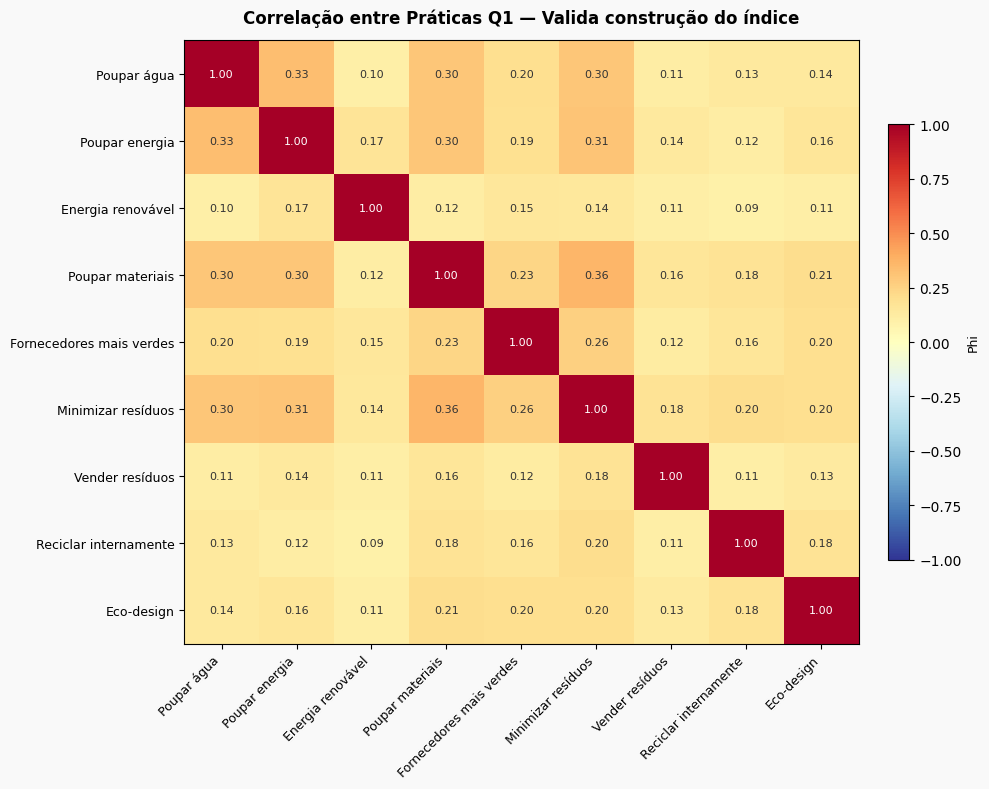

In [52]:
# Correlação entre as práticas Q1 — valida a construção do índice
# Para variáveis binárias, o coeficiente de Pearson equivale ao coeficiente Phi

bin_cols_q1 = [c+'_bin' for c in q1_map.keys()]
labels_q1   = list(q1_map.values())
corr_m      = df_key[bin_cols_q1].rename(
    columns=dict(zip(bin_cols_q1, labels_q1))
).corr()

print("=== MATRIZ DE CORRELAÇÃO (Phi) — Práticas Q1 ===")
print(corr_m.round(3))

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
im = ax.imshow(corr_m.values, cmap='RdYlBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(9)); ax.set_xticklabels(labels_q1, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(9)); ax.set_yticklabels(labels_q1, fontsize=9)
for i in range(9):
    for j in range(9):
        val = corr_m.values[i,j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(val) > 0.6 else '#333')
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04).set_label('Phi', fontsize=9)
ax.set_title('Correlação entre Práticas Q1 — Valida construção do índice',
             fontsize=12, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)
plt.tight_layout(); plt.show()

### 2.8.2 VIF — Práticas Q1

In [53]:
# VIF das práticas Q1 — complementa a análise de correlação
# VIF < 5: sem colinearidade problemática → o índice é válido

from statsmodels.stats.outliers_influence import variance_inflation_factor

bin_cols_q1 = [c+'_bin' for c in q1_map.keys()]
labels_q1   = list(q1_map.values())
df_vif      = df_key[bin_cols_q1].dropna()

vif_data = pd.DataFrame({
    'Variável': labels_q1,
    'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(9)]
}).sort_values('VIF', ascending=False)

print("=== VIF — Práticas Q1 ===")
print(vif_data.round(3).to_string(index=False))
print(f"\nVIF máximo: {vif_data['VIF'].max():.3f}")
print(f"Todos < 5:  {(vif_data['VIF'] < 5).all()} → índice válido")

=== VIF — Práticas Q1 ===
                Variável   VIF
      Minimizar resíduos 3.469
          Poupar energia 3.182
        Poupar materiais 2.920
             Poupar água 2.327
   Reciclar internamente 1.950
Fornecedores mais verdes 1.785
              Eco-design 1.539
         Vender resíduos 1.494
       Energia renovável 1.434

VIF máximo: 3.469
Todos < 5:  True → índice válido


---
# Secção 3 — Tratamento e Construção das Variáveis

> As decisões de tratamento são fundamentadas pela AED da Secção 2. Cada transformação é aplicada no `df_model`, deixando o `df_key` intacto para referência.
>
> **Decisão-chave:** As 951 empresas com Q1=0 (lógica de salto) são **mantidas** no dataset. Eliminá-las enviesaria o modelo para cima e perderia informação válida sobre não-adoção.

## 3.1 Criação do df_model e Tratamento de NAs

In [54]:
# ── Criação do df_model ─────────────────────────────────────────────────────
# Parte de df_key (todas as empresas) — NÃO faz listwise deletion

df_model = df_key.copy()
n_total = len(df_model)

# ── Lógica de salto (Q1=0): Q3/Q4/Q7 não foram perguntados ──────────────────
mask_skip = df_model['q3'].isnull()
n_skip = mask_skip.sum()

# Q7: preencher NaN com 0 (não enfrentaram barreiras — não tentaram)
q7_cols = list(q7_map.keys())
for col in q7_cols:
    df_model.loc[mask_skip, col] = 0.0

# Q3: preencher NaN com 5.0 (= 'Não mudou' — categoria de referência)
# → estas empresas ficam no grupo de referência e não influenciam coeficientes Q3
df_model.loc[mask_skip, 'q3'] = 5.0

# Q4: preencher NaN com 1.0 (= 'Nada' — categoria de referência)
# → mesma lógica: ficam no grupo de referência
df_model.loc[mask_skip, 'q4'] = 1.0

# ── DK/NA específicos → mantidos como categorias (dummies em 3.5) ────────────
# scr14: 10.0 = DK/NA → dummy indicadora
df_model['turnover_unknown'] = (df_model['scr14'] == 10.0).astype(int)
# scr12: 5.0 = DK/NA, scr13a: 4.0 = DK/NA, Q3: 6.0, Q4: 7.0 → mantidos

# ── Adicionar scr11b do df completo ─────────────────────────────────────────
df_model['scr11b'] = df.loc[df_model.index, 'scr11b']

print(f"df_model: {n_total:,} empresas × {df_model.shape[1]} colunas")
print(f"  Empresas mantidas: {n_total:,} (100% — sem listwise deletion)")
print(f"  Lógica de salto (Q1=0): {n_skip:,} ({n_skip/n_total*100:.1f}%)")
print(f"    → Q7 = 0, Q3 = 5.0 (ref), Q4 = 1.0 (ref)")
print(f"\n  DK/NA mantidos como categorias:")
print(f"    scr14 = 10.0:  {(df_model['scr14']==10.0).sum():,} → turnover_unknown=1")
print(f"    scr12 = 5.0:   {(df_model['scr12']==5.0).sum():,}")
print(f"    scr13a = 4.0:  {(df_model['scr13a']==4.0).sum():,}")
print(f"    Q3 = 6.0:      {(df_model['q3']==6.0).sum():,}")
print(f"    Q4 = 7.0:      {(df_model['q4']==7.0).sum():,}")

# Verificar NAs restantes
na_check = df_model.isnull().sum()
na_check = na_check[na_check > 0]
print(f"\nNAs restantes no df_model: {len(na_check)} variáveis")
if len(na_check) > 0:
    for col, n in na_check.items():
        print(f"    {col}: {n:,} ({n/n_total*100:.1f}%)")


df_model: 13,559 empresas × 42 colunas
  Empresas mantidas: 13,559 (100% — sem listwise deletion)
  Lógica de salto (Q1=0): 951 (7.0%)
    → Q7 = 0, Q3 = 5.0 (ref), Q4 = 1.0 (ref)

  DK/NA mantidos como categorias:
    scr14 = 10.0:  1,810 → turnover_unknown=1
    scr12 = 5.0:   70
    scr13a = 4.0:  2,751
    Q3 = 6.0:      1,284
    Q4 = 7.0:      1,476

NAs restantes no df_model: 2 variáveis
    scr13a: 627 (4.6%)
    scr11b: 135 (1.0%)


## 3.2 Tratamento de Outliers

In [55]:
# Tratamento de outliers — as decisões foram fundamentadas na Secção 2.3
#
# scr12a (ano de fundação): EXCLUÍDA — valores impossíveis (< 1900)
#   → Substituída por scr12 (categórica, já no df_model)
#
# scr10a (nº exato de FTE): NÃO INCLUÍDA
#   → Usamos scr10 categórica (micro / pequena / média)
#
# intensity_index: SEM outliers (escala construída 0–9)

print("=== TRATAMENTO DE OUTLIERS ===")
print("scr12a:          EXCLUÍDA (anos impossíveis) → usar scr12 categórica")
print("scr10a:          NÃO INCLUÍDA → usar scr10 categórica")
print("intensity_index: SEM outliers (escala 0–9 por construção)")
print("\n→ Nenhuma transformação necessária neste passo.")


=== TRATAMENTO DE OUTLIERS ===
scr12a:          EXCLUÍDA (anos impossíveis) → usar scr12 categórica
scr10a:          NÃO INCLUÍDA → usar scr10 categórica
intensity_index: SEM outliers (escala 0–9 por construção)

→ Nenhuma transformação necessária neste passo.


## 3.3 Verificação do Índice de Intensidade

> As colunas `q1.x_bin` e `intensity_index` foram construídas na Secção 2.4 e herdadas pelo `df_model`. Aqui verifica-se a sua integridade.

In [56]:
# Verificação do índice de intensidade (construído na Secção 2)
q1_cols = list(q1_map.keys())
bin_cols = [c+'_bin' for c in q1_cols]

# Verificar integridade: soma dos binários == intensity_index
check = (df_model[bin_cols].sum(axis=1) == df_model['intensity_index']).all()

print("=== ÍNDICE DE INTENSIDADE — df_model ===")
print(f"Colunas binárias: {len(bin_cols)}")
print(f"Verificação soma == índice: {'✓ OK' if check else '✗ FALHOU'}")
print(f"\nDistribuição:")
print(df_model['intensity_index'].value_counts().sort_index())
print(f"\nMédia:   {df_model['intensity_index'].mean():.2f}")
print(f"Mediana: {df_model['intensity_index'].median():.0f}")
print(f"Std:     {df_model['intensity_index'].std():.2f}")


=== ÍNDICE DE INTENSIDADE — df_model ===
Colunas binárias: 9
Verificação soma == índice: ✓ OK

Distribuição:
intensity_index
0     951
1    1183
2    1449
3    1963
4    2234
5    2094
6    1660
7    1202
8     613
9     210
Name: count, dtype: int64

Média:   4.02
Mediana: 4
Std:     2.24


## 3.4 Construção de Variáveis Derivadas

### 3.4.1 Barreiras Q7 — conversão para int + no_barriers

In [57]:
# Q7: converter de float (0.0/1.0) para int (0/1)
# Skip-logic já preenchido com 0 em 3.1

q7_cols = list(q7_map.keys())

# Verificar NaN residuais em Q7
q7_na = df_model[q7_cols].isnull().sum().sum()
if q7_na > 0:
    print(f"⚠ {q7_na} NaN residuais em Q7 — preencher com 0")
    df_model[q7_cols] = df_model[q7_cols].fillna(0)

for col in q7_cols:
    df_model[col] = df_model[col].astype(int)

# no_barriers: 1 se nenhuma barreira mencionada
df_model['no_barriers'] = (df_model[q7_cols].sum(axis=1) == 0).astype(int)

print("=== BARREIRAS Q7 ===")
print(f"Colunas convertidas para int: {len(q7_cols)}")
print(f"\nno_barriers = 1 (nenhuma barreira): {df_model['no_barriers'].sum():,}")
print(f"no_barriers = 0 (pelo menos uma):    {(df_model['no_barriers']==0).sum():,}")
n_skip_nb = df_model.loc[mask_skip, 'no_barriers'].sum()
print(f"  └ das quais, lógica de salto (Q1=0): {n_skip_nb:,}")


=== BARREIRAS Q7 ===
Colunas convertidas para int: 12

no_barriers = 1 (nenhuma barreira): 1,326
no_barriers = 0 (pelo menos uma):    12,233
  └ das quais, lógica de salto (Q1=0): 951


### 3.4.2 scr11b → hired_bin + fin_difficulty

> Desdobra a variável scr11b (que mistura dois conceitos) em duas variáveis separadas.

In [58]:
# scr11b → hired_bin + fin_difficulty
# Códigos: 1.0=Muito difícil, 2.0=Algo difícil, 3.0=Nada difícil, 4.0=Não recrutou
# NaN = DK/NA (apanhados pelo recoding geral do NB01)

# hired_bin: 1 se recrutou nos últimos 24 meses, 0 se não
df_model['hired_bin'] = df_model['scr11b'].map({
    1.0: 1, 2.0: 1, 3.0: 1,  # recrutou (independentemente da dificuldade)
    4.0: 0,                    # não recrutou
})

# fin_difficulty: ordinal 1–3 (só para quem recrutou)
# 1=Nada difícil, 2=Algo difícil, 3=Muito difícil
df_model['fin_difficulty'] = df_model['scr11b'].map({
    3.0: 1,  # nada difícil
    2.0: 2,  # algo difícil
    1.0: 3,  # muito difícil
    4.0: 0,  # não recrutou → 0 (absorvido por hired_bin)
})

# DK/NA em scr11b → preencher com 0 (conservative: assume não recrutou)
n_na_h = df_model['hired_bin'].isnull().sum()
if n_na_h > 0:
    print(f"scr11b DK/NA: {n_na_h:,} empresas → hired_bin=0, fin_difficulty=0")
df_model['hired_bin'] = df_model['hired_bin'].fillna(0).astype(int)
df_model['fin_difficulty'] = df_model['fin_difficulty'].fillna(0).astype(int)

print("\n=== scr11b → HIRED_BIN + FIN_DIFFICULTY ===")
print(f"\nhired_bin:")
print(df_model['hired_bin'].value_counts().sort_index())
print(f"\nfin_difficulty (0=não recrutou/DK, 1=nada difícil, 2=algo, 3=muito):")
print(df_model['fin_difficulty'].value_counts().sort_index())


scr11b DK/NA: 135 empresas → hired_bin=0, fin_difficulty=0

=== scr11b → HIRED_BIN + FIN_DIFFICULTY ===

hired_bin:
hired_bin
0     3204
1    10355
Name: count, dtype: int64

fin_difficulty (0=não recrutou/DK, 1=nada difícil, 2=algo, 3=muito):
fin_difficulty
0    3204
1    1819
2    3475
3    5061
Name: count, dtype: int64


### 3.4.3 Recodificação das variáveis restantes

In [59]:
# ── turnover_size: scr14 ordinal (1–9), 0 para DK/NA ───────────────────────
df_model['turnover_size'] = df_model['scr14'].copy()
df_model.loc[df_model['scr14'] == 10.0, 'turnover_size'] = 0
df_model['turnover_size'] = df_model['turnover_size'].astype(int)

# ── turnover_trend: Q3 → escala ordinal (corrige códigos não monotónicos) ───
# 1=Dim.muito, 2=Dim.lig., 3=Não mudou, 4=Aum.lig., 5=Aum.muito
# DK/NA (6.0) → NaN  |  Skip-logic (5.0) → 3 (neutro)
q3_ord_map = {1.0: 1, 2.0: 2, 5.0: 3, 3.0: 4, 4.0: 5, 6.0: np.nan}
df_model['turnover_trend'] = df_model['q3'].map(q3_ord_map)

# ── investment_code: Q4 → escala ordinal ────────────────────────────────────
# 0=Nada, 1=<1%, 2=1–5%, 3=6–10%, 4=11–30%, 5=>30%
# DK/NA (7.0) → NaN  |  Skip-logic (1.0) → 0
q4_ord_map = {1.0: 0, 2.0: 1, 3.0: 2, 4.0: 3, 5.0: 4, 6.0: 5, 7.0: np.nan}
df_model['investment_code'] = df_model['q4'].map(q4_ord_map)

print("=== RECODIFICAÇÃO DAS VARIÁVEIS ===\n")
print("turnover_size (scr14 ordinal 0–9, 0=DK/NA):")
print(df_model['turnover_size'].value_counts().sort_index())
print(f"\nturnover_unknown: {df_model['turnover_unknown'].sum():,} empresas")
print(f"\nturnover_trend (Q3 ordinal 1–5, NaN=DK/NA):")
print(df_model['turnover_trend'].value_counts(dropna=False).sort_index())
print(f"\ninvestment_code (Q4 ordinal 0–5, NaN=DK/NA):")
print(df_model['investment_code'].value_counts(dropna=False).sort_index())


=== RECODIFICAÇÃO DAS VARIÁVEIS ===

turnover_size (scr14 ordinal 0–9, 0=DK/NA):
turnover_size
0    1810
1     699
2     914
3    1010
4    1522
5    1397
6    2636
7    2197
8    1116
9     258
Name: count, dtype: int64

turnover_unknown: 1,810 empresas

turnover_trend (Q3 ordinal 1–5, NaN=DK/NA):
turnover_trend
1.0     567
2.0    3898
3.0    3732
4.0    2617
5.0    1461
NaN    1284
Name: count, dtype: int64

investment_code (Q4 ordinal 0–5, NaN=DK/NA):
investment_code
0.0    3633
1.0    2795
2.0    3785
3.0    1169
4.0     453
5.0     248
NaN    1476
Name: count, dtype: int64


In [60]:
# ── Impacto dos NaN nos preditores ordinais ─────────────────────────────────
# turnover_trend e investment_code têm NaN (DK/NA em Q3/Q4).
# Se usados como preditores ordinais no modelo → essas linhas são excluídas.
# As dummies (d_q3_dkna, d_q4_dkna) capturam estes casos sem perda de observações.

# Mostrar o nº de obs disponíveis em cada especificação possível
spec_complete = df_model.dropna(subset=['turnover_trend', 'investment_code'])
spec_q3_ord   = df_model.dropna(subset=['turnover_trend'])
spec_q4_ord   = df_model.dropna(subset=['investment_code'])
spec_dummies  = df_model.dropna(subset=['fin_difficulty'])  # apenas NaN de scr11b

print("=== OBSERVAÇÕES DISPONÍVEIS POR ESPECIFICAÇÃO DO MODELO ===\n")
print(f"Especificação                                N          Perda")
print(f"{'─'*55}")
print(f"Dummies Q3 + Dummies Q4  (recomendado)     {len(spec_dummies):>6,}      {n_total-len(spec_dummies):>5,}  ({(n_total-len(spec_dummies))/n_total*100:.1f}%)")
print(f"Ordinal Q3 + Dummies Q4                    {len(spec_q3_ord):>6,}      {n_total-len(spec_q3_ord):>5,}  ({(n_total-len(spec_q3_ord))/n_total*100:.1f}%)")
print(f"Dummies Q3 + Ordinal Q4                    {len(spec_q4_ord):>6,}      {n_total-len(spec_q4_ord):>5,}  ({(n_total-len(spec_q4_ord))/n_total*100:.1f}%)")
print(f"Ordinal Q3 + Ordinal Q4                    {len(spec_complete):>6,}      {n_total-len(spec_complete):>5,}  ({(n_total-len(spec_complete))/n_total*100:.1f}%)")
print(f"{'─'*55}")
print(f"\n→ Usar dummies para Q3/Q4 preserva {n_total-len(spec_dummies)} obs adicionais vs ordinal.")
print(f"  Os casos DK/NA ficam representados por d_q3_dkna e d_q4_dkna.")


=== OBSERVAÇÕES DISPONÍVEIS POR ESPECIFICAÇÃO DO MODELO ===

Especificação                                N          Perda
───────────────────────────────────────────────────────
Dummies Q3 + Dummies Q4  (recomendado)     13,559          0  (0.0%)
Ordinal Q3 + Dummies Q4                    12,275      1,284  (9.5%)
Dummies Q3 + Ordinal Q4                    12,083      1,476  (10.9%)
Ordinal Q3 + Ordinal Q4                    11,094      2,465  (18.2%)
───────────────────────────────────────────────────────

→ Usar dummies para Q3/Q4 preserva 0 obs adicionais vs ordinal.
  Os casos DK/NA ficam representados por d_q3_dkna e d_q4_dkna.


## 3.5 Criação de Variáveis Dummy

> Uma categoria de referência é omitida em cada grupo para evitar colinearidade perfeita. As categorias de referência foram escolhidas como o grupo mais frequente ou mais neutro.

In [61]:
# ── Setor (ref: Manufatura, code 1.0) ──────────────────────────────────────
df_model['d_industry'] = (df_model['nace_b'] == 2.0).astype(int)
df_model['d_retail']   = (df_model['nace_b'] == 3.0).astype(int)
df_model['d_services'] = (df_model['nace_b'] == 4.0).astype(int)

# ── Dimensão (ref: Micro, code 1.0) ────────────────────────────────────────
df_model['d_small']  = (df_model['scr10'] == 2.0).astype(int)
df_model['d_medium'] = (df_model['scr10'] == 3.0).astype(int)

# ── Antiguidade (ref: Antes de 2000, code 1.0) ─────────────────────────────
df_model['d_age_2001_10']  = (df_model['scr12'] == 2.0).astype(int)
df_model['d_age_2011_15']  = (df_model['scr12'] == 3.0).astype(int)
df_model['d_age_post2015'] = (df_model['scr12'] == 4.0).astype(int)
df_model['d_age_dkna']     = (df_model['scr12'] == 5.0).astype(int)

# ── Evolução emprego (ref: Ficou igual, code 3.0) ──────────────────────────
df_model['d_emp_increased'] = (df_model['scr13a'] == 1.0).astype(int)
df_model['d_emp_decreased'] = (df_model['scr13a'] == 2.0).astype(int)
# scr13a NaN (627 empresas, DK/NA por recoding geral) agrupados com código 4.0
df_model['d_emp_dkna']      = (df_model['scr13a'].isin([4.0]) | df_model['scr13a'].isnull()).astype(int)

# ── Q3 — Vol. negócios (ref: Não mudou, code 5.0) ─────────────────────────
# Nota: skip-logic enterprises têm q3=5.0 → ficam na referência (todos dummies=0)
df_model['d_q3_dec_lot'] = (df_model['q3'] == 1.0).astype(int)
df_model['d_q3_dec_lit'] = (df_model['q3'] == 2.0).astype(int)
df_model['d_q3_inc_lit'] = (df_model['q3'] == 3.0).astype(int)
df_model['d_q3_inc_lot'] = (df_model['q3'] == 4.0).astype(int)
df_model['d_q3_dkna']    = (df_model['q3'] == 6.0).astype(int)

# ── Q4 — Invest. ambiental (ref: Nada, code 1.0) ──────────────────────────
# Nota: skip-logic enterprises têm q4=1.0 → ficam na referência
df_model['d_q4_lt1']    = (df_model['q4'] == 2.0).astype(int)
df_model['d_q4_1_5']    = (df_model['q4'] == 3.0).astype(int)
df_model['d_q4_6_10']   = (df_model['q4'] == 4.0).astype(int)
df_model['d_q4_11_30']  = (df_model['q4'] == 5.0).astype(int)
df_model['d_q4_gt30']   = (df_model['q4'] == 6.0).astype(int)
df_model['d_q4_dkna']   = (df_model['q4'] == 7.0).astype(int)

# ── Resumo ──────────────────────────────────────────────────────────────────
dummy_groups = {
    'Setor (ref: Manufatura)': ['d_industry','d_retail','d_services'],
    'Dimensão (ref: Micro)': ['d_small','d_medium'],
    'Antiguidade (ref: Antes 2000)': ['d_age_2001_10','d_age_2011_15','d_age_post2015','d_age_dkna'],
    'Emprego (ref: Ficou igual)': ['d_emp_increased','d_emp_decreased','d_emp_dkna'],
    'Q3 (ref: Não mudou)': ['d_q3_dec_lot','d_q3_dec_lit','d_q3_inc_lit','d_q3_inc_lot','d_q3_dkna'],
    'Q4 (ref: Nada)': ['d_q4_lt1','d_q4_1_5','d_q4_6_10','d_q4_11_30','d_q4_gt30','d_q4_dkna'],
}

print("=== VARIÁVEIS DUMMY CRIADAS ===\n")
for group, cols in dummy_groups.items():
    ref_count = n_total - sum(df_model[c].sum() for c in cols)
    print(f"{group}  [ref: {ref_count:,}]")
    for c in cols:
        print(f"    {c:<22} = 1: {df_model[c].sum():>5,}")
    print()

d_cols = [c for c in df_model.columns if c.startswith('d_')]
print(f"Total de variáveis dummy: {len(d_cols)}")


=== VARIÁVEIS DUMMY CRIADAS ===

Setor (ref: Manufatura)  [ref: 2,736]
    d_industry             = 1: 2,671
    d_retail               = 1: 4,016
    d_services             = 1: 4,136

Dimensão (ref: Micro)  [ref: 5,941]
    d_small                = 1: 4,992
    d_medium               = 1: 2,626

Antiguidade (ref: Antes 2000)  [ref: 10,791]
    d_age_2001_10          = 1: 1,191
    d_age_2011_15          = 1: 1,229
    d_age_post2015         = 1:   278
    d_age_dkna             = 1:    70

Emprego (ref: Ficou igual)  [ref: 4,327]
    d_emp_increased        = 1: 3,582
    d_emp_decreased        = 1: 2,272
    d_emp_dkna             = 1: 3,378

Q3 (ref: Não mudou)  [ref: 3,732]
    d_q3_dec_lot           = 1:   567
    d_q3_dec_lit           = 1: 3,898
    d_q3_inc_lit           = 1: 2,617
    d_q3_inc_lot           = 1: 1,461
    d_q3_dkna              = 1: 1,284

Q4 (ref: Nada)  [ref: 3,633]
    d_q4_lt1               = 1: 2,795
    d_q4_1_5               = 1: 3,785
    d_q4_6_10    

In [62]:
# ── Verificação de variância quase-nula (near-zero variance) ───────────────
# Variáveis com < 2% de 1s podem causar instabilidade na estimação do modelo

binary_vars = (
    ['d_industry','d_retail','d_services','d_small','d_medium']
    + ['d_age_2001_10','d_age_2011_15','d_age_post2015','d_age_dkna']
    + ['d_emp_increased','d_emp_decreased','d_emp_dkna']
    + ['d_q3_dec_lot','d_q3_dec_lit','d_q3_inc_lit','d_q3_inc_lot','d_q3_dkna']
    + ['d_q4_lt1','d_q4_1_5','d_q4_6_10','d_q4_11_30','d_q4_gt30','d_q4_dkna']
    + ['hired_bin','turnover_unknown','no_barriers']
    + list(q7_map.keys())
)

nzv_threshold = 0.02  # < 2% → near-zero variance
print(f"=== NEAR-ZERO VARIANCE (threshold: < {nzv_threshold*100:.0f}% de 1s) ===\n")
print(f"{'Variável':<25} {'N=1':>7} {'%':>7}  Estado")
print(f"{'─'*50}")

nzv_flagged = []
for v in binary_vars:
    n1  = df_model[v].sum()
    pct = n1 / n_total
    flag = '⚠ NZV' if pct < nzv_threshold else ''
    if flag:
        nzv_flagged.append(v)
    if flag or pct < 0.05:  # mostrar também as baixas mas não críticas
        print(f"  {v:<23} {n1:>7,} {pct*100:>6.1f}%  {flag}")

print(f"\nVariáveis com NZV: {nzv_flagged}")
print(f"\n→ Recomendação:")
print(f"  d_age_dkna:  apenas {df_model['d_age_dkna'].sum()} obs — considerar fusão com d_age_post2015")
print(f"  q7.11:       {df_model['q7.11'].sum()} obs — manter mas não interpretar isoladamente")
print(f"  Será avaliado na modelação se causam problemas de convergência.")


=== NEAR-ZERO VARIANCE (threshold: < 2% de 1s) ===

Variável                      N=1       %  Estado
──────────────────────────────────────────────────
  d_age_post2015              278    2.1%  
  d_age_dkna                   70    0.5%  ⚠ NZV
  d_q3_dec_lot                567    4.2%  
  d_q4_11_30                  453    3.3%  
  d_q4_gt30                   248    1.8%  ⚠ NZV
  q7.11                       202    1.5%  ⚠ NZV

Variáveis com NZV: ['d_age_dkna', 'd_q4_gt30', 'q7.11']

→ Recomendação:
  d_age_dkna:  apenas 70 obs — considerar fusão com d_age_post2015
  q7.11:       202 obs — manter mas não interpretar isoladamente
  Será avaliado na modelação se causam problemas de convergência.


In [63]:
# ── Estandardização dos preditores contínuos/ordinais ───────────────────────
# Cria versões z-score (_z) para comparação de coeficientes no modelo
# Binárias e dummies NÃO são estandardizadas (já estão em escala 0/1)

continuous_vars = {
    'turnover_size':    'scr14 ordinal 0–9',
    'fin_difficulty':   'scr11b ordinal 0–3',
    'turnover_trend':   'Q3 ordinal 1–5 (NaN=DK/NA)',
    'investment_code':  'Q4 ordinal 0–5 (NaN=DK/NA)',
}

print("=== ESTANDARDIZAÇÃO (z-score) DOS PREDITORES CONTÍNUOS ===\n")
print(f"{'Variável':<20} {'Orig. μ':>9} {'Orig. σ':>9} {'z μ':>9} {'z σ':>9}")
print(f"{'─'*55}")

for v, desc in continuous_vars.items():
    col = df_model[v].dropna()
    mu, sigma = col.mean(), col.std()
    df_model[v+'_z'] = (df_model[v] - mu) / sigma
    z_col = df_model[v+'_z'].dropna()
    print(f"  {v:<20} {mu:>9.3f} {sigma:>9.3f} {z_col.mean():>9.3f} {z_col.std():>9.3f}")

print(f"\nColunas criadas: {[v+'_z' for v in continuous_vars]}")
print(f"\n→ No modelo usar _z para comparar tamanhos de efeito entre preditores.")
print(f"  As versões originais mantêm-se para interpretação substantiva.")


=== ESTANDARDIZAÇÃO (z-score) DOS PREDITORES CONTÍNUOS ===

Variável               Orig. μ   Orig. σ       z μ       z σ
───────────────────────────────────────────────────────
  turnover_size            4.504     2.612    -0.000     1.000
  fin_difficulty           1.767     1.182    -0.000     1.000
  turnover_trend           3.041     1.091     0.000     1.000
  investment_code          1.401     1.227    -0.000     1.000

Colunas criadas: ['turnover_size_z', 'fin_difficulty_z', 'turnover_trend_z', 'investment_code_z']

→ No modelo usar _z para comparar tamanhos de efeito entre preditores.
  As versões originais mantêm-se para interpretação substantiva.


## 3.6 Verificação de Colinearidade (VIF)

> VIF calculado para todas as variáveis independentes do modelo. Exclui-se `isocntry` (variável de nível 2 no modelo multinível), `w1_sme` (peso), e `no_barriers` (derivado linear de Q7).

In [64]:
# VIF para variáveis independentes do modelo
# Nota: hired_bin excluído — é redundante com fin_difficulty
#   (hired_bin=0 ↔ fin_difficulty=0, sempre — colinearidade estrutural)
#   No modelo usar apenas fin_difficulty (0=não recrutou, 1–3=dificuldade)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = (
    ['d_industry','d_retail','d_services']
    + ['d_small','d_medium']
    + ['d_age_2001_10','d_age_2011_15','d_age_post2015','d_age_dkna']
    + ['d_emp_increased','d_emp_decreased','d_emp_dkna']
    + ['d_q3_dec_lot','d_q3_dec_lit','d_q3_inc_lit','d_q3_inc_lot','d_q3_dkna']
    + ['d_q4_lt1','d_q4_1_5','d_q4_6_10','d_q4_11_30','d_q4_gt30','d_q4_dkna']
    + ['turnover_size','turnover_unknown']
    + ['fin_difficulty']  # hired_bin excluído (redundante)
    + list(q7_map.keys())
)

df_vif = df_model[vif_vars].dropna()
print(f"VIF calculado sobre {len(df_vif):,} observações ({len(df_vif)/n_total*100:.1f}%)")
print(f"Variáveis: {len(vif_vars)}\n")

vif_results = pd.DataFrame({
    'Variável': vif_vars,
    'VIF': [variance_inflation_factor(df_vif.values, i) for i in range(len(vif_vars))]
}).sort_values('VIF', ascending=False)

print(vif_results.round(2).to_string(index=False))

max_vif = vif_results['VIF'].max()
print(f"\nVIF máximo: {max_vif:.2f}")
if max_vif < 5:
    print("✓ Todos VIF < 5 — sem colinearidade problemática")
elif max_vif < 10:
    print("⚠ VIF entre 5 e 10 — colinearidade moderada, monitorizar no modelo")
else:
    high = vif_results[vif_results['VIF'] >= 10]['Variável'].tolist()
    print(f"✗ VIF ≥ 10 em: {high} — considerar remoção ou agrupamento")


VIF calculado sobre 13,559 observações (100.0%)
Variáveis: 38



        Variável  VIF
   turnover_size 6.98
  fin_difficulty 3.51
        d_q4_1_5 2.34
    d_q3_dec_lit 2.23
         d_small 2.15
            q7.1 2.14
        d_retail 2.11
      d_services 2.04
turnover_unknown 2.03
        d_q4_lt1 1.91
            q7.5 1.88
           q7.10 1.87
 d_emp_increased 1.85
    d_q3_inc_lit 1.83
        d_medium 1.77
            q7.2 1.73
      d_industry 1.72
           q7.12 1.71
      d_emp_dkna 1.69
            q7.9 1.66
            q7.6 1.61
            q7.4 1.58
            q7.3 1.56
 d_emp_decreased 1.52
       d_q4_dkna 1.52
            q7.7 1.49
    d_q3_inc_lot 1.49
            q7.8 1.46
       d_q4_6_10 1.43
       d_q3_dkna 1.38
    d_q3_dec_lot 1.19
      d_q4_11_30 1.17
   d_age_2011_15 1.13
   d_age_2001_10 1.12
       d_q4_gt30 1.09
           q7.11 1.04
  d_age_post2015 1.03
      d_age_dkna 1.01

VIF máximo: 6.98
⚠ VIF entre 5 e 10 — colinearidade moderada, monitorizar no modelo


In [65]:
# ── Tabela de estatísticas descritivas — df_model (pronta para relatório) ───

# Preditores contínuos
cont_vars = ['turnover_size','fin_difficulty','turnover_trend','investment_code']
print("=== ESTATÍSTICAS DESCRITIVAS — df_model ===\n")
print("── Variável dependente e preditores contínuos/ordinais ──")
print(f"{'Variável':<22} {'N':>7} {'NaN':>6} {'μ':>7} {'σ':>7} {'Min':>6} {'Max':>6}")
print(f"{'─'*65}")
for v in ['intensity_index'] + cont_vars:
    col = df_model[v]
    n_valid = col.notna().sum()
    n_na    = col.isna().sum()
    print(f"  {v:<22} {n_valid:>7,} {n_na:>6,} {col.mean():>7.2f} {col.std():>7.2f} "
          f"{col.min():>6.1f} {col.max():>6.1f}")

print(f"\n── Preditores binários e dummies (% = 1) ──")
bin_groups = {
    'Setor':       ['d_industry','d_retail','d_services'],
    'Dimensão':    ['d_small','d_medium'],
    'Antiguidade': ['d_age_2001_10','d_age_2011_15','d_age_post2015','d_age_dkna'],
    'Emprego':     ['d_emp_increased','d_emp_decreased','d_emp_dkna'],
    'Q3':          ['d_q3_dec_lot','d_q3_dec_lit','d_q3_inc_lit','d_q3_inc_lot','d_q3_dkna'],
    'Q4':          ['d_q4_lt1','d_q4_1_5','d_q4_6_10','d_q4_11_30','d_q4_gt30','d_q4_dkna'],
    'Financeiro':  ['hired_bin','turnover_unknown'],
    'Barreiras':   list(q7_map.keys()) + ['no_barriers'],
}

print(f"{'Grupo':<15} {'Variável':<22} {'N=1':>7} {'%':>7}")
print(f"{'─'*55}")
for group, cols in bin_groups.items():
    for i, c in enumerate(cols):
        g_label = group if i == 0 else ''
        n1  = df_model[c].sum()
        pct = n1 / n_total * 100
        print(f"  {g_label:<13} {c:<22} {n1:>7,} {pct:>6.1f}%")
    print()


=== ESTATÍSTICAS DESCRITIVAS — df_model ===

── Variável dependente e preditores contínuos/ordinais ──
Variável                     N    NaN       μ       σ    Min    Max
─────────────────────────────────────────────────────────────────
  intensity_index         13,559      0    4.02    2.24    0.0    9.0
  turnover_size           13,559      0    4.50    2.61    0.0    9.0
  fin_difficulty          13,559      0    1.77    1.18    0.0    3.0
  turnover_trend          12,275  1,284    3.04    1.09    1.0    5.0
  investment_code         12,083  1,476    1.40    1.23    0.0    5.0

── Preditores binários e dummies (% = 1) ──
Grupo           Variável                   N=1       %
───────────────────────────────────────────────────────
  Setor         d_industry               2,671   19.7%
                d_retail                 4,016   29.6%
                d_services               4,136   30.5%

  Dimensão      d_small                  4,992   36.8%
                d_medium            

## 3.7 Verificação Final e Resumo do df_model

In [66]:
# Verificação final do df_model

print("=" * 65)
print("  VERIFICAÇÃO FINAL — df_model")
print("=" * 65)
print(f"\nDimensão: {df_model.shape[0]:,} linhas × {df_model.shape[1]} colunas")

# NAs
na_final = df_model.isnull().sum()
na_final = na_final[na_final > 0]
print(f"\nVariáveis com NAs: {len(na_final)}")
if len(na_final) > 0:
    for col, n in na_final.items():
        print(f"    {col}: {n:,} ({n/len(df_model)*100:.1f}%)")

# Classificação das variáveis
print("\n── VARIÁVEL DEPENDENTE ─────────────────────────────────────────")
print(f"  intensity_index  (int, 0–9)  média={df_model['intensity_index'].mean():.2f}")

print("\n── VARIÁVEIS DE IDENTIFICAÇÃO ──────────────────────────────────")
print(f"  isocntry         ({df_model['isocntry'].nunique()} países)  → nível 2 do modelo multinível")
print(f"  w1_sme           peso de inquérito")

print("\n── VARIÁVEIS INDEPENDENTES (ordinais) ─────────────────────────")
for v, desc in [
    ('turnover_size', 'scr14 → ordinal 0–9'),
    ('turnover_trend', 'Q3 → ordinal 1–5'),
    ('investment_code', 'Q4 → ordinal 0–5'),
    ('fin_difficulty', 'scr11b → ordinal 0–3'),
]:
    na = df_model[v].isnull().sum()
    na_str = f'  NAs={na}' if na > 0 else ''
    print(f"  {v:<20}  ({desc}){na_str}")

print("\n── VARIÁVEIS INDEPENDENTES (binárias) ─────────────────────────")
for v in ['hired_bin', 'turnover_unknown', 'no_barriers'] + list(q7_map.keys()):
    print(f"  {v:<20}  1={df_model[v].sum():>5,}  0={(df_model[v]==0).sum():>5,}")

print("\n── VARIÁVEIS DUMMY ────────────────────────────────────────────")
d_cols = [c for c in df_model.columns if c.startswith('d_')]
for c in d_cols:
    print(f"  {c:<22}  1={df_model[c].sum():>5,}")

print(f"\nTotal de colunas no df_model: {df_model.shape[1]}")

print("\n── NOTA: VARIÁVEL DEPENDENTE ALTERNATIVA (Secção 3.8) ─────────")
print("  mca_score      será adicionado em 3.8 (score MCA, pesos por raridade)")
print("  mca_score_z    versão estandardizada do mca_score")

print("=" * 65)


  VERIFICAÇÃO FINAL — df_model

Dimensão: 13,559 linhas × 75 colunas

Variáveis com NAs: 6
    scr13a: 627 (4.6%)
    scr11b: 135 (1.0%)
    turnover_trend: 1,284 (9.5%)
    investment_code: 1,476 (10.9%)
    turnover_trend_z: 1,284 (9.5%)
    investment_code_z: 1,476 (10.9%)

── VARIÁVEL DEPENDENTE ─────────────────────────────────────────
  intensity_index  (int, 0–9)  média=4.02

── VARIÁVEIS DE IDENTIFICAÇÃO ──────────────────────────────────
  isocntry         (28 países)  → nível 2 do modelo multinível
  w1_sme           peso de inquérito

── VARIÁVEIS INDEPENDENTES (ordinais) ─────────────────────────
  turnover_size         (scr14 → ordinal 0–9)
  turnover_trend        (Q3 → ordinal 1–5)  NAs=1284
  investment_code       (Q4 → ordinal 0–5)  NAs=1476
  fin_difficulty        (scr11b → ordinal 0–3)

── VARIÁVEIS INDEPENDENTES (binárias) ─────────────────────────
  hired_bin             1=10,355  0=3,204
  turnover_unknown      1=1,810  0=11,749
  no_barriers           1=1,326  0=1

In [67]:
# Preview das primeiras linhas — subset de colunas para legibilidade
preview_cols = (
    ['isocntry', 'intensity_index']
    + ['d_industry','d_retail','d_services','d_small','d_medium']
    + ['hired_bin','turnover_size','turnover_unknown','no_barriers']
    + list(q7_map.keys())[:4]
)
df_model[preview_cols].head(10)


,isocntry,intensity_index,d_industry,d_retail,d_services,d_small,d_medium,hired_bin,turnover_size,turnover_unknown,no_barriers,q7.1,q7.2,q7.3,q7.4
108,AT,1,0,1,0,0,1,1,6,0,0,0,0,0,0
109,AT,5,0,0,0,0,0,1,8,0,0,0,0,0,1
110,AT,5,0,0,1,0,0,1,6,0,0,0,1,0,1
111,AT,4,0,0,1,0,1,1,8,0,0,0,0,1,0
112,AT,5,0,1,0,1,0,1,6,0,0,0,0,0,0
113,AT,2,1,0,0,1,0,1,0,1,0,0,0,0,0
114,AT,4,0,0,1,0,0,1,6,0,0,1,1,0,0
115,AT,3,1,0,0,1,0,1,3,0,0,0,0,0,1
116,AT,6,0,0,0,1,0,1,6,0,0,0,0,0,0
117,AT,4,0,1,0,1,0,1,1,0,0,0,0,0,0


## 3.8 MCA sobre as Práticas Q1 — Variável Dependente Alternativa

> O `intensity_index` atribui peso igual (0 ou 1) a cada prática Q1, ignorando que práticas raras como *eco-design* (~28%) discriminam muito mais entre empresas do que *poupar energia* (~66%). O MCA (Análise de Correspondências Múltiplas) produz automaticamente um `mca_score` contínuo onde cada prática recebe peso proporcional à sua raridade e às suas correlações com as demais.

| Variável dependente | Tipo | Modelo adequado |
|---|---|---|
| `intensity_index` | Contagem 0–9, pesos iguais | Poisson / Negative Binomial |
| `mca_score` | Score contínuo, pesos por raridade | OLS / GLM Gaussiano |

> **Referências:** Greenacre (2017) *Correspondence Analysis in Practice*; Le Roux & Rouanet (2010) *Multiple Correspondence Analysis*.

In [68]:
# ── 3.8.1  Preparação da matriz de input ─────────────────────────────────────
#
# O MCA recebe variáveis categóricas — não binárias numéricas.
# Convertemos as 9 binárias para strings "Adotou" / "Não adotou"
# para que o MCA trate cada estado como uma categoria distinta.

import prince
import matplotlib.patches as mpatches

bin_cols_model = [c + '_bin' for c in q1_map.keys()]
labels_q1      = list(q1_map.values())

# Matriz categórica: "Adotou" / "Não adotou"
df_q1_cat = df_model[bin_cols_model].copy()
df_q1_cat.columns = labels_q1
df_q1_cat = df_q1_cat.apply(lambda col: col.map({1: 'Adotou', 0: 'Não adotou'}))

print(f"Dimensão da matriz MCA: {df_q1_cat.shape[0]:,} empresas × {df_q1_cat.shape[1]} práticas")
print("\nDistribuição por prática:")
for col in df_q1_cat.columns:
    n_adotou = (df_q1_cat[col] == 'Adotou').sum()
    pct = n_adotou / len(df_q1_cat) * 100
    print(f"  {col:<35} {n_adotou:>5,}  ({pct:.1f}%)")

Dimensão da matriz MCA: 13,559 empresas × 9 práticas

Distribuição por prática:
  Poupar água                         6,452  (47.6%)
  Poupar energia                      8,844  (65.2%)
  Energia renovável                   3,617  (26.7%)
  Poupar materiais                    7,758  (57.2%)
  Fornecedores mais verdes            4,821  (35.6%)
  Minimizar resíduos                  8,814  (65.0%)
  Vender resíduos                     4,010  (29.6%)
  Reciclar internamente               6,438  (47.5%)
  Eco-design                          3,790  (28.0%)


In [69]:
# ── 3.8.2  Estimação do MCA ───────────────────────────────────────────────────
#
# n_components=9 — tantas dimensões quanto práticas (máximo possível)
# n_iter=10 → número de iterações do algoritmo (padrão robusto)

mca = prince.MCA(
    n_components=9,
    n_iter=10,
    random_state=42,
    engine='sklearn',
)
mca = mca.fit(df_q1_cat)

print("\n=== MCA — INÉRCIA EXPLICADA POR DIMENSÃO ===")
eigenvalues   = pd.Series(mca.eigenvalues_)
total_inertia = eigenvalues.sum()
explained_pct = (eigenvalues / total_inertia * 100).round(2)
cumulative    = explained_pct.cumsum().round(2)

inertia_df = pd.DataFrame({
    'Dimensão':          range(1, len(eigenvalues) + 1),
    'Eigenvalue':        eigenvalues.round(4).values,
    'Inércia (%)':       explained_pct.values,
    'Inércia acum. (%)': cumulative.values,
})
print(inertia_df.to_string(index=False))
print(f"\nInércia total: {total_inertia:.4f}")
print(f"\nNota: em MCA com 9 práticas binárias, a inércia máxima teórica")
print(f"é (9-1)/9 ≈ 0.889. Valores menores são normais.")


=== MCA — INÉRCIA EXPLICADA POR DIMENSÃO ===
 Dimensão  Eigenvalue  Inércia (%)  Inércia acum. (%)
        1      0.2817        28.17              28.17
        2      0.1114        11.14              39.31
        3      0.1048        10.48              49.79
        4      0.1002        10.02              59.81
        5      0.0921         9.21              69.02
        6      0.0882         8.82              77.84
        7      0.0787         7.87              85.71
        8      0.0725         7.25              92.96
        9      0.0703         7.03              99.99

Inércia total: 1.0000

Nota: em MCA com 9 práticas binárias, a inércia máxima teórica
é (9-1)/9 ≈ 0.889. Valores menores são normais.


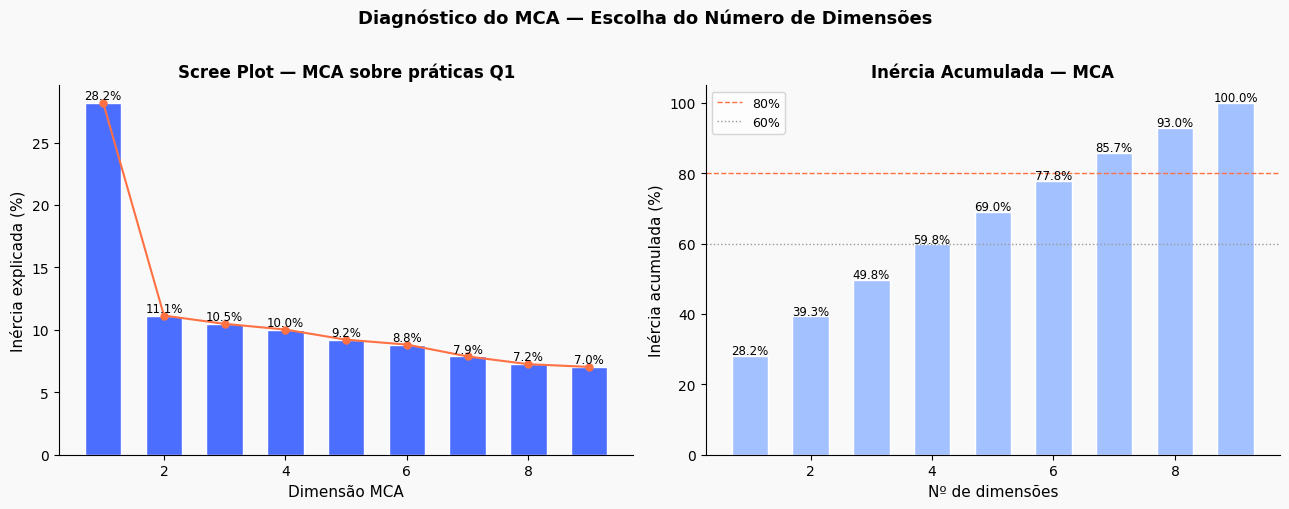


Regra de Kaiser (eigenvalue > média=0.1111): reter 2 dimensão(ões)
Inércia explicada com 2 dim.: 39.3%


In [70]:
# ── 3.8.3  Scree plot — quantas dimensões reter ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Inércia por dimensão
dims = range(1, len(eigenvalues) + 1)
axes[0].bar(dims, explained_pct.values, color=BLUE, edgecolor='white', width=0.6)
axes[0].plot(dims, explained_pct.values, 'o-', color=ORANGE, linewidth=1.5,
             markersize=5, label='Inércia (%)')
for i, val in enumerate(explained_pct.values):
    axes[0].text(i + 1, val + 0.3, f'{val:.1f}%', ha='center', fontsize=8.5)
axes[0].set_xlabel('Dimensão MCA', fontsize=11)
axes[0].set_ylabel('Inércia explicada (%)', fontsize=11)
axes[0].set_title('Scree Plot — MCA sobre práticas Q1', fontsize=12, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Inércia acumulada
axes[1].bar(dims, cumulative.values, color=LIGHT_BLUE, edgecolor='white', width=0.6)
axes[1].axhline(80, color=ORANGE, linestyle='--', linewidth=1, label='80%')
axes[1].axhline(60, color='#999', linestyle=':', linewidth=1, label='60%')
for i, val in enumerate(cumulative.values):
    axes[1].text(i + 1, val + 0.5, f'{val:.1f}%', ha='center', fontsize=8.5)
axes[1].set_xlabel('Nº de dimensões', fontsize=11)
axes[1].set_ylabel('Inércia acumulada (%)', fontsize=11)
axes[1].set_title('Inércia Acumulada — MCA', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.patch.set_facecolor(BG)
fig.suptitle('Diagnóstico do MCA — Escolha do Número de Dimensões',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Regra de retenção: eigenvalue > média (regra de Kaiser adaptada para MCA)
mean_eigenvalue = total_inertia / len(eigenvalues)
n_dims_kaiser   = (eigenvalues > mean_eigenvalue).sum()
print(f"\nRegra de Kaiser (eigenvalue > média={mean_eigenvalue:.4f}): reter {n_dims_kaiser} dimensão(ões)")
print(f"Inércia explicada com {n_dims_kaiser} dim.: {cumulative.iloc[n_dims_kaiser - 1]:.1f}%")
# Nota: usamos apenas a Dimensão 1 como mca_score.
# A Dim1 capta o eixo de "intensidade de adoção" — é a componente
# que mais distingue empresas com muitas vs. poucas práticas (28% inércia).
# As Dims 2+ capturam padrões de co-ocorrência entre práticas específicas
# (e.g., quais práticas tendem a ser adotadas juntas), o que é uma
# questão diferente da nossa variável dependente.


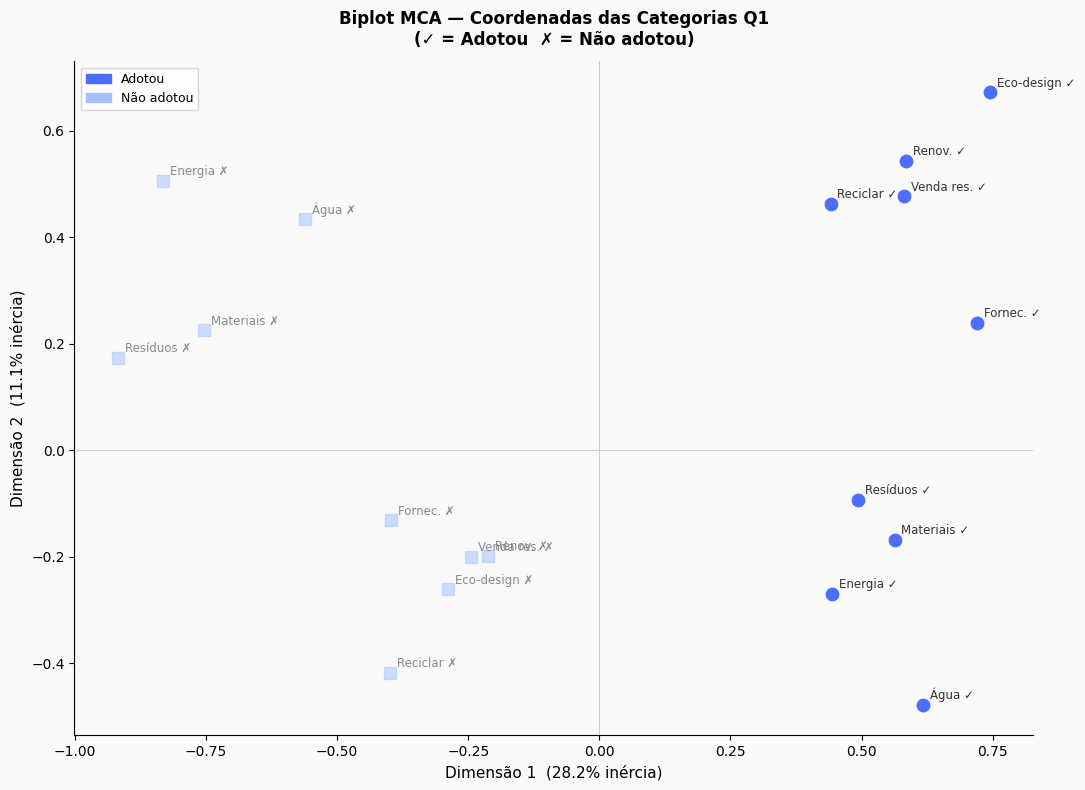

In [71]:
# ── 3.8.4  Biplot das categorias nas duas primeiras dimensões ─────────────────
#
# O biplot mostra onde cada categoria ("Adotou"/"Não adotou" de cada prática)
# se posiciona no espaço fatorial. Categorias próximas tendem a co-ocorrer
# nas mesmas empresas.

col_coords = mca.column_coordinates(df_q1_cat)

fig, ax = plt.subplots(figsize=(11, 8), facecolor=BG)

for idx, row in col_coords.iterrows():
    idx_str = str(idx)
    is_adotou = idx_str.endswith('__Adotou')
    cor    = BLUE       if is_adotou else LIGHT_BLUE
    alpha  = 1.0        if is_adotou else 0.5
    marker = 'o'        if is_adotou else 's'
    ax.scatter(row.iloc[0], row.iloc[1], color=cor, alpha=alpha,
               marker=marker, s=80, zorder=3)
    # label abreviado
    label_txt = idx_str.replace('__Adotou', ' ✓').replace('__Não adotou', ' ✗')
    short_map = {
        'Poupar água ✓': 'Água ✓', 'Poupar água ✗': 'Água ✗',
        'Poupar energia ✓': 'Energia ✓', 'Poupar energia ✗': 'Energia ✗',
        'Energia renovável ✓': 'Renov. ✓', 'Energia renovável ✗': 'Renov. ✗',
        'Poupar materiais ✓': 'Materiais ✓', 'Poupar materiais ✗': 'Materiais ✗',
        'Fornecedores mais verdes ✓': 'Fornec. ✓', 'Fornecedores mais verdes ✗': 'Fornec. ✗',
        'Minimizar resíduos ✓': 'Resíduos ✓', 'Minimizar resíduos ✗': 'Resíduos ✗',
        'Vender resíduos ✓': 'Venda res. ✓', 'Vender resíduos ✗': 'Venda res. ✗',
        'Reciclar internamente ✓': 'Reciclar ✓', 'Reciclar internamente ✗': 'Reciclar ✗',
        'Eco-design ✓': 'Eco-design ✓', 'Eco-design ✗': 'Eco-design ✗',
    }
    lbl = short_map.get(label_txt, label_txt)
    ax.annotate(lbl, (row.iloc[0], row.iloc[1]),
                textcoords='offset points', xytext=(5, 4), fontsize=8.5,
                color='#333' if is_adotou else '#888')

ax.axhline(0, color='#ccc', linewidth=0.7)
ax.axvline(0, color='#ccc', linewidth=0.7)
ax.set_xlabel(f'Dimensão 1  ({explained_pct.iloc[0]:.1f}% inércia)', fontsize=11)
ax.set_ylabel(f'Dimensão 2  ({explained_pct.iloc[1]:.1f}% inércia)', fontsize=11)
ax.set_title('Biplot MCA — Coordenadas das Categorias Q1\n(✓ = Adotou  ✗ = Não adotou)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(handles=[
    mpatches.Patch(color=BLUE,       label='Adotou'),
    mpatches.Patch(color=LIGHT_BLUE, label='Não adotou'),
], fontsize=9)
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [72]:
# ── 3.8.5  Coordenadas das empresas — extração do mca_score ──────────────────
#
# As coordenadas das empresas na Dimensão 1 são o nosso mca_score.
# A Dimensão 1 captura o eixo principal de variação nas práticas Q1:
#   → valores altos  = empresa com padrão de adoção mais incomum/intenso
#   → valores baixos = empresa com poucas ou nenhuma prática
#
# Nota sobre sinal: em MCA o sinal da dimensão é arbitrário.
# Verificamos a correlação com o intensity_index e invertemos se necessário
# para que mca_score e intensity_index apontem na mesma direção.

row_coords = mca.row_coordinates(df_q1_cat)

# Extrair dimensão 1
mca_dim1 = row_coords.iloc[:, 0].values

# Verificar correlação com intensity_index
corr_check = np.corrcoef(mca_dim1, df_model['intensity_index'].values)[0, 1]
print(f"\nCorrelação Dim1 MCA ↔ intensity_index: {corr_check:.4f}")

# Inverter sinal se correlação negativa (convenção: mais práticas = score maior)
if corr_check < 0:
    mca_dim1 = -mca_dim1
    corr_check = -corr_check
    print("→ Sinal invertido para alinhar com intensity_index (mais práticas = score maior)")
else:
    print("→ Sinal mantido")

df_model['mca_score'] = mca_dim1

print("\n=== mca_score — Estatísticas descritivas ===")
print(df_model['mca_score'].describe().round(4))


Correlação Dim1 MCA ↔ intensity_index: 0.9931
→ Sinal mantido

=== mca_score — Estatísticas descritivas ===
count    13559.0000
mean         0.0000
std          0.5308
min         -0.9640
25%         -0.4012
50%          0.0213
75%          0.4202
max          1.0862
Name: mca_score, dtype: float64


In [73]:
# ── 3.8.6  Pesos implícitos das práticas na Dimensão 1 ───────────────────────
#
# Os pesos implícitos indicam quanto cada prática contribui para o mca_score.
# Uma prática rara (baixa taxa de adoção) terá coordenadas mais afastadas
# da origem — ou seja, discrimina mais entre empresas.

from scipy.stats import spearmanr

# Coordenadas das categorias "Adotou" na Dimensão 1
col_coords_dim1 = col_coords.iloc[:, 0]
pesos_adotou = {}
for label in labels_q1:
    key = f'{label}__Adotou'  # prince usa __ como separador
    if key in col_coords_dim1.index:
        pesos_adotou[label] = abs(col_coords_dim1[key])

pesos_df = (pd.DataFrame.from_dict(pesos_adotou, orient='index', columns=['Peso (|coord Dim1|)'])
            .sort_values('Peso (|coord Dim1|)', ascending=False))

# Taxas de adoção (para contextualizar)
taxa_adocao = {
    label: (df_model[col + '_bin'].mean() * 100)
    for col, label in q1_map.items()
}
pesos_df['Taxa adoção (%)'] = pesos_df.index.map(taxa_adocao).round(1)
pesos_df = pesos_df.sort_values('Peso (|coord Dim1|)', ascending=False)

print("\n=== PESOS IMPLÍCITOS DAS PRÁTICAS NO mca_score ===")
print(pesos_df.round(4).to_string())

# Spearman r entre peso e taxa de adoção
rho, pval = spearmanr(pesos_df['Peso (|coord Dim1|)'], pesos_df['Taxa adoção (%)'])
print(f"\nSpearman r (peso ↔ taxa adoção): {rho:.3f}  p={pval:.4f}")
print("→ Correlação negativa esperada: práticas mais raras discriminam mais")
print("  e recebem coordenadas mais afastadas da origem (peso maior).")



=== PESOS IMPLÍCITOS DAS PRÁTICAS NO mca_score ===
                          Peso (|coord Dim1|)  Taxa adoção (%)
Eco-design                             0.7447             28.0
Fornecedores mais verdes               0.7194             35.6
Poupar água                            0.6177             47.6
Energia renovável                      0.5847             26.7
Vender resíduos                        0.5804             29.6
Poupar materiais                       0.5630             57.2
Minimizar resíduos                     0.4942             65.0
Poupar energia                         0.4439             65.2
Reciclar internamente                  0.4409             47.5

Spearman r (peso ↔ taxa adoção): -0.617  p=0.0769
→ Correlação negativa esperada: práticas mais raras discriminam mais
  e recebem coordenadas mais afastadas da origem (peso maior).


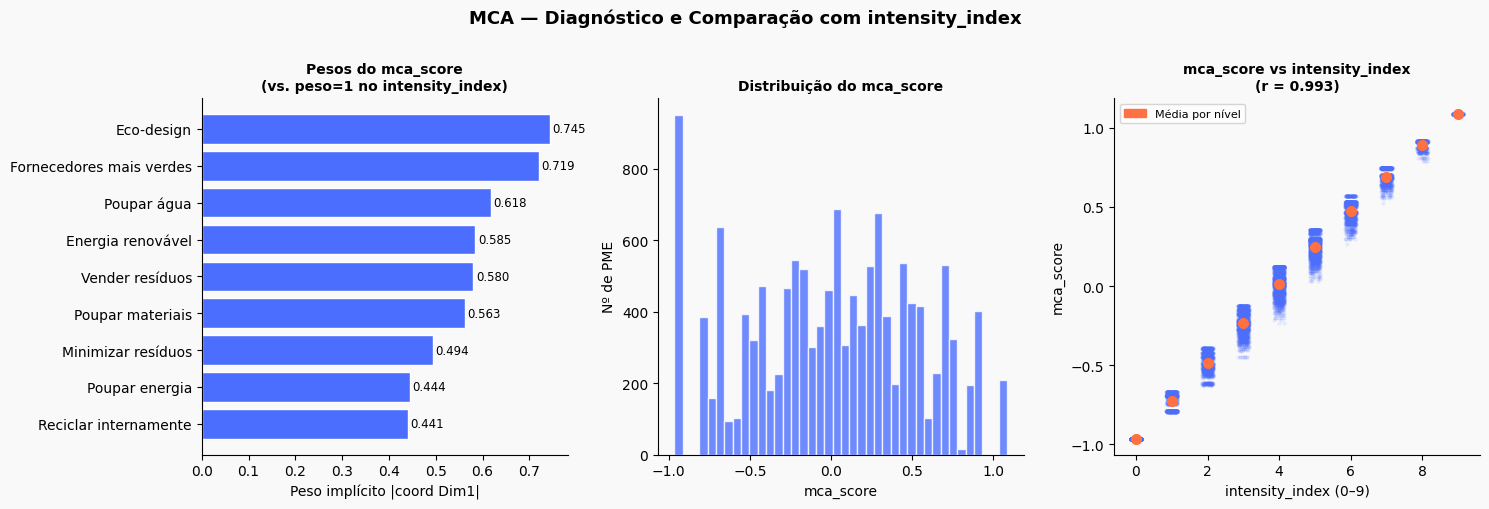


Correlação de Pearson  mca_score ↔ intensity_index: 0.9931
Correlação alta esperada — o mca_score é uma versão ponderada do mesmo conceito.
A diferença está nos pesos: práticas raras têm mais peso no mca_score.


In [74]:
# ── 3.8.7  Visualização — comparação intensity_index vs mca_score ────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)

# Pesos implícitos
sorted_pesos = pesos_df.sort_values('Peso (|coord Dim1|)')
bars = axes[0].barh(sorted_pesos.index, sorted_pesos['Peso (|coord Dim1|)'],
                    color=BLUE, edgecolor='white')
for bar, val in zip(bars, sorted_pesos['Peso (|coord Dim1|)']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=8.5)
axes[0].set_xlabel('Peso implícito |coord Dim1|', fontsize=10)
axes[0].set_title('Pesos do mca_score\n(vs. peso=1 no intensity_index)',
                  fontsize=10, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Distribuição do mca_score
axes[1].hist(df_model['mca_score'], bins=40, color=BLUE, edgecolor='white', alpha=0.8)
axes[1].set_xlabel('mca_score', fontsize=10)
axes[1].set_ylabel('Nº de PME', fontsize=10)
axes[1].set_title('Distribuição do mca_score', fontsize=10, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Scatter: mca_score vs intensity_index
jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(df_model))
axes[2].scatter(df_model['intensity_index'] + jitter,
                df_model['mca_score'],
                alpha=0.07, s=5, color=BLUE)
# Médias por nível do índice
for idx_val in range(10):
    mask = df_model['intensity_index'] == idx_val
    if mask.sum() > 10:
        axes[2].plot(idx_val, df_model.loc[mask, 'mca_score'].mean(),
                     'o', color=ORANGE, markersize=7, zorder=4)
axes[2].set_xlabel('intensity_index (0–9)', fontsize=10)
axes[2].set_ylabel('mca_score', fontsize=10)
axes[2].set_title(f'mca_score vs intensity_index\n(r = {corr_check:.3f})',
                  fontsize=10, fontweight='bold')
axes[2].set_facecolor(BG)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].legend(handles=[
    mpatches.Patch(color=ORANGE, label='Média por nível'),
], fontsize=8, loc='upper left')

fig.patch.set_facecolor(BG)
fig.suptitle('MCA — Diagnóstico e Comparação com intensity_index',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nCorrelação de Pearson  mca_score ↔ intensity_index: {corr_check:.4f}")
print("Correlação alta esperada — o mca_score é uma versão ponderada do mesmo conceito.")
print("A diferença está nos pesos: práticas raras têm mais peso no mca_score.")

In [75]:
# ── 3.8.8  Adição ao df_model e verificação final ────────────────────────────

print("\n=== df_model — novas variáveis ===")
print(f"  intensity_index  → VD original  (soma simples, 0–9)")
print(f"  mca_score        → VD alternativa (score contínuo ponderado por raridade)")
print(f"\nmca_score — NAs: {df_model['mca_score'].isnull().sum()} → deve ser 0")
print(f"Dimensão df_model após MCA: {df_model.shape}")

# Comparação descritiva por setor e dimensão
print("\n=== mca_score médio por setor ===")
mca_by_sector = (df_model.groupby('nace_b')['mca_score']
    .agg(['mean', 'std', 'count']).round(4)
    .sort_values('mean', ascending=False))
mca_by_sector.index = mca_by_sector.index.map(sector_map)
print(mca_by_sector)

print("\n=== mca_score médio por dimensão ===")
mca_by_size = (df_model[df_model['scr10'].isin(size_order)]
    .groupby('scr10')['mca_score']
    .agg(['mean', 'std', 'count'])
    .reindex(size_order).round(4))
mca_by_size.index = mca_by_size.index.map(size_map)
print(mca_by_size)


=== df_model — novas variáveis ===
  intensity_index  → VD original  (soma simples, 0–9)
  mca_score        → VD alternativa (score contínuo ponderado por raridade)

mca_score — NAs: 0 → deve ser 0
Dimensão df_model após MCA: (13559, 76)

=== mca_score médio por setor ===
                       mean     std  count
nace_b                                    
Manufatura (C)       0.1028  0.5217   2736
Retalho (G)         -0.0004  0.5289   4016
Indústria (B/D/E/F) -0.0021  0.5270   2671
Serviços (H–M)      -0.0663  0.5306   4136

=== mca_score médio por dimensão ===
                   mean     std  count
scr10                                 
Micro (1–9)     -0.0725  0.5309   5941
Pequena (10–49)  0.0232  0.5278   4992
Média (50–249)   0.1200  0.5106   2626


In [76]:
# ── 3.8.9  Estandardização do mca_score ──────────────────────────────────────
# Para consistência com os restantes preditores contínuos,
# criamos também uma versão estandardizada do mca_score.

df_model['mca_score_z'] = (
    (df_model['mca_score'] - df_model['mca_score'].mean())
    / df_model['mca_score'].std()
)

print("=== mca_score_z — verificação ===")
print(f"  Média:  {df_model['mca_score_z'].mean():.6f}  (≈0)")
print(f"  Desvio: {df_model['mca_score_z'].std():.6f}  (≈1)")
print(f"\ndf_model final: {df_model.shape[0]:,} linhas × {df_model.shape[1]} colunas")

=== mca_score_z — verificação ===
  Média:  0.000000  (≈0)
  Desvio: 1.000000  (≈1)

df_model final: 13,559 linhas × 77 colunas


# 4. Modelação



## 4.1 Regressões Logísticas Individuais — Complemento Descritivo ao MCA



> Para complementar a ponderação por raridade do MCA (Secção 3.8), ajustamos uma regressão logística separada para cada prática Q1 como variável dependente, usando apenas preditores estruturais (sem barreiras Q7). O pseudo-R² de McFadden indica quanta variância na adoção de cada prática é explicada pelas características observáveis da empresa. Práticas com R² baixo refletem decisões idiossincráticas; práticas com R² alto são mais previsíveis a partir do perfil estrutural.

In [77]:
# ── 4.1.1  Regressões logísticas individuais (9 práticas Q1) ──────────────────
import statsmodels.api as sm

# Preditores estruturais — sem Q7 (outcomes), sem hired_bin (redundante c/ fin_difficulty)
struct_predictors = (
    ['d_industry', 'd_retail', 'd_services']
    + ['d_small', 'd_medium']
    + ['d_age_2001_10', 'd_age_2011_15', 'd_age_post2015', 'd_age_dkna']
    + ['d_emp_increased', 'd_emp_decreased', 'd_emp_dkna']
    + ['d_q3_dec_lot', 'd_q3_dec_lit', 'd_q3_inc_lit', 'd_q3_inc_lot', 'd_q3_dkna']
    + ['d_q4_lt1', 'd_q4_1_5', 'd_q4_6_10', 'd_q4_11_30', 'd_q4_gt30', 'd_q4_dkna']
    + ['turnover_size', 'turnover_unknown']
    + ['fin_difficulty']
)

q1_bins = [f'{col}_bin' for col in q1_map.keys()]
X = sm.add_constant(df_model[struct_predictors])

results_logit = {}
summary_rows = []

for col, (q1_key, label) in zip(q1_bins, q1_map.items()):
    y = df_model[col]
    model = sm.Logit(y, X)
    fit = model.fit(disp=0)
    results_logit[q1_key] = fit
    summary_rows.append({
        'Prática': label,
        'q1_var': q1_key,
        'N': int(fit.nobs),
        'Taxa adoção (%)': round(y.mean() * 100, 1),
        'Pseudo-R² (McFadden)': fit.prsquared,
        'Log-Lik': fit.llf,
        'AIC': fit.aic,
    })

df_logit_summary = pd.DataFrame(summary_rows)
df_logit_summary = df_logit_summary.sort_values('Pseudo-R² (McFadden)', ascending=False)

print("=== REGRESSÕES LOGÍSTICAS INDIVIDUAIS — RESUMO ===\n")
print(f"Preditores estruturais: {len(struct_predictors)} variáveis")
print(f"Observações: {int(df_logit_summary['N'].iloc[0]):,}\n")
print(df_logit_summary[['Prática', 'Taxa adoção (%)', 'Pseudo-R² (McFadden)', 'AIC']]
      .round(4).to_string(index=False))

print("\n→ Pseudo-R² de McFadden mais alto = prática mais previsível pelo perfil estrutural.")
print("  Pseudo-R² mais baixo = adoção depende mais de decisões idiossincráticas da empresa.")

=== REGRESSÕES LOGÍSTICAS INDIVIDUAIS — RESUMO ===

Preditores estruturais: 26 variáveis
Observações: 13,559

                 Prática  Taxa adoção (%)  Pseudo-R² (McFadden)        AIC
         Vender resíduos             29.6                0.0892 15051.4478
          Poupar energia             65.2                0.0759 16244.0159
      Minimizar resíduos             65.0                0.0693 16394.3820
       Energia renovável             26.7                0.0685 14705.5418
        Poupar materiais             57.2                0.0561 17529.3878
Fornecedores mais verdes             35.6                0.0485 16847.4320
              Eco-design             28.0                0.0458 15386.1980
             Poupar água             47.6                0.0430 18011.3448
   Reciclar internamente             47.5                0.0355 18150.6684

→ Pseudo-R² de McFadden mais alto = prática mais previsível pelo perfil estrutural.
  Pseudo-R² mais baixo = adoção depende mais de decisõe

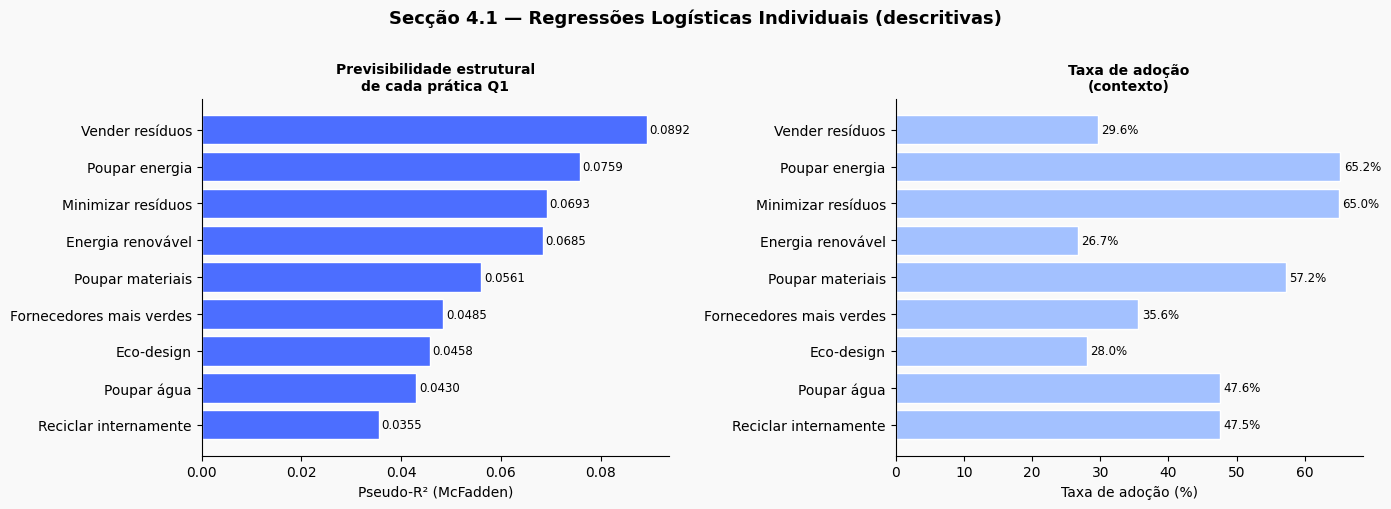

In [78]:
# ── 4.1.2  Visualização — pseudo-R² por prática ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

sorted_df = df_logit_summary.sort_values('Pseudo-R² (McFadden)')

# Painel 1: Pseudo-R²
bars = axes[0].barh(sorted_df['Prática'], sorted_df['Pseudo-R² (McFadden)'],
                    color=BLUE, edgecolor='white')
for bar, val in zip(bars, sorted_df['Pseudo-R² (McFadden)']):
    axes[0].text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=8.5)
axes[0].set_xlabel('Pseudo-R² (McFadden)', fontsize=10)
axes[0].set_title('Previsibilidade estrutural\nde cada prática Q1',
                  fontsize=10, fontweight='bold')
axes[0].set_facecolor(BG)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Painel 2: Taxa de adoção (contexto)
bars2 = axes[1].barh(sorted_df['Prática'], sorted_df['Taxa adoção (%)'],
                     color=LIGHT_BLUE, edgecolor='white')
for bar, val in zip(bars2, sorted_df['Taxa adoção (%)']):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=8.5)
axes[1].set_xlabel('Taxa de adoção (%)', fontsize=10)
axes[1].set_title('Taxa de adoção\n(contexto)', fontsize=10, fontweight='bold')
axes[1].set_facecolor(BG)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Secção 4.1 — Regressões Logísticas Individuais (descritivas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

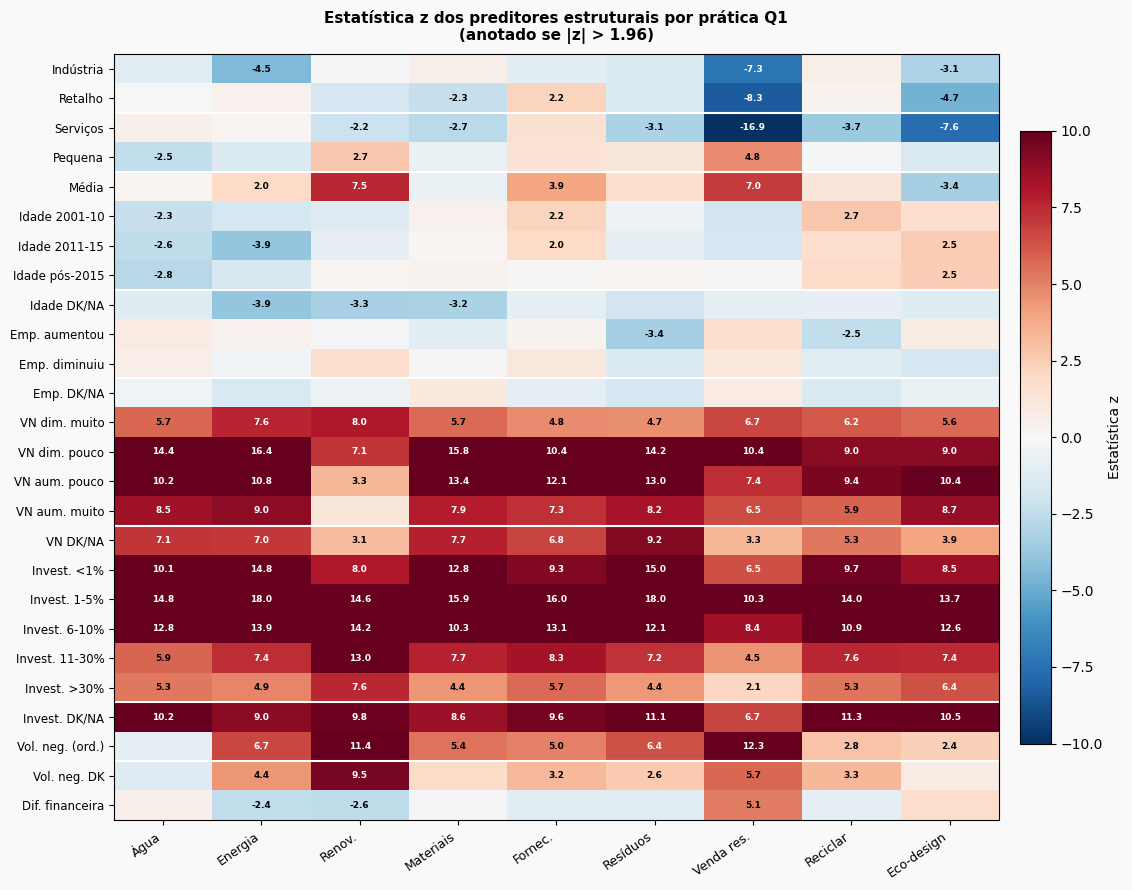

In [79]:
# ── 4.1.3  Heatmap de coeficientes — preditores × práticas ───────────────────
#
# Valores z (coef / erro padrão): indicam direção e significância.
# |z| > 1.96 ≈ significativo a 5%.

predictor_labels = {
    'd_industry': 'Indústria', 'd_retail': 'Retalho', 'd_services': 'Serviços',
    'd_small': 'Pequena', 'd_medium': 'Média',
    'd_age_2001_10': 'Idade 2001-10', 'd_age_2011_15': 'Idade 2011-15',
    'd_age_post2015': 'Idade pós-2015', 'd_age_dkna': 'Idade DK/NA',
    'd_emp_increased': 'Emp. aumentou', 'd_emp_decreased': 'Emp. diminuiu',
    'd_emp_dkna': 'Emp. DK/NA',
    'd_q3_dec_lot': 'VN dim. muito', 'd_q3_dec_lit': 'VN dim. pouco',
    'd_q3_inc_lit': 'VN aum. pouco', 'd_q3_inc_lot': 'VN aum. muito',
    'd_q3_dkna': 'VN DK/NA',
    'd_q4_lt1': 'Invest. <1%', 'd_q4_1_5': 'Invest. 1-5%',
    'd_q4_6_10': 'Invest. 6-10%', 'd_q4_11_30': 'Invest. 11-30%',
    'd_q4_gt30': 'Invest. >30%', 'd_q4_dkna': 'Invest. DK/NA',
    'turnover_size': 'Vol. neg. (ord.)', 'turnover_unknown': 'Vol. neg. DK',
    'fin_difficulty': 'Dif. financeira',
}

# Construir matriz de z-values (sem const)
z_matrix = pd.DataFrame()
for q1_key, fit in results_logit.items():
    z_vals = fit.tvalues[1:]  # excluir constante
    z_matrix[q1_map[q1_key]] = z_vals.values

z_matrix.index = [predictor_labels.get(p, p) for p in struct_predictors]

# Abreviar nomes longos das práticas para caber no eixo x
short_practice = {
    'Poupar água': 'Água', 'Poupar energia': 'Energia',
    'Energia renovável': 'Renov.', 'Poupar materiais': 'Materiais',
    'Fornecedores mais verdes': 'Fornec.', 'Minimizar resíduos': 'Resíduos',
    'Vender resíduos': 'Venda res.', 'Reciclar internamente': 'Reciclar',
    'Eco-design': 'Eco-design',
}
z_display = z_matrix.rename(columns=short_practice)

fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
vmax = 10
im = ax.imshow(z_display.values, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(z_display.columns)))
ax.set_xticklabels(z_display.columns, fontsize=9, rotation=35, ha='right')
ax.set_yticks(range(len(z_display.index)))
ax.set_yticklabels(z_display.index, fontsize=8.5)

# Anotar células com |z| > 1.96 (significativo a 5%)
for i in range(z_display.shape[0]):
    for j in range(z_display.shape[1]):
        val = z_display.iloc[i, j]
        if abs(val) > 1.96:
            color = 'white' if abs(val) > 6 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=6.5, fontweight='bold', color=color)

# Linhas horizontais entre grupos de preditores
group_ends = [2, 4, 8, 11, 16, 22, 24]  # after sector, size, age, emp, Q3, Q4, rest
for ge in group_ends:
    ax.axhline(ge - 0.5, color='white', linewidth=1.5)

ax.set_title('Estatística z dos preditores estruturais por prática Q1\n(anotado se |z| > 1.96)',
             fontsize=11, fontweight='bold', pad=10)
cbar = plt.colorbar(im, ax=ax, label='Estatística z', shrink=0.8, pad=0.02)
ax.set_facecolor(BG)
fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.show()

In [80]:
# ── 4.1.4  Comparação com pesos MCA e síntese ────────────────────────────────

comparison = df_logit_summary[['Prática', 'q1_var', 'Taxa adoção (%)', 'Pseudo-R² (McFadden)']].copy()
comparison['Peso MCA'] = comparison['Prática'].map(
    pesos_df['Peso (|coord Dim1|)'].to_dict()
)
comparison = comparison.sort_values('Pseudo-R² (McFadden)', ascending=False)

print("=== COMPARAÇÃO: PSEUDO-R² vs PESOS MCA vs TAXA DE ADOÇÃO ===\n")
print(comparison[['Prática', 'Taxa adoção (%)', 'Pseudo-R² (McFadden)', 'Peso MCA']]
      .round(4).to_string(index=False))

# Spearman
rho1, p1 = spearmanr(comparison['Pseudo-R² (McFadden)'], comparison['Taxa adoção (%)'])
rho2, p2 = spearmanr(comparison['Pseudo-R² (McFadden)'], comparison['Peso MCA'])
rho3, p3 = spearmanr(comparison['Taxa adoção (%)'], comparison['Peso MCA'])

print(f"\nSpearman r (pseudo-R² ↔ taxa adoção):  {rho1:.3f}  p={p1:.4f}")
print(f"Spearman r (pseudo-R² ↔ peso MCA):     {rho2:.3f}  p={p2:.4f}")
print(f"Spearman r (taxa adoção ↔ peso MCA):   {rho3:.3f}  p={p3:.4f}")

print("\n→ Interpretação:")
print("  O pseudo-R² mede a previsibilidade estrutural de cada prática.")
print("  O peso MCA mede a capacidade discriminante (raridade × correlação).")
print("  Se ambos apontam na mesma direção, reforça-se a evidência de que")
print("  práticas raras e idiossincráticas são as mais informativas.")

=== COMPARAÇÃO: PSEUDO-R² vs PESOS MCA vs TAXA DE ADOÇÃO ===

                 Prática  Taxa adoção (%)  Pseudo-R² (McFadden)  Peso MCA
         Vender resíduos             29.6                0.0892    0.5804
          Poupar energia             65.2                0.0759    0.4439
      Minimizar resíduos             65.0                0.0693    0.4942
       Energia renovável             26.7                0.0685    0.5847
        Poupar materiais             57.2                0.0561    0.5630
Fornecedores mais verdes             35.6                0.0485    0.7194
              Eco-design             28.0                0.0458    0.7447
             Poupar água             47.6                0.0430    0.6177
   Reciclar internamente             47.5                0.0355    0.4409

Spearman r (pseudo-R² ↔ taxa adoção):  0.167  p=0.6682
Spearman r (pseudo-R² ↔ peso MCA):     -0.217  p=0.5755
Spearman r (taxa adoção ↔ peso MCA):   -0.617  p=0.0769

→ Interpretação:
  O pseudo-R